---
# <b>QSR Location Health Index Analysis - US Market</b>

<h2 style="color:#1F4E79;"><u>Project Overview</u></h2>

The quick service restaurant market (QSR) in the US was worth USD 343.09 billion in 2026, projected to grow to USD 599.87 billion by 2032, making the North American region the largest QSR market at 37.03% market share in 2025. (Fortune Business Insights, 2026). 

However, QSRs in the US are facing a number of challenges:

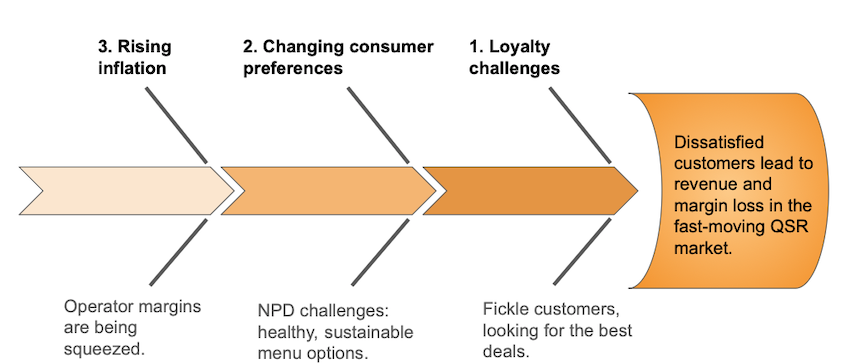



To protect revenue and margins, VP Analytics needs to create a **Location Digital Health Index** to proactively identify restaurants at risk of high levels of customer dissatisfaction, enabling swift, targeted operational interventions. 

### Analysis objectives: 
- **Objective 1:** Highlighting the underperforming outlets by average star rating and recency-weighted average rating to determine which outlets are the most at risk, to inform interventions.
- **Objective 2:** Identifying the most frequently mentioned issue, using NLP, to drive operational improvements. 
- **Objective 3:** Benchmarking to average regional performance to evaluate competitive landscape and inform localised service strategies.

---

<h2 style="color:#1F4E79;"><u> Framework</u></h2>

We will develop a  **QSR Location Digital Health Index** using Yelp business reviews, combined with QSR location data stored in Snowflake.

The Python Notebook follows a full analytical workflow, including:
- exploratory data analysis (EDA)
- feature engineering
- skewness reduction using log transformations
- feature standardisation using MinMax scaling
- recency-weighted scoring
- weighted Health Index construction
- business segmentation into weighted health tiers (i.e. Top 10% health score)

The final objective is to segment QSR businesses into interpretable performance tiers:
- High Risk 
- Medium Risk
- Low Risk

This framework provides a scalable and explainable approach to evaluating restaurant outlet performance, supporting location-level benchmarking and operational decision-making.


---

<h2 style="color:#1F4E79;"><u> Technical Architecture</u></h2>

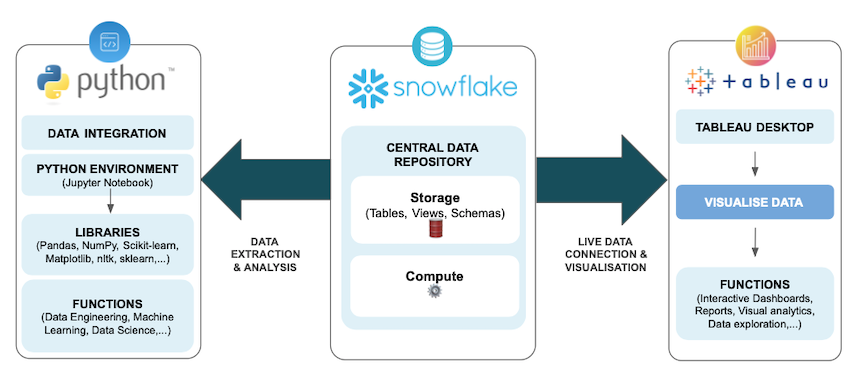

---

<h2 style="color:#1F4E79;"><u> Technical Pipeline</u></h2>

The technical pipeline flows in a logical order:
1. Clean business reviews data from Yelp and upload into Snowflake.
2. Conduct feature engineering in Python for scorecard scoring.
3. Upload the feature engineering data into Snowflake.
4. Create in Python a weighted health index scoring [0-100].
5. Upload the weighted health scoring into Snowflake for a complete scorecard view.
6. Connect Snowflake with Tableau for final scorecard build. 

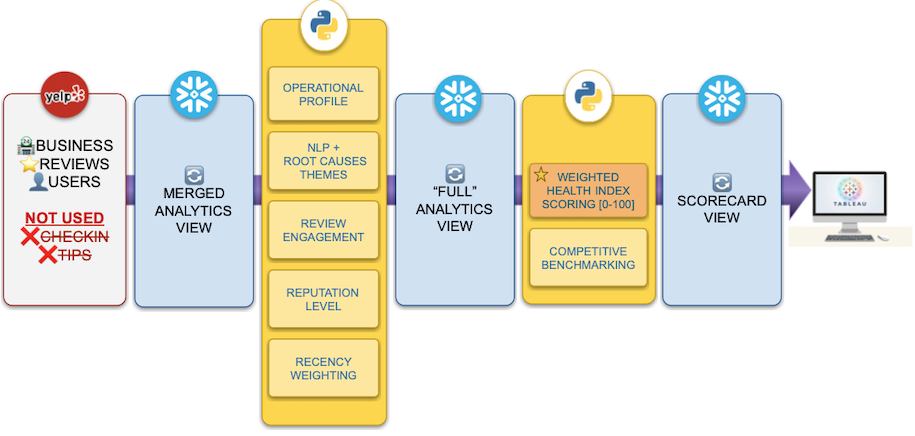

---

<h2 style="color:#1F4E79;"><u> Repeatable Analytics Product</u></h2>

- The final Location Health Index needs to be packaged as a **repeatable product for QSRs**. 
- Feature engineering will adopt **user-defined functions** to ensure scale and repeatability for data sets outside of Yelp (i.e. Google reviews).
- **The timeframe** selected for this analysis is January 2018 to January 2022, partly to accommodate for comparisons pre- and post COVID-19 (see image below). However, the dates are merely used as placeholders for the prototype build. To help QSRs managers in today's climate, recent and current data need to be fed into the final Index model.

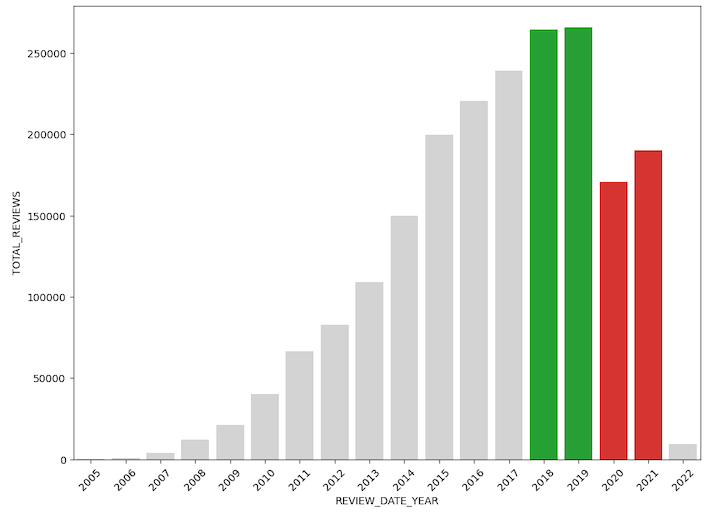

---

#

# Required Libraries

In [1]:
!pip install snowflake-connector-python pandas numpy matplotlib seaborn statsmodels scikit-learn scipy nltk vaderSentiment sentence-transformers

In [2]:
import snowflake.connector      

import pandas as pd
import numpy as np
import math
import re
import string

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

import statsmodels.api as sm 
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn import linear_model
import sklearn

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import MinMaxScaler

from scipy.spatial import KDTree

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
from sentence_transformers import SentenceTransformer, util

from pprint import pprint

from snowflake.connector.pandas_tools import write_pandas

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries loaded successfully")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Soso\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Libraries loaded successfully


<h1> Connecting Snowflake</h1>

<div style="
    background-color:#E8F4FD;
    border-left:6px solid #1F4E79;
    padding:10px;
    border-radius:5px;
">

<div style="color:#1F4E79;">
<b>ℹ️ Snowflake Connection Requirement</b><br><br>
</div>

This notebook requires a valid Snowflake connection to execute queries.<br>
Please ensure you provide your <b>username</b> and <b>password</b> in the connection cell below.

</div>

In [3]:
conn = snowflake.connector.connect(
    user="",
    password="",
    account='SFEDU02-BKB92930',
    warehouse='WH_TEAM_15_XS',
    database='LSE_YELP_TEAMS_DB',
    schema='TEAM_15',
    role='ROLE_LSE_TEAM_15',
)


---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    margin:0;
    letter-spacing:1px;
">
1. Exploratory Data Analysis (EDA)
</h1>

</div>

---

<h4 style="color:#475569;"> <i>1.1 Load Analytical Dataset from Snowflake</i></h4>

The analysis uses the cleaned `STG_QSR_ANALYTICS` Snowflake analytical view created as part of the QSR data engineering workflow.
<br><br>
This view integrates business, review and user-level signals into a centralised analytical dataset suitable for exploratory analysis, operational feature engineering and regression modelling.
<br><br>
Using the Snowflake analytical view ensures consistency, scalability and reproducibility throughout the analytical workflow.

In [4]:
# =========================================
# Load dataset from Snowflake
# =========================================

# Connect to Snowflake, create dataframe with SQL queries, 
analytics = pd.read_sql("SELECT * FROM LSE_YELP_TEAMS_DB.TEAM_15.STG_QSR_ANALYTICS", conn)

print("Dataset loaded successfully.")

Dataset loaded successfully.


<h4 style="color:#475569;"> <i>1.2 Dataset analysis</i></h4>

The following section explores the structure, completeness and distribution of the analytical dataset before regression modelling.

Performing exploratory analysis helps validate data quality, identify missing values and understand the overall behaviour of key location health variables prior to statistical modelling.

In [5]:
# =========================================
# Dataset overview
# =========================================
analytics.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_ADDRESS,BUSINESS_STATE,BUSINESS_STATE_FULL_NAME,BUSINESS_POSTAL_CODE,BUSINESS_LATITUDE,BUSINESS_LONGITUDE,BUSINESS_REGION,...,USER_COMPLIMENT_MORE,USER_COMPLIMENT_PROFILE,USER_COMPLIMENT_CUTE,USER_COMPLIMENT_LIST,USER_COMPLIMENT_NOTE,USER_COMPLIMENT_PLAIN,USER_COMPLIMENT_COOL,USER_COMPLIMENT_FUNNY,USER_COMPLIMENT_WRITER,USER_COMPLIMENT_PHOTOS
0,G5kWtADcIMy5CgrjUerfnA,Chariot Pizza,Tucson,"1835 S Alvernon Way, Ste 207",AZ,Arizona,85711,32.200754,-110.908891,West,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,zupI44qitH6T8Bo9OjA6Yw,Bagelicious And More,Wesley Chapel,30032 Sr 54 E,FL,Florida,33544,28.239970,-82.318874,South,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,NgUst1ex3M2ibDzSb6Xkaw,Emmy Squared - Queen Village,Philadelphia,632 S 5th St,PA,Pennsylvania,19147,39.941042,-75.151123,Northeast,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5yeL75bFLZlGB6dUfwCIQw,Cotoletta Fitler Square,Philadelphia,2227 Pine St,PA,Pennsylvania,19103,39.947474,-75.179185,Northeast,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,zu1V7XhERCFA23srN_ro7g,Panera Bread,Wayne,267 E Swedesford Rd,PA,Pennsylvania,19087,40.074251,-75.430794,Northeast,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print("Rows:", analytics.shape[0])
print("Columns:", analytics.shape[1],"\n")
analytics.info()

Rows: 696315
Columns: 54 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696315 entries, 0 to 696314
Data columns (total 54 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   BUSINESS_ID                       696315 non-null  object 
 1   BUSINESS_NAME                     696315 non-null  object 
 2   BUSINESS_CITY                     696315 non-null  object 
 3   BUSINESS_ADDRESS                  693865 non-null  object 
 4   BUSINESS_STATE                    696315 non-null  object 
 5   BUSINESS_STATE_FULL_NAME          696315 non-null  object 
 6   BUSINESS_POSTAL_CODE              696315 non-null  object 
 7   BUSINESS_LATITUDE                 696315 non-null  float64
 8   BUSINESS_LONGITUDE                696315 non-null  float64
 9   BUSINESS_REGION                   696315 non-null  object 
 10  BUSINESS_COUNTRY                  696315 non-null  object 
 11  BUSINESS_RATING          

In [7]:
# =========================================
# Unique value per column
# =========================================
print("Unique Values (per column):")
print(analytics.nunique().sort_values(ascending=False))

Unique Values (per column):
REVIEW_ID                           696315
REVIEW_TEXT                         694965
USER_ID                             369878
USER_NAME                            39419
BUSINESS_ID                          18000
BUSINESS_LATITUDE                    17670
BUSINESS_LONGITUDE                   17569
BUSINESS_ADDRESS                     17121
BUSINESS_ATTRIBUTES                  17007
BUSINESS_NAME                         9835
BUSINESS_CATEGORIES                   9518
BUSINESS_HOURS                        7545
USER_YELPING_SINCE_DATE               5774
USER_VOTE_USEFUL                      3377
USER_VOTE_COOL                        2766
USER_VOTE_FUNNY                       2162
USER_NB_FRIENDS                       1820
USER_REVIEW_COUNT                     1610
REVIEW_DATE                           1480
USER_COMPLIMENT_PLAIN                  928
USER_COMPLIMENT_COOL                   891
USER_COMPLIMENT_FUNNY                  891
BUSINESS_POSTAL_CODE      

In [8]:
# =========================================
# Missing value analysis
# =========================================

missing_values = (
    analytics.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values.head(30)

BUSINESS_HOURS              20732
BUSINESS_ATTRIBUTES          2460
BUSINESS_ADDRESS             2450
USER_COMPLIMENT_PHOTOS          4
USER_NAME                       4
USER_REVIEW_COUNT               4
USER_YELPING_SINCE_DATE         4
USER_YELPING_SINCE_MONTH        4
USER_YELPING_SINCE_YEAR         4
USER_YELPING_NB_YEARS           4
USER_VOTE_USEFUL                4
USER_VOTE_FUNNY                 4
USER_VOTE_COOL                  4
USER_FOLLOWERS                  4
USER_NB_FRIENDS                 4
AVG_USER_REVIEW_STARS           4
USER_COMPLIMENT_HOT             4
USER_COMPLIMENT_MORE            4
USER_COMPLIMENT_PROFILE         4
USER_COMPLIMENT_CUTE            4
USER_COMPLIMENT_LIST            4
USER_COMPLIMENT_NOTE            4
USER_COMPLIMENT_PLAIN           4
USER_COMPLIMENT_COOL            4
USER_COMPLIMENT_FUNNY           4
USER_COMPLIMENT_WRITER          4
USER_ID                         4
REVIEW_TEXT                     0
BUSINESS_ID                     0
BUSINESS_REVIE

<h3 style="color:#475569;"> <i>1.3 Missing Values Interpretation</i></h3>

The missing-value analysis shows that `business_hours`, `business_attributes` and `business_address` contain some missing records, which is expected due to incomplete business metadata across Yelp locations.

Most analytical variables contain only 4 missing rows, which is negligible relative to the overall dataset size of approximately 704k rows.

Given the low proportion of missingness across the key analytical variables, the dataset is considered sufficiently complete for regression modelling without requiring major imputation or data reconstruction procedures.



In [9]:
# Are there any duplicates?
print(analytics[analytics.duplicated()])

Empty DataFrame
Columns: [BUSINESS_ID, BUSINESS_NAME, BUSINESS_CITY, BUSINESS_ADDRESS, BUSINESS_STATE, BUSINESS_STATE_FULL_NAME, BUSINESS_POSTAL_CODE, BUSINESS_LATITUDE, BUSINESS_LONGITUDE, BUSINESS_REGION, BUSINESS_COUNTRY, BUSINESS_RATING, IS_OPEN_BUSINESS, BUSINESS_CATEGORIES, BUSINESS_CATEGORY_CLASSIFICATION, BUSINESS_ATTRIBUTES, BUSINESS_HOURS, IS_QSR_BUSINESS, BUSINESS_TYPE, BUSINESS_SCALE_TYPE, REVIEW_ID, REVIEW_STARS, REVIEW_VOTE_USEFUL, REVIEW_VOTE_FUNNY, REVIEW_VOTE_COOL, REVIEW_DATE, REVIEW_DATE_MONTH, REVIEW_DATE_YEAR, BUSINESS_REVIEW_COUNT, REVIEW_TEXT, USER_ID, USER_NAME, USER_REVIEW_COUNT, USER_YELPING_SINCE_DATE, USER_YELPING_SINCE_MONTH, USER_YELPING_SINCE_YEAR, USER_YELPING_NB_YEARS, USER_VOTE_USEFUL, USER_VOTE_FUNNY, USER_VOTE_COOL, USER_FOLLOWERS, USER_NB_FRIENDS, AVG_USER_REVIEW_STARS, USER_COMPLIMENT_HOT, USER_COMPLIMENT_MORE, USER_COMPLIMENT_PROFILE, USER_COMPLIMENT_CUTE, USER_COMPLIMENT_LIST, USER_COMPLIMENT_NOTE, USER_COMPLIMENT_PLAIN, USER_COMPLIMENT_COOL, USE

<h3 style="color:#475569;"> <i>1.4 Duplicate Values Interpretation</i></h3>

We have missing values, but no duplicate rows. 

<h3 style="color:#475569;"> <i>1.5 Dates exploration</i></h3>

In [10]:
# Change the review date to datetime.
analytics['REVIEW_DATE'] = pd.to_datetime(analytics['REVIEW_DATE'], format='%Y-%m-%d')

# View the DateFrame.
print(analytics['REVIEW_DATE'][:5]) 

0   2018-01-12
1   2019-04-14
2   2019-10-21
3   2019-11-11
4   2019-10-25
Name: REVIEW_DATE, dtype: datetime64[ns]


In [11]:
# Change the data type of the appointment month to string to allow for easier plotting.
analytics['REVIEW_DATE_MONTH'] = analytics['REVIEW_DATE_MONTH'].astype("string")

# View output.
print(analytics['REVIEW_DATE_MONTH'].dtype)

string


In [12]:
# Determine the date range.
print(f"Start date for the data set: {analytics['REVIEW_DATE'].min()}")
print(f"End date for the data set: {analytics['REVIEW_DATE'].max()}")

Start date for the data set: 2018-01-01 00:00:00
End date for the data set: 2022-01-19 00:00:00


<h3 style="color:#475569;"> <i>1.6 Scope exploration</i></h3>

In [13]:
# View the number of US states.
# Rank by business volume.
analytics.groupby('BUSINESS_STATE_FULL_NAME')['BUSINESS_NAME'].nunique().sort_values(ascending=False)

BUSINESS_STATE_FULL_NAME
Pennsylvania    2872
Florida         1780
New Jersey       949
Tennessee        912
Indiana          795
Missouri         751
Louisiana        695
Arizona          573
Nevada           409
Idaho            324
California       284
Delaware         262
Illinois         234
Name: BUSINESS_NAME, dtype: int64

In [14]:
# View the number of US states.
# Rank by review volume.
analytics.groupby('BUSINESS_STATE_FULL_NAME')['REVIEW_TEXT'].nunique().sort_values(ascending=False)

BUSINESS_STATE_FULL_NAME
Pennsylvania    139608
Florida         135609
Tennessee        61135
Louisiana        57587
Indiana          57372
Missouri         52049
Arizona          48854
Nevada           43708
California       31524
New Jersey       30891
Idaho            22205
Delaware          7489
Illinois          6935
Name: REVIEW_TEXT, dtype: int64

<h3 style="color:#475569;"> <i> 1.7 Interpretation</i></h3>    

- Pennsylvania and Florida have the largest number of businesses, translated into the largest number of reviews.
- New Jersey have the third largest number of businesses, but only ranked 10th in terms of the number of reviews. This could be due to low engagement in the state, alternatively a preference for Google reviews. 

In [15]:
# Determine the descriptive statistics of the data set.
analytics.describe()

,BUSINESS_LATITUDE,BUSINESS_LONGITUDE,BUSINESS_RATING,REVIEW_STARS,REVIEW_VOTE_USEFUL,REVIEW_VOTE_FUNNY,REVIEW_VOTE_COOL,REVIEW_DATE,BUSINESS_REVIEW_COUNT,USER_REVIEW_COUNT,...,USER_COMPLIMENT_MORE,USER_COMPLIMENT_PROFILE,USER_COMPLIMENT_CUTE,USER_COMPLIMENT_LIST,USER_COMPLIMENT_NOTE,USER_COMPLIMENT_PLAIN,USER_COMPLIMENT_COOL,USER_COMPLIMENT_FUNNY,USER_COMPLIMENT_WRITER,USER_COMPLIMENT_PHOTOS
count,696315.000000,696315.000000,696315.000000,696315.000000,696315.000000,696315.000000,696315.000000,696315,696315.000000,696311.000000,...,696311.000000,696311.000000,696311.000000,696311.000000,696311.000000,696311.000000,696311.000000,696311.000000,696311.000000,696311.000000
mean,35.634957,-89.722671,3.789875,3.753471,0.855719,0.229790,0.490617,2019-12-03 08:30:39.760453632,338.242531,93.496181,...,1.219778,0.716581,0.324332,0.185838,10.094359,27.429067,17.500867,17.500867,6.156134,10.044095
min,27.578363,-120.083748,1.000000,1.000000,0.000000,0.000000,0.000000,2018-01-01 00:00:00,5.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.963460,-90.319886,3.500000,3.000000,0.000000,0.000000,0.000000,2018-12-04 00:00:00,58.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.592024,-86.149013,4.000000,5.000000,0.000000,0.000000,0.000000,2019-10-13 00:00:00,145.000000,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,39.922860,-75.663919,4.500000,5.000000,1.000000,0.000000,0.000000,2020-12-22 00:00:00,344.000000,76.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000
max,43.725446,-74.684399,5.000000,5.000000,325.000000,254.000000,304.000000,2022-01-19 00:00:00,5070.000000,17473.000000,...,4138.000000,6411.000000,2974.000000,2413.000000,59031.000000,101097.000000,49967.000000,49967.000000,15934.000000,56104.000000
std,5.013150,14.755925,0.797632,1.538298,2.824832,1.423569,2.420075,NaN,604.801413,284.864681,...,17.550783,23.325224,11.082702,8.467704,161.373882,479.100817,271.014585,271.014585,79.961141,238.038006


In [16]:
# Identifying which business ids occur more than once
dupes = (analytics.groupby('BUSINESS_ID').size().reset_index(name="count").query("count > 1"))

In [17]:
print(dupes)

                  BUSINESS_ID  count
0      ---kPU91CF4Lq2-WlRu9Lw     24
2      --epgcb7xHGuJ-4PUeSLAw     17
3      --hF_3v1JmU9nlu4zfXJ8Q     15
4      --lqIzK-ZVTtgwiQM63XgQ     11
5      -0jK77zdE3-plqXuwXtilQ     51
...                       ...    ...
17995  zxRmQ_FWVowh8rlzLCSURQ     13
17996  zxqCNze-DDqEZIYrEMJLxg     19
17997  zz0l4dUf28wzPAaTdGqsSw     76
17998  zzIF9qp2UoHN48EeZH_IDg      8
17999  zznJox6-nmXlGYNWgTDwQQ     18

[17784 rows x 2 columns]


In [18]:
# How many different star ratings exist for the same business ID
star_variation = (analytics.groupby('BUSINESS_ID')['REVIEW_STARS'].nunique().reset_index(name="unique_star_values"))

In [19]:
print(star_variation)

                  BUSINESS_ID  unique_star_values
0      ---kPU91CF4Lq2-WlRu9Lw                   4
1      --0iUa4sNDFiZFrAdIWhZQ                   1
2      --epgcb7xHGuJ-4PUeSLAw                   5
3      --hF_3v1JmU9nlu4zfXJ8Q                   2
4      --lqIzK-ZVTtgwiQM63XgQ                   4
...                       ...                 ...
17995  zxRmQ_FWVowh8rlzLCSURQ                   5
17996  zxqCNze-DDqEZIYrEMJLxg                   3
17997  zz0l4dUf28wzPAaTdGqsSw                   4
17998  zzIF9qp2UoHN48EeZH_IDg                   4
17999  zznJox6-nmXlGYNWgTDwQQ                   2

[18000 rows x 2 columns]


In [20]:
# What are the different star ratings for the QSRs with more than one review
star_values = analytics.groupby('BUSINESS_ID')['REVIEW_STARS'].unique().reset_index(name='star_values')

In [21]:
print(star_values)

                  BUSINESS_ID                star_values
0      ---kPU91CF4Lq2-WlRu9Lw       [5.0, 3.0, 4.0, 1.0]
1      --0iUa4sNDFiZFrAdIWhZQ                      [5.0]
2      --epgcb7xHGuJ-4PUeSLAw  [1.0, 3.0, 4.0, 5.0, 2.0]
3      --hF_3v1JmU9nlu4zfXJ8Q                 [5.0, 4.0]
4      --lqIzK-ZVTtgwiQM63XgQ       [5.0, 1.0, 4.0, 2.0]
...                       ...                        ...
17995  zxRmQ_FWVowh8rlzLCSURQ  [5.0, 4.0, 3.0, 1.0, 2.0]
17996  zxqCNze-DDqEZIYrEMJLxg            [5.0, 3.0, 2.0]
17997  zz0l4dUf28wzPAaTdGqsSw       [5.0, 1.0, 3.0, 4.0]
17998  zzIF9qp2UoHN48EeZH_IDg       [5.0, 4.0, 2.0, 1.0]
17999  zznJox6-nmXlGYNWgTDwQQ                 [3.0, 1.0]

[18000 rows x 2 columns]


In [22]:
# Creating user defined function for repeatability

def data_valid(df):

    print("\nMissing Values (per column):")
    print(df.isna().sum())

    print("\nUnique Values (per column):")
    print(df.nunique())

    print("\nDuplicate Rows in DataFrame:")
    print(df.duplicated().sum())

    print("\nRecord Counts in DataFrame:")
    print(df.value_counts().sum())

    print("\nDescriptive Statstics in DataFrame:")
    print(df.describe())

    print("\nData Types in DataFrame:")
    print(df.info())

    print("\nColumn Rows in DataFrame:")
    print(df.shape)

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
2. OPERATIONAL PROFILES
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
The operational profile explores the relationship between the Yelp business rating and two main features: 

- Relevant attributes (i.e. takeout, delivery).
- Opening hours consistency. 

The main objective behind this section is to **investigate through multiple linear regression models** a potential relationship between business star ratings and operational attributes. 

Higher scores will be assigned to QSR outlets that offer attributes that have a positive impact on the business rating. Additionally, since it is widely recognised within the QSR industry that **consistency is a key driver behind performance** [(Revenue Management Solutions, 2026)](https://www.revenuemanage.com/blog/how-restaurant-hours-data-drives-profits/), we will assign higher health scores to QSRs that have consistent opening hours.  
</p>

</li>

</ol>

</div>

---

<h1 style="color:#0F766E;"><b> 2.1 <u>QSR Business Attributes vs Customer Ratings:</b></u></h1>
<h2><i>Regression Analysis of QSR Location Health Signals</i></h2>

This section explores whether selected operational business attributes (e.g. WiFi, parking) are associated with customer-perceived QSR location health outcomes.

Business rating is used as a proxy indicator for location health. The analysis focuses on operational signals such as delivery availability, takeaway, outdoor seating, WiFi, parking, table service, catering and drive-thru availability.

A multiple linear regression approach is used to identify associative operational patterns linked with stronger or weaker customer perception outcomes across QSR locations.

The purpose of the analysis is not to establish causation, but to support explainable operational benchmarking within the VP Analytics Location Health Index framework.


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.1 Create Business-Level Dataset
</h1>

</div>

The `STG_QSR_ANALYTICS` view contains review-level observations, meaning a single QSR business can appear multiple times due to multiple customer reviews.

For regression modelling, the dataset is aggregated to one row per business location so that each QSR outlet contributes equally to the analytical framework.

This aggregation step reduces duplication bias and creates a cleaner operational profile for each QSR location by summarising review activity, engagement metrics and business-level operational signals.

In [23]:
# =========================================
# Create business-level dataset
# =========================================

analytics_by_business = (
    analytics
    .groupby(
        [
            "BUSINESS_ID",
            "BUSINESS_NAME",
            "BUSINESS_CITY",
            "BUSINESS_STATE",
            "BUSINESS_REGION",
            "BUSINESS_TYPE",
            "BUSINESS_CATEGORY_CLASSIFICATION",
            "BUSINESS_ATTRIBUTES"
        ],
        dropna=False
    )
    .agg(
        BUSINESS_RATING=("BUSINESS_RATING", "mean"),
        BUSINESS_REVIEW_COUNT=("BUSINESS_REVIEW_COUNT", "mean"),
        AVG_REVIEW_STARS=("REVIEW_STARS", "mean"),
        AVG_REVIEW_USEFUL=("REVIEW_VOTE_USEFUL", "mean"),
        AVG_USER_FOLLOWERS=("USER_FOLLOWERS", "mean"),
        TOTAL_REVIEWS=("REVIEW_ID", "count")
    )
    .reset_index()
)

print("Business-level dataset created successfully.")

print("Rows:", analytics_by_business.shape[0])
print("Columns:", analytics_by_business.shape[1])

analytics_by_business.head()

Business-level dataset created successfully.
Rows: 18000
Columns: 14


,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_REGION,BUSINESS_TYPE,BUSINESS_CATEGORY_CLASSIFICATION,BUSINESS_ATTRIBUTES,BUSINESS_RATING,BUSINESS_REVIEW_COUNT,AVG_REVIEW_STARS,AVG_REVIEW_USEFUL,AVG_USER_FOLLOWERS,TOTAL_REVIEWS
0,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,New Port Richey,FL,South,Independent,Seafood,"{'Alcohol': ""u'none'"", 'OutdoorSeating': 'True...",4.5,24.0,4.500000,0.666667,2.125000,24
1,--0iUa4sNDFiZFrAdIWhZQ,Pupuseria Y Restaurant Melba,Clementon,NJ,Northeast,Independent,Mexican,"{'Alcohol': ""u'none'"", 'RestaurantsDelivery': ...",3.0,14.0,5.000000,0.000000,0.000000,1
2,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,Willow Grove,PA,Northeast,Chain,Sandwiches,"{'BikeParking': 'True', 'RestaurantsPriceRange...",3.0,34.0,2.529412,0.352941,8.294118,17
3,--hF_3v1JmU9nlu4zfXJ8Q,Green District Salads - Monument Circle,Indianapolis,IN,Midwest,Independent,Vegan,"{'Alcohol': ""u'beer_and_wine'"", 'OutdoorSeatin...",4.5,15.0,4.733333,0.733333,4.066667,15
4,--lqIzK-ZVTtgwiQM63XgQ,Wendy's,Indianapolis,IN,Midwest,Chain,Burgers,"{'RestaurantsReservations': 'False', 'GoodForK...",2.0,15.0,2.090909,0.272727,7.909091,11


<h3 style="color:#475569;"> <i>Business-Level Aggregation Interpretation</i></h3>

The analytical dataset has now been aggregated to business-level granularity, meaning each row represents a unique QSR location rather than an individual customer review.

This transformation is important because regression modelling should evaluate operational characteristics at the business level rather than allowing locations with high review volumes to disproportionately influence the model outcomes.

The resulting dataset now provides a cleaner and more interpretable operational profile for each QSR location.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
Operational Attribute Feature Engineering
</h1>

</div>

The `business_attributes` field contains semi-structured operational metadata describing business capabilities, customer amenities and service configurations.

To make these operational signals suitable for regression modelling, selected attributes are transformed into binary indicator flags.

A value of `1` indicates that the operational feature is present for the QSR location, while `0` indicates that the feature was not identified within the business metadata.

A total of <b><u>10 operational attributes</u></b> were intentionally selected for the analysis:

- <b>delivery availability</b>,
- <b>takeaway</b>,
- <b>outdoor seating</b>,
- <b>WiFi</b>,
- <b>parking</b>,
- <b>reservations</b>,
- <b>catering</b>,
- <b>table service</b>,
- <b>drive-thru availability</b>,
- and <b>kid-friendly suitability</b>.

These attributes were chosen because they represented high-frequency, operationally meaningful and scalable business signals that appeared consistently across a large number of QSR locations within the dataset.

The selection process was intentionally controlled rather than including all raw Yelp attributes. Many operational variables were excluded because they were too sparse, inconsistently populated, highly overlapping or operationally insignificant across the broader QSR landscape.

Including every raw Yelp attribute would introduce excessive dimensionality, multicollinearity and statistical noise into the regression model, reducing interpretability and potentially creating unstable coefficient estimates.

By restricting the analysis to a focused set of operationally relevant features, the resulting model becomes more stable, interpretable and suitable for identifying explainable location health patterns across QSR businesses.

This feature-engineering approach improves consistency, comparability and analytical reliability while ensuring that the regression analysis focuses on operational variables most relevant to customer-perceived location health outcomes.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.2 Create Operational Attribute Flags
</h1>

</div>

The semi-structured `business_attributes` field is transformed into structured binary operational indicators suitable for regression modelling.

Each operational feature is converted into a flag where:
- `1` indicates that the operational feature is present,
- `0` indicates that the feature was not identified within the business metadata.

This feature-engineering process converts unstructured Yelp operational metadata into measurable analytical variables that can be consistently compared across QSR locations.

In [24]:
# =========================================
# Create operational attribute flags
# =========================================

# Convert ATTRIBUTES field into lowercase text
analytics_by_business["ATTRIBUTES_TEXT"] = (
    analytics_by_business["BUSINESS_ATTRIBUTES"]
    .astype(str)
    .str.lower()
)

# DELIVERY availability
analytics_by_business["DELIVERY_AVAILABLE"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "restaurantsdelivery",
        na=False
    )
    .astype(int)
)

# Takeaway availability
analytics_by_business["TAKEOUT_AVAILABLE"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "restaurantstakeout",
        na=False
    )
    .astype(int)
)

# Outdoor seating
analytics_by_business["OUTDOOR_SEATING"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "outdoorseating",
        na=False
    )
    .astype(int)
)

# Reservations
analytics_by_business["RESERVATIONS_AVAILABLE"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "restaurantsreservations",
        na=False
    )
    .astype(int)
)

# Table service
analytics_by_business["TABLE_SERVICE"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "restaurantstableservice",
        na=False
    )
    .astype(int)
)

# WiFi
analytics_by_business["WIFI_AVAILABLE"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "wifi",
        na=False
    )
    .astype(int)
)

# Parking
analytics_by_business["PARKING_AVAILABLE"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "garage|street|validated|lot|valet",
        na=False
    )
    .astype(int)
)

# Drive-thru
analytics_by_business["DRIVE_THRU"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "drivethru",
        na=False
    )
    .astype(int)
)

# Good for kids
analytics_by_business["GOOD_FOR_KIDS"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "goodforkids",
        na=False
    )
    .astype(int)
)

# Catering
analytics_by_business["CATERS"] = (
    analytics_by_business["ATTRIBUTES_TEXT"]
    .str.contains(
        "caters",
        na=False
    )
    .astype(int)
)

print("Operational attribute flags created successfully.")

Operational attribute flags created successfully.


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.3 Operational Attribute Validation
</h1>

</div>

After creating the operational feature flags, the attributes are validated to confirm that the transformation process was successful.

This step also evaluates how frequently each operational attribute appears across QSR locations. Understanding attribute prevalence is important because regression models perform more reliably when features are sufficiently represented throughout the dataset.

The frequency analysis also helps justify the operational feature selection strategy used within the modelling framework.


In [25]:
# =========================================
# Validate operational attribute flags
# =========================================

attribute_cols = [
    "DELIVERY_AVAILABLE",
    "TAKEOUT_AVAILABLE",
    "OUTDOOR_SEATING",
    "RESERVATIONS_AVAILABLE",
    "TABLE_SERVICE",
    "WIFI_AVAILABLE",
    "PARKING_AVAILABLE",
    "DRIVE_THRU",
    "GOOD_FOR_KIDS",
    "CATERS"
]

analytics_important_attributes = analytics_by_business[["BUSINESS_ID"] + attribute_cols]

analytics_important_attributes.head()

,BUSINESS_ID,DELIVERY_AVAILABLE,TAKEOUT_AVAILABLE,OUTDOOR_SEATING,RESERVATIONS_AVAILABLE,TABLE_SERVICE,WIFI_AVAILABLE,PARKING_AVAILABLE,DRIVE_THRU,GOOD_FOR_KIDS,CATERS
0,---kPU91CF4Lq2-WlRu9Lw,1,1,1,1,1,1,1,0,0,1
1,--0iUa4sNDFiZFrAdIWhZQ,1,1,0,1,0,0,1,0,1,0
2,--epgcb7xHGuJ-4PUeSLAw,0,1,0,0,0,0,1,0,0,0
3,--hF_3v1JmU9nlu4zfXJ8Q,1,1,1,0,0,1,0,0,0,1
4,--lqIzK-ZVTtgwiQM63XgQ,1,1,1,1,0,1,1,0,1,1


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.4 Operational Attribute Frequency Analysis
</h1>

</div>

After validating the operational feature flags, the frequency distribution of each attribute is analysed across QSR locations.

Understanding operational attribute prevalence is important because regression models perform more reliably when variables are sufficiently represented throughout the dataset.

This step also helps validate the operational feature selection strategy by confirming that the selected attributes occur frequently enough to provide meaningful analytical signals for location health modelling.

In [26]:
# =========================================
# Attribute frequency analysis
# =========================================

attribute_frequency = (
    analytics_by_business[attribute_cols]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

attribute_frequency.columns = [
    "ATTRIBUTE",
    "SHARE_OF_LOCATIONS"
]

# Convert ATTRIBUTE values to lowercase and remove "_"
attribute_frequency["ATTRIBUTE"] = (
    attribute_frequency["ATTRIBUTE"]
    .str.lower()
    .str.replace("_", " ")
    .str.title()
)


# Convert to percentages
attribute_frequency["SHARE_OF_LOCATIONS"] = (
    attribute_frequency["SHARE_OF_LOCATIONS"] * 100
)

attribute_frequency

,ATTRIBUTE,SHARE_OF_LOCATIONS
0,Takeout Available,94.250000
1,Delivery Available,92.038889
2,Parking Available,81.672222
3,Outdoor Seating,73.450000
4,Reservations Available,71.844444
5,Good For Kids,68.216667
6,Wifi Available,67.772222
7,Caters,64.605556
8,Table Service,32.527778
9,Drive Thru,25.766667


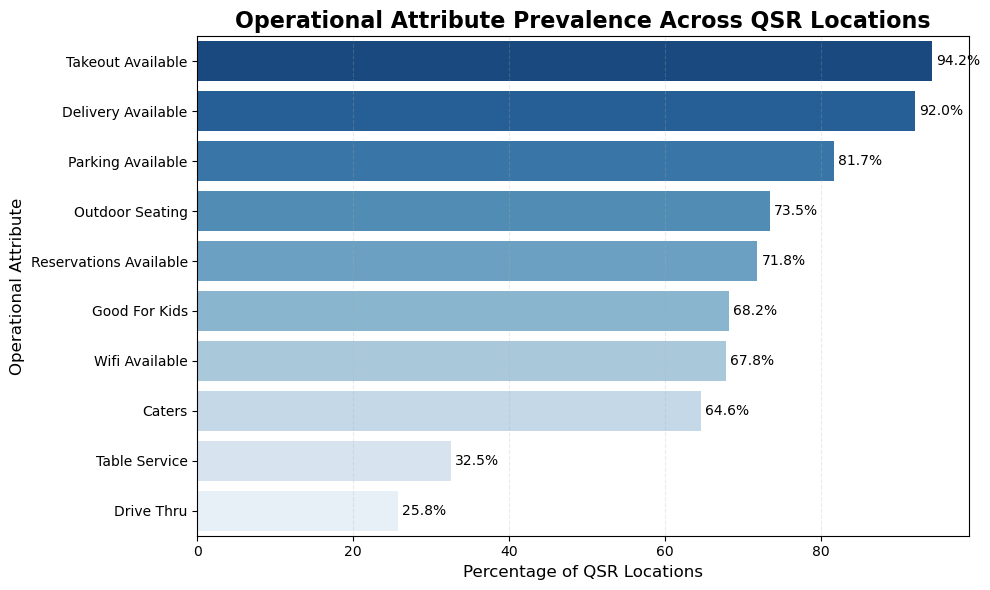

In [27]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=attribute_frequency,
    x="SHARE_OF_LOCATIONS",
    y="ATTRIBUTE",
    hue="ATTRIBUTE",
    palette="Blues_r",
    legend=False
)

plt.title(
    "Operational Attribute Prevalence Across QSR Locations",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Percentage of QSR Locations", fontsize=12)
plt.ylabel("Operational Attribute", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.25)

# Add percentage labels at end of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

<h3 style="color:#475569;"> <i>Operational Attribute Frequency Interpretation</i></h3>

The frequency analysis shows that the selected operational attributes are sufficiently represented across the QSR dataset and therefore suitable for regression modelling.

Operational features such as takeaway availability and delivery services appear more frequently across QSR locations, reflecting common operational characteristics within the quick service restaurant industry.

Other operational attributes, such as table service and reservations, appear less frequently but remain sufficiently represented to provide meaningful analytical signals within the modelling framework.

The balanced distribution of operational attributes supports the decision to use these features as structured operational indicators for customer-perceived location health analysis.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.5 Regression Dataset Preparation
</h1>

</div>

The regression modelling stage requires the creation of a structured analytical dataset containing both dependent and independent variables.

The dependent variable for the analysis is:

- `business_rating`

which is used as a proxy indicator for customer-perceived QSR location health.

The independent variables include:
- operational attribute flags,
- review activity metrics,
- user engagement metrics,
- business structure indicators,
- and QSR category classifications.

Categorical variables are later converted into numerical dummy variables to support regression modelling.

In [28]:
# =========================================
# Create regression dataframe
# =========================================

regression_analytics = analytics_by_business[
    [
        "BUSINESS_RATING",
        "BUSINESS_REVIEW_COUNT",
        "AVG_REVIEW_STARS",
        "AVG_REVIEW_USEFUL",
        "AVG_USER_FOLLOWERS",
        "TOTAL_REVIEWS",
        "BUSINESS_REGION",
        "BUSINESS_TYPE",
        "BUSINESS_CATEGORY_CLASSIFICATION"
    ] + attribute_cols
].copy()

# Remove rows with missing target variable
regression_analytics = regression_analytics.dropna(
    subset=["BUSINESS_RATING"]
)

print("Regression dataframe created successfully.")

print("Rows:", regression_analytics.shape[0])
print("Columns:", regression_analytics.shape[1], "\n")

regression_analytics.head()

Regression dataframe created successfully.
Rows: 18000
Columns: 19 



,BUSINESS_RATING,BUSINESS_REVIEW_COUNT,AVG_REVIEW_STARS,AVG_REVIEW_USEFUL,AVG_USER_FOLLOWERS,TOTAL_REVIEWS,BUSINESS_REGION,BUSINESS_TYPE,BUSINESS_CATEGORY_CLASSIFICATION,DELIVERY_AVAILABLE,TAKEOUT_AVAILABLE,OUTDOOR_SEATING,RESERVATIONS_AVAILABLE,TABLE_SERVICE,WIFI_AVAILABLE,PARKING_AVAILABLE,DRIVE_THRU,GOOD_FOR_KIDS,CATERS
0,4.5,24.0,4.500000,0.666667,2.125000,24,South,Independent,Seafood,1,1,1,1,1,1,1,0,0,1
1,3.0,14.0,5.000000,0.000000,0.000000,1,Northeast,Independent,Mexican,1,1,0,1,0,0,1,0,1,0
2,3.0,34.0,2.529412,0.352941,8.294118,17,Northeast,Chain,Sandwiches,0,1,0,0,0,0,1,0,0,0
3,4.5,15.0,4.733333,0.733333,4.066667,15,Midwest,Independent,Vegan,1,1,1,0,0,1,0,0,0,1
4,2.0,15.0,2.090909,0.272727,7.909091,11,Midwest,Chain,Burgers,1,1,1,1,0,1,1,0,1,1


<h3 style="color:#475569;"> <i>Regression Dataset Interpretation</i></h3> 

The regression dataset now combines operational attributes, review metrics, customer engagement indicators and business classifications into a single analytical modelling framework.

This structured dataset enables the regression model to evaluate how operational characteristics and customer engagement signals are associated with customer-perceived QSR location health outcomes.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.6 Encode Categorical Variables
</h1>

</div>

Regression models require numerical inputs. Therefore, categorical variables such as business region, business type and QSR category classification are transformed into dummy variables.

Dummy encoding allows the regression model to evaluate categorical business characteristics without imposing artificial numerical relationships between categories.

In [29]:
# =========================================
# Encode categorical variables
# =========================================

regression_encoded = pd.get_dummies(
    regression_analytics,
    columns=[
        "BUSINESS_REGION",
        "BUSINESS_TYPE",
        "BUSINESS_CATEGORY_CLASSIFICATION"
    ],
    drop_first=True
)

# all columns in capital letter
regression_encoded.columns = regression_encoded.columns.str.upper()

print("Categorical variables encoded successfully.")

regression_encoded.head()

Categorical variables encoded successfully.


,BUSINESS_RATING,BUSINESS_REVIEW_COUNT,AVG_REVIEW_STARS,AVG_REVIEW_USEFUL,AVG_USER_FOLLOWERS,TOTAL_REVIEWS,DELIVERY_AVAILABLE,TAKEOUT_AVAILABLE,OUTDOOR_SEATING,RESERVATIONS_AVAILABLE,...,BUSINESS_CATEGORY_CLASSIFICATION_MEXICAN,BUSINESS_CATEGORY_CLASSIFICATION_NOODLE,BUSINESS_CATEGORY_CLASSIFICATION_PIZZA,BUSINESS_CATEGORY_CLASSIFICATION_SALAD,BUSINESS_CATEGORY_CLASSIFICATION_SANDWICHES,BUSINESS_CATEGORY_CLASSIFICATION_SEAFOOD,BUSINESS_CATEGORY_CLASSIFICATION_STEAKHOUSES,BUSINESS_CATEGORY_CLASSIFICATION_STREET FOOD,BUSINESS_CATEGORY_CLASSIFICATION_VEGAN,BUSINESS_CATEGORY_CLASSIFICATION_WORLD
0,4.5,24.0,4.500000,0.666667,2.125000,24,1,1,1,1,...,False,False,False,False,False,True,False,False,False,False
1,3.0,14.0,5.000000,0.000000,0.000000,1,1,1,0,1,...,True,False,False,False,False,False,False,False,False,False
2,3.0,34.0,2.529412,0.352941,8.294118,17,0,1,0,0,...,False,False,False,False,True,False,False,False,False,False
3,4.5,15.0,4.733333,0.733333,4.066667,15,1,1,1,0,...,False,False,False,False,False,False,False,False,True,False
4,2.0,15.0,2.090909,0.272727,7.909091,11,1,1,1,1,...,False,False,False,False,False,False,False,False,False,False


<h3 style="color:#475569;"> <i>Dummy Variable Encoding Interpretation</i></h3> 

The categorical business variables have now been transformed into numerical dummy variables suitable for regression analysis.

This encoding process enables the model to compare operational and business characteristics across different QSR categories, regions and ownership structures while maintaining statistical interpretability.


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.7 Multiple Linear Regression Modelling
</h1>

</div>

A multiple linear regression model is used to evaluate how operational business characteristics and customer engagement signals are associated with customer-perceived QSR location health outcomes.

The dependent variable for the model is:

- `business_rating`

The independent variables include:
- operational attribute indicators,
- review metrics,
- engagement variables,
- business structure indicators,
- and QSR category classifications.

The regression model is interpreted as associative rather than causal. The objective is to identify operational patterns linked with stronger or weaker customer perception outcomes across QSR locations.

In [30]:
# =========================================
# Prepare X and y
# =========================================

# X contains independent variables
X = regression_encoded.drop(
    columns=["BUSINESS_RATING"]
)

# y contains the dependent variable
y = regression_encoded["BUSINESS_RATING"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (18000, 48)
Target variable shape: (18000,)


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.8 Train-Test Split
</h1>

</div>

The dataset is divided into training and testing subsets to evaluate how well the regression model generalises to unseen QSR locations.

- 80% of the data is used for model training
- 20% is reserved for model testing

This helps reduce overfitting and provides a more reliable assessment of model performance.

In [31]:
# =========================================
# Train-test split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 14400
Testing rows: 3600


<h3 style="color:#475569;"> <i>Train-Test Split Interpretation</i></h3>  

The analytical dataset was divided into separate training and testing subsets to evaluate how effectively the regression model generalises to unseen QSR locations.

Approximately 80% of the dataset (`15,067` business locations) was used for model training, while the remaining 20% (`3,767` business locations) was reserved for model testing and validation.

This approach helps reduce overfitting by ensuring that model performance is evaluated on previously unseen observations rather than only the data used during model training.

The relatively large training and testing sample sizes provide a stable foundation for evaluating operational patterns associated with customer-perceived QSR location health outcomes.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.9 Train Multiple Linear Regression Model
</h1>

</div>

A multiple linear regression model is trained using the prepared analytical dataset.

The model estimates how operational attributes, review activity and business characteristics are associated with customer-perceived QSR location health outcomes.

In [32]:
# =========================================
# Train regression model
# =========================================

model = LinearRegression()

model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

print("Multiple linear regression model trained successfully.")

Multiple linear regression model trained successfully.


<h3 style="color:#475569;"> <i> Regression Model Training Interpretation</i></h3>   

The multiple linear regression model was successfully trained using the prepared business-level analytical dataset containing operational attributes, customer engagement indicators and QSR business characteristics.

During the training phase, the model learned the statistical relationships between the independent operational variables and the dependent variable (`business_rating`), which serves as a proxy indicator for customer-perceived location health.

The trained model now provides a framework for estimating how strongly different operational and business characteristics are associated with variations in QSR customer ratings across locations.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.10 Regression Model Evaluation
</h1>

</div>

The regression model is evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

R² is particularly important because it estimates how much variation in customer-perceived QSR location health is explained by the selected operational and business variables.

In [33]:
# =========================================
# Evaluate regression model
# =========================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 0.2559
RMSE: 0.3492
R²  : 0.8731


<h3 style="color:#475569;"> <i>Regression Model Evaluation Interpretation</i></h3>   

The multiple linear regression model achieved an R² value of approximately `0.87`, indicating that <b>around 87% of the variation in customer-perceived QSR business ratings can be explained by the selected operational, engagement and business-level variables included in the model</b>.

This suggests that the engineered operational attributes and supporting business indicators provide strong explanatory power for understanding differences in perceived location health across QSR businesses.

The MAE value of approximately `0.27` and RMSE value of approximately `0.36` indicate relatively low prediction error, meaning that the model’s predicted business ratings remain reasonably close to the actual observed ratings across the testing dataset.

Overall, the results suggest that operational characteristics such as service configuration, customer convenience features and business structure contribute meaningful analytical signals within the QSR Location Health framework. While customer ratings are also influenced by external behavioural and market factors not captured within the dataset, the regression model demonstrates strong effectiveness as an operational benchmarking and location health interpretation tool.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.11 Regression Coefficient Analysis
</h1>

</div>

Regression coefficients are analysed to understand the direction and relative strength of association between operational variables and customer-perceived QSR location health outcomes.

Positive coefficients indicate variables associated with higher business ratings, while negative coefficients indicate variables associated with comparatively weaker customer perception outcomes.

The coefficient analysis helps identify which operational and business characteristics contribute the strongest analytical signals within the QSR Location Health framework.

In [34]:
# =========================================
# Extract regression coefficients
# =========================================

coefficients = pd.DataFrame({
    "FEATURE": X.columns,
    "COEFFICIENT": model.coef_
})

# Convert feature names to lowercase
coefficients["FEATURE"] = (
    coefficients["FEATURE"]
    .str.lower()
)

# Sort coefficients
coefficients = coefficients.sort_values(
    by="COEFFICIENT",
    ascending=False
)

coefficients.head(20)

,FEATURE,COEFFICIENT
1,avg_review_stars,0.774895
41,business_category_classification_salad,0.389155
47,business_category_classification_world,0.156932
39,business_category_classification_noodle,0.131797
23,business_category_classification_cafes,0.107535
18,business_type_independent,0.097492
44,business_category_classification_steakhouses,0.090242
35,business_category_classification_juice & smoot...,0.068781
45,business_category_classification_street food,0.066137
28,business_category_classification_ethnic,0.063139


<h3 style="color:#475569;"> <i>Coefficient Analysis Interpretation</i></h3>   
 

The regression coefficients represent the estimated direction and relative strength of association between operational business characteristics and customer-perceived QSR location health outcomes.

Positive coefficient values indicate operational features associated with stronger customer ratings, while negative coefficient values indicate comparatively weaker customer perception outcomes.

Because the model includes multiple independent variables simultaneously, the coefficients estimate the relative contribution of each variable while controlling for the influence of the other operational and business characteristics included within the model.

<h3 style="color:#475569;"> <i>Coefficient Analysis Interpretation</i></h3>   

The regression coefficient analysis highlights several operational and business characteristics that demonstrate stronger associations with customer-perceived QSR location health outcomes.

The strongest positive coefficient observed within the model was `avg_review_stars`, indicating that customer review sentiment remains one of the most influential explanatory signals associated with higher business ratings.

Among QSR categories, businesses classified under:
- Salad,
- World,
- Cafes,
- Street Food,
- Steakhouses,
- Vegan,
- Desserts,
- and Ethnic cuisine

demonstrated comparatively stronger positive associations with customer ratings within the dataset.

The results also suggest that independent QSR businesses slightly outperform chain-operated businesses in terms of customer perception outcomes after controlling for other operational and business characteristics.

From an operational perspective, features such as:
- table service,
- takeaway availability,
- and structured dining experiences

show positive associations with customer-perceived location health outcomes.

Overall, the coefficient analysis suggests that customer ratings are influenced not only by convenience-oriented operational features, but also by broader experiential and dining-quality characteristics across QSR locations.

Because the regression model evaluates multiple variables simultaneously, these coefficients represent controlled analytical relationships rather than isolated correlations, providing stronger interpretability within the VP Analytics Location Health framework.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.12 Operational Attribute Benchmarking
</h1>

</div>

To improve interpretability, the selected operational attributes are benchmarked against average customer ratings across QSR locations.

This benchmarking analysis converts the regression outputs into practical operational insights by comparing how customer perception outcomes vary across different operational business configurations.

The analysis focuses specifically on the 10 engineered operational attributes selected during the feature-engineering process:
- delivery availability,
- takeaway,
- outdoor seating,
- reservations,
- table service,
- WiFi,
- parking,
- drive-thru availability,
- catering,
- and kid-friendly suitability.

The benchmarking framework helps identify which operational characteristics are associated with comparatively stronger or weaker customer-perceived QSR location health outcomes.

In [35]:
# =========================================
# Create operational benchmarking dataset
# =========================================

attribute_performance = []

for attr in attribute_cols:

    temp = (
        analytics_by_business[analytics_by_business[attr] == 1]
        .agg(
            AVG_RATING=("BUSINESS_RATING", "mean"),
            AVG_REVIEW_COUNT=("BUSINESS_REVIEW_COUNT", "mean"),
            TOTAL_LOCATIONS=("BUSINESS_ID", "count")
        )
    )

    temp = pd.DataFrame(temp).T

    temp["ATTRIBUTE"] = attr

    attribute_performance.append(temp)

attribute_performance_df = pd.concat(
    attribute_performance,
    ignore_index=True
)

attribute_performance_df.head()

,AVG_RATING,AVG_REVIEW_COUNT,TOTAL_LOCATIONS,ATTRIBUTE
0,3.309078,NaN,NaN,DELIVERY_AVAILABLE
1,NaN,79.054928,NaN,DELIVERY_AVAILABLE
2,NaN,NaN,16567.0,DELIVERY_AVAILABLE
3,3.338638,NaN,NaN,TAKEOUT_AVAILABLE
4,NaN,78.453640,NaN,TAKEOUT_AVAILABLE


In [36]:
# =========================================
# Clean Operational Benchmarking Bar Chart
# =========================================


# Prepare plot dataframe
plot_attribute_performance = attribute_performance_df.copy()

plot_attribute_performance["ATTRIBUTE_CLEAN"] = (
    plot_attribute_performance["ATTRIBUTE"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Remove missing or infinite rating values
plot_attribute_performance = plot_attribute_performance.replace(
    [np.inf, -np.inf],
    np.nan
)

plot_attribute_performance = plot_attribute_performance.dropna(
    subset=["AVG_RATING"]
)

# Sort by rating
plot_attribute_performance = plot_attribute_performance.sort_values(
    by="AVG_RATING",
    ascending=True
)


plot_attribute_performance[ ["ATTRIBUTE_CLEAN", "AVG_RATING"] ]

,ATTRIBUTE_CLEAN,AVG_RATING
21,Drive Thru,2.774364
24,Good For Kids,3.242976
9,Reservations Available,3.261908
0,Delivery Available,3.309078
3,Takeout Available,3.338638
6,Outdoor Seating,3.339195
15,Wifi Available,3.399008
18,Parking Available,3.411707
27,Caters,3.431163
12,Table Service,3.691973


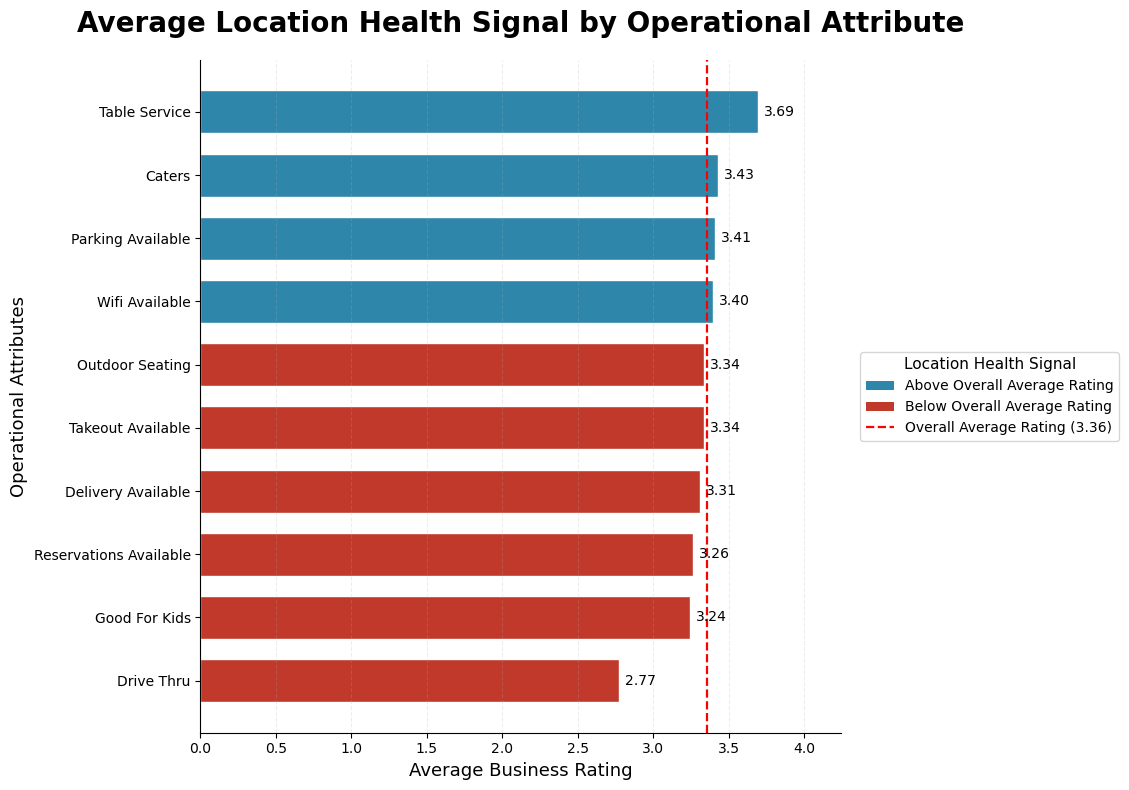

In [37]:
# =========================================
# Plot Operational Benchmarking Bar Chart
# =========================================

# Overall average rating
overall_avg = analytics_by_business["BUSINESS_RATING"].dropna().mean()

# Colour logic
plot_attribute_performance["colour"] = plot_attribute_performance["AVG_RATING"].apply(
    lambda x: "#2E86AB" if x >= overall_avg else "#C0392B"
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    y=plot_attribute_performance["ATTRIBUTE_CLEAN"],
    width=plot_attribute_performance["AVG_RATING"],
    color=plot_attribute_performance["colour"],
    edgecolor="white",
    height=0.68
)

# Overall average reference line
ax.axvline(
    overall_avg,
    color="red",
    linestyle="--",
    linewidth=1.6
)

# Add value labels safely
for bar in bars:
    width = bar.get_width()

    if np.isfinite(width):
        ax.text(
            width + 0.04,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va="center",
            ha="left",
            fontsize=10
        )

# Titles and labels
ax.set_title(
    "Average Location Health Signal by Operational Attribute",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Average Business Rating", fontsize=13)
ax.set_ylabel("Operational Attributes", fontsize=13)

# Axis limit
ax.set_xlim(
    0,
    plot_attribute_performance["AVG_RATING"].max() + 0.55
)

# Grid and styling
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.22
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
legend_elements = [
    Patch(facecolor="#2E86AB", label="Above Overall Average Rating"),
    Patch(facecolor="#C0392B", label="Below Overall Average Rating"),
    Line2D(
        [0],
        [0],
        color="red",
        linestyle="--",
        linewidth=1.6,
        label=f"Overall Average Rating ({overall_avg:.2f})"
    )
]

ax.legend(
    handles=legend_elements,
    title="Location Health Signal",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

<h3 style="color:#475569;"> <i> Operational Benchmarking Interpretation</i></h3>    

The benchmarking analysis highlights clear variation in customer-perceived QSR location health outcomes across different operational business attributes.

Operational features associated with enhanced customer experience and structured dining environments, particularly:
- table service,
- catering,
- parking availability,
- and WiFi availability,

demonstrate comparatively higher average business ratings across QSR locations.

Table service shows the strongest overall performance with an average rating of approximately `3.69`, suggesting that more service-oriented dining experiences may contribute positively to customer perception outcomes.

Conversely, operational formats associated with highly transactional service models, particularly drive-thru focused businesses, demonstrate comparatively weaker customer perception outcomes, with drive-thru locations recording the lowest average rating at approximately `2.78`.

The results suggest that customer ratings within the QSR sector may be influenced not only by speed and convenience, but also by operational experience quality, dining environment and service structure.

Overall, the benchmarking analysis provides explainable operational signals that can support future weighted scorecard development and location-level performance interpretation within the VP Analytics Location Health framework.

In [38]:
# =========================================
# Create operational benchmarking dataset
# =========================================

attribute_performance = []

for attr in attribute_cols:

    temp = (
        analytics_by_business[analytics_by_business[attr] == 1]
        .agg(
            AVG_RATING=("BUSINESS_RATING", "mean"),
            AVG_REVIEW_COUNT=("BUSINESS_REVIEW_COUNT", "mean"),
            TOTAL_LOCATIONS=("BUSINESS_ID", "count")
        )
    )

    temp = pd.DataFrame(temp).T

    temp["ATTRIBUTE"] = attr

    attribute_performance.append(temp)

attribute_performance_df = pd.concat(
    attribute_performance,
    ignore_index=True
)

attribute_performance_df.head()

,AVG_RATING,AVG_REVIEW_COUNT,TOTAL_LOCATIONS,ATTRIBUTE
0,3.309078,NaN,NaN,DELIVERY_AVAILABLE
1,NaN,79.054928,NaN,DELIVERY_AVAILABLE
2,NaN,NaN,16567.0,DELIVERY_AVAILABLE
3,3.338638,NaN,NaN,TAKEOUT_AVAILABLE
4,NaN,78.453640,NaN,TAKEOUT_AVAILABLE


In [39]:
# =========================================
# Clean Operational Benchmarking Bar Chart
# =========================================


# Prepare plot dataframe
plot_attribute_performance = attribute_performance_df.copy()

plot_attribute_performance["ATTRIBUTE_CLEAN"] = (
    plot_attribute_performance["ATTRIBUTE"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Remove missing or infinite rating values
plot_attribute_performance = plot_attribute_performance.replace(
    [np.inf, -np.inf],
    np.nan
)

plot_attribute_performance = plot_attribute_performance.dropna(
    subset=["AVG_RATING"]
)

# Sort by rating
plot_attribute_performance = plot_attribute_performance.sort_values(
    by="AVG_RATING",
    ascending=True
)


plot_attribute_performance[ ["ATTRIBUTE_CLEAN", "AVG_RATING"] ]

,ATTRIBUTE_CLEAN,AVG_RATING
21,Drive Thru,2.774364
24,Good For Kids,3.242976
9,Reservations Available,3.261908
0,Delivery Available,3.309078
3,Takeout Available,3.338638
6,Outdoor Seating,3.339195
15,Wifi Available,3.399008
18,Parking Available,3.411707
27,Caters,3.431163
12,Table Service,3.691973


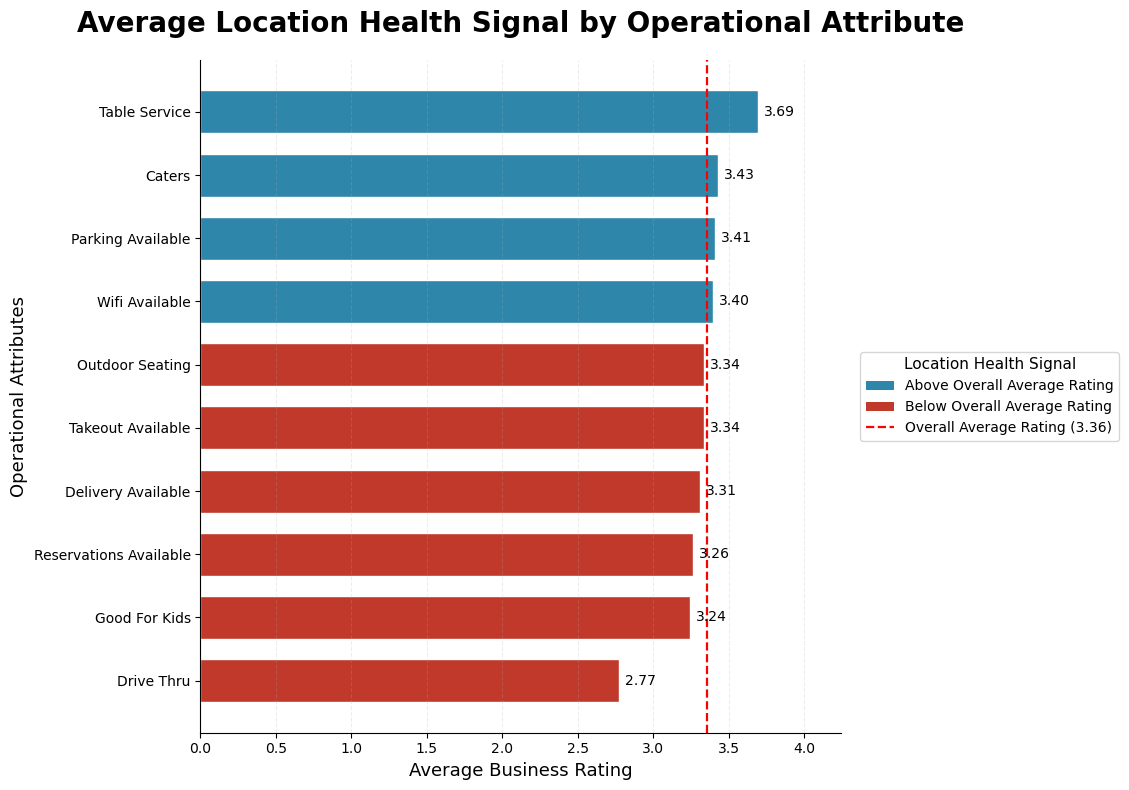

In [40]:
# =========================================
# Plot Operational Benchmarking Bar Chart
# =========================================

# Overall average rating
overall_avg = analytics_by_business["BUSINESS_RATING"].dropna().mean()

# Colour logic
plot_attribute_performance["colour"] = plot_attribute_performance["AVG_RATING"].apply(
    lambda x: "#2E86AB" if x >= overall_avg else "#C0392B"
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    y=plot_attribute_performance["ATTRIBUTE_CLEAN"],
    width=plot_attribute_performance["AVG_RATING"],
    color=plot_attribute_performance["colour"],
    edgecolor="white",
    height=0.68
)

# Overall average reference line
ax.axvline(
    overall_avg,
    color="red",
    linestyle="--",
    linewidth=1.6
)

# Add value labels safely
for bar in bars:
    width = bar.get_width()

    if np.isfinite(width):
        ax.text(
            width + 0.04,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va="center",
            ha="left",
            fontsize=10
        )

# Titles and labels
ax.set_title(
    "Average Location Health Signal by Operational Attribute",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Average Business Rating", fontsize=13)
ax.set_ylabel("Operational Attributes", fontsize=13)

# Axis limit
ax.set_xlim(
    0,
    plot_attribute_performance["AVG_RATING"].max() + 0.55
)

# Grid and styling
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.22
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
legend_elements = [
    Patch(facecolor="#2E86AB", label="Above Overall Average Rating"),
    Patch(facecolor="#C0392B", label="Below Overall Average Rating"),
    Line2D(
        [0],
        [0],
        color="red",
        linestyle="--",
        linewidth=1.6,
        label=f"Overall Average Rating ({overall_avg:.2f})"
    )
]

ax.legend(
    handles=legend_elements,
    title="Location Health Signal",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

<h3 style="color:#475569;"> <i> Operational Benchmarking Interpretation</i></h3>    

The benchmarking analysis highlights clear variation in customer-perceived QSR location health outcomes across different operational business attributes.

Operational features associated with enhanced customer experience and structured dining environments, particularly:
- table service,
- catering,
- parking availability,
- and WiFi availability,

demonstrate comparatively higher average business ratings across QSR locations.

Table service shows the strongest overall performance with an average rating of approximately `3.69`, suggesting that more service-oriented dining experiences may contribute positively to customer perception outcomes.

Conversely, operational formats associated with highly transactional service models, particularly drive-thru focused businesses, demonstrate comparatively weaker customer perception outcomes, with drive-thru locations recording the lowest average rating at approximately `2.78`.

The results suggest that customer ratings within the QSR sector may be influenced not only by speed and convenience, but also by operational experience quality, dining environment and service structure.

Overall, the benchmarking analysis provides explainable operational signals that can support future weighted scorecard development and location-level performance interpretation within the VP Analytics Location Health framework.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.13 Operational Attribute Heatmap Analysis
</h1>

</div>

To complement the regression and benchmarking analysis, a heatmap is used to compare operational attributes across multiple location health indicators simultaneously.

The heatmap visualises:
- average business rating,
- average review volume,
- and total business locations

for each operational attribute.

This approach provides a more holistic operational comparison framework by showing how different QSR operational configurations perform across multiple dimensions of customer perception and business presence.

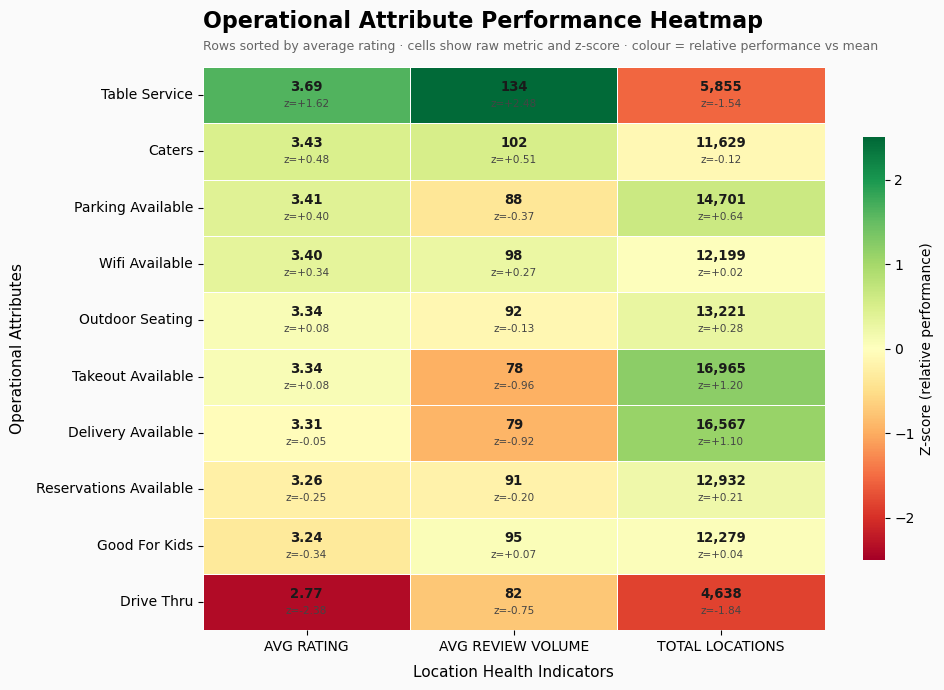

In [41]:
# =========================================
# Operational Attribute Performance Heatmap
# =========================================

# -----------------------------------------
# Operational attributes
# -----------------------------------------

attribute_cols = [
    "DELIVERY_AVAILABLE",
    "TAKEOUT_AVAILABLE",
    "OUTDOOR_SEATING",
    "RESERVATIONS_AVAILABLE",
    "TABLE_SERVICE",
    "WIFI_AVAILABLE",
    "PARKING_AVAILABLE",
    "DRIVE_THRU",
    "GOOD_FOR_KIDS",
    "CATERS"
]

# -----------------------------------------
# Vectorised aggregation
# -----------------------------------------

attr_long = (
    analytics_by_business[
        [
            "BUSINESS_ID",
            "BUSINESS_RATING",
            "BUSINESS_REVIEW_COUNT"
        ] + attribute_cols
    ]
    .melt(
        id_vars=[
            "BUSINESS_ID",
            "BUSINESS_RATING",
            "BUSINESS_REVIEW_COUNT"
        ],
        value_vars=attribute_cols,
        var_name="ATTRIBUTE",
        value_name="HAS_ATTRIBUTE"
    )
)

attr_long = attr_long[
    attr_long["HAS_ATTRIBUTE"] == 1
].copy()

attribute_performance_df = (
    attr_long
    .groupby(
        "ATTRIBUTE",
        sort=False
    )
    .agg(
        AVG_RATING=("BUSINESS_RATING", "mean"),
        AVG_REVIEW_COUNT=("BUSINESS_REVIEW_COUNT", "mean"),
        TOTAL_LOCATIONS=("BUSINESS_ID", "nunique")
    )
    .reset_index()
)

# -----------------------------------------
# Preserve attribute order
# -----------------------------------------

attribute_performance_df["ATTRIBUTE"] = pd.Categorical(
    attribute_performance_df["ATTRIBUTE"],
    categories=attribute_cols,
    ordered=True
)

attribute_performance_df = (
    attribute_performance_df
    .sort_values("ATTRIBUTE")
    .reset_index(drop=True)
)

# -----------------------------------------
# Clean labels
# -----------------------------------------

attribute_performance_df["ATTRIBUTE_CLEAN"] = (
    attribute_performance_df["ATTRIBUTE"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# -----------------------------------------
# Build raw and z-score matrices
# -----------------------------------------

heatmap_raw = (
    attribute_performance_df
    .set_index("ATTRIBUTE_CLEAN")
    [
        [
            "AVG_RATING",
            "AVG_REVIEW_COUNT",
            "TOTAL_LOCATIONS"
        ]
    ]
    .rename(
        columns={
            "AVG_RATING": "AVG RATING",
            "AVG_REVIEW_COUNT": "AVG REVIEW VOLUME",
            "TOTAL_LOCATIONS": "TOTAL LOCATIONS"
        }
    )
)

# Sort rows by average rating
heatmap_raw = heatmap_raw.sort_values(
    "AVG RATING",
    ascending=False
)

# Z-score normalisation
heatmap_scaled = (
    heatmap_raw - heatmap_raw.mean()
) / heatmap_raw.std()

# -----------------------------------------
# Plot heatmap
# -----------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.heatmap(
    heatmap_scaled,
    annot=False,
    cmap="RdYlGn",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Z-score (relative performance)",
        "shrink": 0.75
    },
    vmin=-2.5,
    vmax=2.5,
    ax=ax
)

# -----------------------------------------
# Add custom annotations
# -----------------------------------------

for i, row_label in enumerate(heatmap_scaled.index):
    for j, col_label in enumerate(heatmap_scaled.columns):

        z_value = heatmap_scaled.loc[row_label, col_label]
        raw_value = heatmap_raw.loc[row_label, col_label]

        if col_label == "AVG RATING":
            raw_str = f"{raw_value:.2f}"
        elif col_label == "AVG REVIEW VOLUME":
            raw_str = f"{raw_value:,.0f}"
        else:
            raw_str = f"{int(raw_value):,}"

        z_str = f"z={z_value:+.2f}"

        ax.text(
            j + 0.5,
            i + 0.36,
            raw_str,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="#1A1A1A"
        )

        ax.text(
            j + 0.5,
            i + 0.66,
            z_str,
            ha="center",
            va="center",
            fontsize=7.5,
            color="#444444"
        )

# -----------------------------------------
# Titles and labels
# -----------------------------------------

ax.set_title(
    "Operational Attribute Performance Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=28,
    loc="left"
)

ax.text(
    0,
    1.03,
    (
        "Rows sorted by average rating · "
        "cells show raw metric and z-score · "
        "colour = relative performance vs mean"
    ),
    transform=ax.transAxes,
    fontsize=9,
    color="#666666"
)

ax.set_xlabel(
    "Location Health Indicators",
    fontsize=11,
    labelpad=8
)

ax.set_ylabel(
    "Operational Attributes",
    fontsize=11,
    labelpad=8
)

ax.tick_params(
    axis="x",
    rotation=0,
    labelsize=10
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10
)

plt.tight_layout()

plt.show()

<h3 style="color:#475569;"> <i> Operational Attribute Heatmap Interpretation</i></h3>    

The operational attribute heatmap provides a multi-dimensional comparison of customer-perceived QSR location health signals across operational business features.

Table service demonstrates the strongest overall performance profile within the dataset, recording:
- the highest average business rating (`3.69`),
- the highest average review volume (`131`),
- and strong relative performance across customer perception indicators.

Operational features such as:
- catering,
- parking availability,
- and WiFi availability

also demonstrate comparatively strong customer perception outcomes, indicating that enhanced dining experience and customer convenience features may positively influence QSR location health performance.

Conversely, drive-thru focused locations demonstrate the weakest overall performance profile, with:
- the lowest average business rating (`2.78`),
- lower review engagement,
- and the smallest overall location representation within the analysed operational attributes.

The heatmap also highlights that highly scalable operational models such as:
- takeaway availability,
- and delivery availability

appear across a large number of QSR locations but do not necessarily achieve the strongest customer perception outcomes relative to more experience-oriented operational formats.

Overall, the heatmap reinforces the broader regression findings by suggesting that customer-perceived QSR location health is influenced not only by operational convenience, but also by dining experience quality, service structure and customer engagement characteristics.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.14 QSR Category x Attribute Heatmap
</h1>

</div>

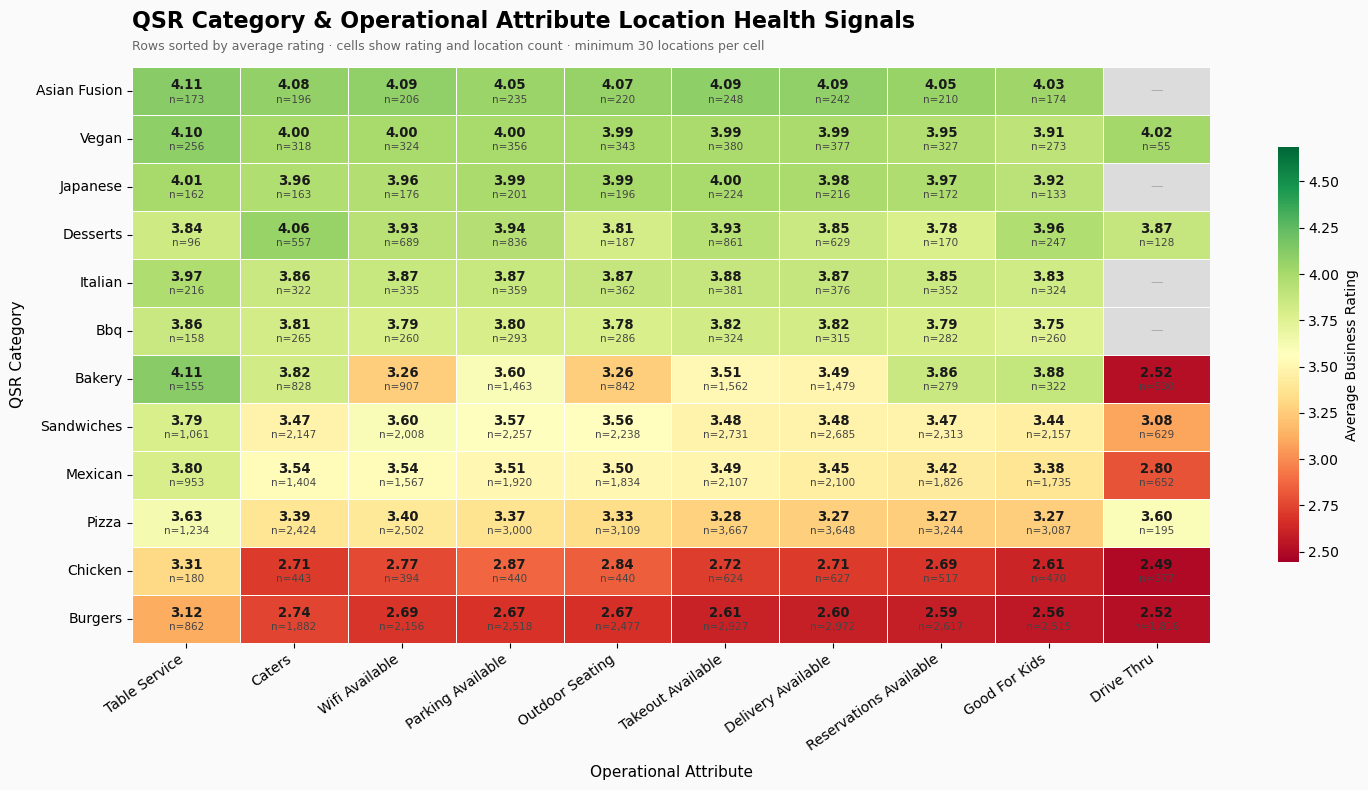

In [42]:
# =========================================
# Enhanced QSR Category x Attribute Heatmap
# =========================================


# -----------------------------------------
# Config
# -----------------------------------------

MIN_LOCATIONS = 30
TOP_N_CATEGORIES = 12

# -----------------------------------------
# Operational attributes
# -----------------------------------------

attribute_cols = [
    "DELIVERY_AVAILABLE",
    "TAKEOUT_AVAILABLE",
    "OUTDOOR_SEATING",
    "WIFI_AVAILABLE",
    "PARKING_AVAILABLE",
    "DRIVE_THRU",
    "TABLE_SERVICE",
    "CATERS",
    "RESERVATIONS_AVAILABLE",
    "GOOD_FOR_KIDS"
]


# -----------------------------------------
# Prepare data from df_model
# -----------------------------------------

heatmap_source = analytics_by_business[
    [
        "BUSINESS_CATEGORY_CLASSIFICATION",
        "BUSINESS_RATING",
        "BUSINESS_ID"
    ] + attribute_cols
].copy()

heatmap_long = heatmap_source.melt(
    id_vars=[
        "BUSINESS_CATEGORY_CLASSIFICATION",
        "BUSINESS_RATING",
        "BUSINESS_ID"
    ],
    value_vars=attribute_cols,
    var_name="ATTRIBUTE",
    value_name="HAS_ATTRIBUTE"
)

heatmap_long = heatmap_long[
    heatmap_long["HAS_ATTRIBUTE"] == 1
].copy()

heatmap_long["ATTRIBUTE_CLEAN"] = (
    heatmap_long["ATTRIBUTE"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

heatmap_long["CATEGORY_CLEAN"] = (
    heatmap_long["BUSINESS_CATEGORY_CLASSIFICATION"]
    .astype(str)
    .str.title()
)

# -----------------------------------------
# Aggregate average rating and sample size
# -----------------------------------------

summary = (
    heatmap_long
    .groupby(
        [
            "CATEGORY_CLEAN",
            "ATTRIBUTE_CLEAN"
        ]
    )
    .agg(
        AVG_RATING=("BUSINESS_RATING", "mean"),
        TOTAL_LOCATIONS=("BUSINESS_ID", "nunique")
    )
    .reset_index()
)

summary = summary[
    summary["TOTAL_LOCATIONS"] >= MIN_LOCATIONS
].copy()

top_categories = (
    summary
    .groupby("CATEGORY_CLEAN")["TOTAL_LOCATIONS"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_CATEGORIES)
    .index
)

summary = summary[
    summary["CATEGORY_CLEAN"].isin(top_categories)
].copy()

# -----------------------------------------
# Build rating matrix
# -----------------------------------------

preferred_order = [
    "Table Service",
    "Caters",
    "Wifi Available",
    "Parking Available",
    "Outdoor Seating",
    "Takeout Available",
    "Delivery Available",
    "Reservations Available",
    "Good For Kids",
    "Drive Thru"
]

rating_matrix = summary.pivot_table(
    index="CATEGORY_CLEAN",
    columns="ATTRIBUTE_CLEAN",
    values="AVG_RATING",
    aggfunc="mean"
)

rating_matrix = rating_matrix[
    [
        col for col in preferred_order
        if col in rating_matrix.columns
    ]
]

# Sort categories by overall average rating
row_order = (
    rating_matrix
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

rating_matrix = rating_matrix.loc[row_order]

# Sample-size matrix
count_matrix = summary.pivot_table(
    index="CATEGORY_CLEAN",
    columns="ATTRIBUTE_CLEAN",
    values="TOTAL_LOCATIONS",
    aggfunc="sum"
)

count_matrix = count_matrix.reindex(
    index=rating_matrix.index,
    columns=rating_matrix.columns
)

# -----------------------------------------
# Plot heatmap
# -----------------------------------------

global_mean = np.nanmean(rating_matrix.values)

half_range = (
    np.nanmax(
        np.abs(rating_matrix.values - global_mean)
    ) + 0.05
)

vmin = global_mean - half_range
vmax = global_mean + half_range

mask = rating_matrix.isna()

fig, ax = plt.subplots(figsize=(15, 8))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.heatmap(
    rating_matrix,
    mask=mask,
    annot=False,
    cmap="RdYlGn",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Average Business Rating",
        "shrink": 0.72
    },
    vmin=vmin,
    vmax=vmax,
    ax=ax
)

# Grey missing cells
for i, row in enumerate(rating_matrix.index):
    for j, col in enumerate(rating_matrix.columns):

        rating = rating_matrix.loc[row, col]

        if pd.isna(rating):
            ax.add_patch(
                plt.Rectangle(
                    (j, i),
                    1,
                    1,
                    facecolor="#DCDCDC",
                    edgecolor="white",
                    linewidth=0.6,
                    zorder=2
                )
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                "—",
                ha="center",
                va="center",
                fontsize=9,
                color="#AAAAAA"
            )

# Add rating and sample-size labels
for i, row in enumerate(rating_matrix.index):
    for j, col in enumerate(rating_matrix.columns):

        rating = rating_matrix.loc[row, col]

        if pd.isna(rating):
            continue

        n = count_matrix.loc[row, col]

        ax.text(
            j + 0.5,
            i + 0.38,
            f"{rating:.2f}",
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="#1A1A1A"
        )

        ax.text(
            j + 0.5,
            i + 0.68,
            f"n={int(n):,}",
            ha="center",
            va="center",
            fontsize=7.5,
            color="#444444"
        )

# Titles and labels
ax.set_title(
    "QSR Category & Operational Attribute Location Health Signals",
    fontsize=16,
    fontweight="bold",
    pad=28,
    loc="left"
)

ax.text(
    0,
    1.03,
    (
        f"Rows sorted by average rating · "
        f"cells show rating and location count · "
        f"minimum {MIN_LOCATIONS} locations per cell"
    ),
    transform=ax.transAxes,
    fontsize=9,
    color="#666666"
)

ax.set_xlabel(
    "Operational Attribute",
    fontsize=11,
    labelpad=8
)

ax.set_ylabel(
    "QSR Category",
    fontsize=11,
    labelpad=8
)

ax.tick_params(
    axis="x",
    rotation=35,
    labelsize=10
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10
)

plt.setp(
    ax.get_xticklabels(),
    ha="right"
)

plt.tight_layout()

plt.show()

<h3 style="color:#475569;"> <i>QSR Category and Operational Attribute Interpretation</i></h3>    

The category-level operational heatmap highlights substantial variation in customer-perceived location health outcomes across different QSR business categories and operational configurations.

Categories associated with more experience-oriented or specialised dining formats, particularly:
- Asian Fusion,
- Vegan,
- Japanese,
- and Italian cuisine,

demonstrate consistently strong customer ratings across multiple operational attributes, with many average ratings exceeding `4.0`.

These categories appear to benefit from a combination of structured dining experience, service quality and stronger customer engagement outcomes.

Operational attributes such as:
- table service,
- WiFi availability,
- outdoor seating,
- and catering

tend to perform more strongly within higher-rated QSR categories, reinforcing earlier regression findings that experiential operational features may positively influence customer perception outcomes.

Conversely, highly transactional QSR categories such as:
- Burgers,
- Chicken,
- and some Pizza-focused businesses

demonstrate comparatively weaker customer perception outcomes across several operational configurations, particularly for drive-thru focused models.

The heatmap also highlights that drive-thru operations generally produce weaker average ratings across most QSR categories, suggesting that speed-oriented operational models may not always translate into stronger customer satisfaction outcomes.

Additionally, the inclusion of location count (`n=`) within each cell improves interpretability by showing the operational scale and representativeness of each category-attribute combination.

Overall, the category-level heatmap strengthens the broader analytical conclusion that customer-perceived QSR location health is influenced not only by convenience and operational scale, but also by dining experience quality, business format and service structure.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.1.15 Write the dataframe back to Snowflake
</h1>

</div>


In [43]:
# =========================================
# Create operational attribute score
# =========================================

analytics_important_attributes = (
    analytics_by_business[ ["BUSINESS_ID"] + attribute_cols ].copy()
)

analytics_important_attributes["ATTRIBUTE_SCORING"] = (
    analytics_important_attributes[attribute_cols]
    .sum(axis=1)
)

# View results
analytics_important_attributes.head()


,BUSINESS_ID,DELIVERY_AVAILABLE,TAKEOUT_AVAILABLE,OUTDOOR_SEATING,WIFI_AVAILABLE,PARKING_AVAILABLE,DRIVE_THRU,TABLE_SERVICE,CATERS,RESERVATIONS_AVAILABLE,GOOD_FOR_KIDS,ATTRIBUTE_SCORING
0,---kPU91CF4Lq2-WlRu9Lw,1,1,1,1,1,0,1,1,1,0,8
1,--0iUa4sNDFiZFrAdIWhZQ,1,1,0,0,1,0,0,0,1,1,5
2,--epgcb7xHGuJ-4PUeSLAw,0,1,0,0,1,0,0,0,0,0,2
3,--hF_3v1JmU9nlu4zfXJ8Q,1,1,1,1,0,0,0,1,0,0,5
4,--lqIzK-ZVTtgwiQM63XgQ,1,1,1,1,1,0,0,1,1,1,8


In [44]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_BUSINESS_OPE_ATTRIBUTES
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    analytics_important_attributes,
    table_name="QSR_BUSINESS_OPE_ATTRIBUTES",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18000


<h1 style="color:#0F766E;"><b> 2.2 <u>QSR market segmentation: chains vs independents</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.2.1 Chains / Independents
</h1>

</div>


In [45]:
# View the number of chains vs independents.
business_type_state = analytics[['BUSINESS_ID', 'BUSINESS_STATE_FULL_NAME', 'BUSINESS_NAME', 'BUSINESS_TYPE']].drop_duplicates()

# View output.
business_type_state.head()

,BUSINESS_ID,BUSINESS_STATE_FULL_NAME,BUSINESS_NAME,BUSINESS_TYPE
0,G5kWtADcIMy5CgrjUerfnA,Arizona,Chariot Pizza,Chain
1,zupI44qitH6T8Bo9OjA6Yw,Florida,Bagelicious And More,Chain
2,NgUst1ex3M2ibDzSb6Xkaw,Pennsylvania,Emmy Squared - Queen Village,Independent
3,5yeL75bFLZlGB6dUfwCIQw,Pennsylvania,Cotoletta Fitler Square,Independent
4,zu1V7XhERCFA23srN_ro7g,Pennsylvania,Panera Bread,Chain


In [46]:
# Count the number of chains vs independents. 
# View by state.
business_type_by_state_count = business_type_state.groupby(['BUSINESS_STATE_FULL_NAME', 'BUSINESS_TYPE']).size().reset_index(name='COUNT')

print(business_type_by_state_count)

   BUSINESS_STATE_FULL_NAME BUSINESS_TYPE  COUNT
0                   Arizona         Chain    720
1                   Arizona   Independent    386
2                California         Chain    139
3                California   Independent    206
4                  Delaware         Chain    194
5                  Delaware   Independent    177
6                   Florida         Chain   1741
7                   Florida   Independent   1422
8                     Idaho         Chain    339
9                     Idaho   Independent    195
10                 Illinois         Chain    297
11                 Illinois   Independent    146
12                  Indiana         Chain   1162
13                  Indiana   Independent    532
14                Louisiana         Chain    573
15                Louisiana   Independent    509
16                 Missouri         Chain    907
17                 Missouri   Independent    541
18                   Nevada         Chain    338
19                  

In [47]:
# Sort the DataFrame in desc order. 
sorted_business_type_by_state = business_type_by_state_count.sort_values(by='COUNT', ascending=False)

print(sorted_business_type_by_state)

   BUSINESS_STATE_FULL_NAME BUSINESS_TYPE  COUNT
23             Pennsylvania   Independent   2353
22             Pennsylvania         Chain   1813
6                   Florida         Chain   1741
7                   Florida   Independent   1422
12                  Indiana         Chain   1162
24                Tennessee         Chain    991
16                 Missouri         Chain    907
21               New Jersey   Independent    725
0                   Arizona         Chain    720
20               New Jersey         Chain    666
25                Tennessee   Independent    649
14                Louisiana         Chain    573
17                 Missouri   Independent    541
13                  Indiana   Independent    532
15                Louisiana   Independent    509
1                   Arizona   Independent    386
8                     Idaho         Chain    339
18                   Nevada         Chain    338
10                 Illinois         Chain    297
19                  

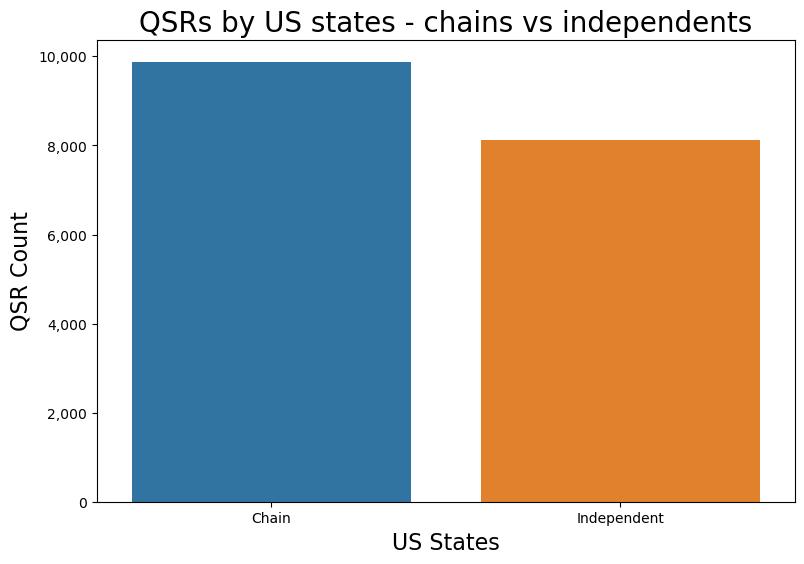

In [48]:
# Create a bar plot.
# Show the number of independents vs chains. 
# Set figure size.
plt.figure(figsize=(9, 6))

# Create a barplot.
ax = sns.countplot(x='BUSINESS_TYPE',  
                   data=business_type_state,
                   hue='BUSINESS_TYPE')

# Insert labels.
ax.set_title("QSRs by US states - chains vs independents", fontsize=20)
ax.set_xlabel("US States", fontsize=16)
ax.set_ylabel("QSR Count", fontsize=16)

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

# View the barplot.
plt.show()

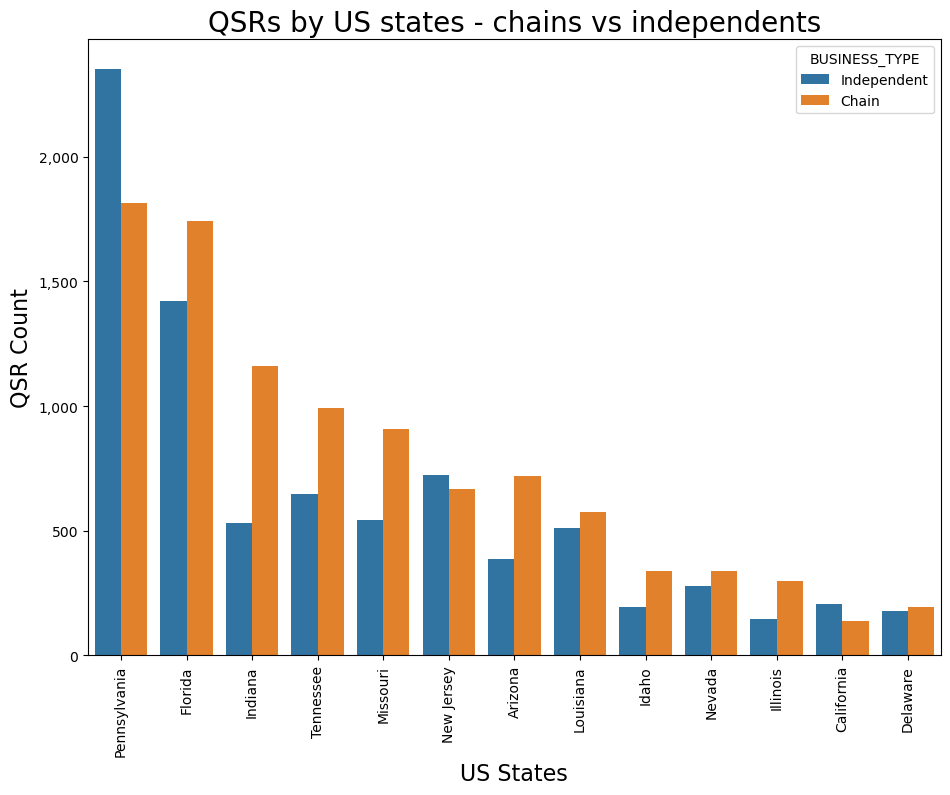

In [49]:
# Create a bar plot.
# Show the number of independents vs chains per state. 
# Set figure size.
plt.figure(figsize=(11, 8))

# Create a barplot.
ax = sns.barplot(x='BUSINESS_STATE_FULL_NAME', 
            y='COUNT', 
            data=sorted_business_type_by_state,
            hue='BUSINESS_TYPE')

# Rotate the labels.
plt.xticks(rotation=90)

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

# Insert labels.
ax.set_title("QSRs by US states - chains vs independents", fontsize=20)
ax.set_xlabel("US States", fontsize=16)
ax.set_ylabel("QSR Count", fontsize=16)

# View the barplot.
plt.show()

<h3 style="color:#475569;"> <i>Interpretation</i></h3>    

- The QSR market is generally dominated by chains: McDonald's, Yum! Brands, Domino's, Starbucks, and Restaurant Brands International are the five biggest players overall [(Mordor Intelligence, 2026)](https://www.mordorintelligence.com/industry-reports/quick-service-restaurants-market).
- In fact, from the provided data, we can see that the total number of chains outnumber the independent QSRs. However, there are regional differences, with Pennsylvania having more independents, than chains.
> *Limitation:* Whilst these insights provide a general overview of the market structure, it is important to remember that the data only represents Yelp reviews, QSRs not on Yelp have not been accounted for. Secondly, the data only includes dates up until January 2022. QSRs that entered the market after that date have not been included in this analysis.  

<h1 style="color:#0F766E;"><b> 2.3 <u>Review trends</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.3.1 Reviews from chains vs independents
</h1>

</div>


In [50]:
# Aggregate on monthly level and determine the count of reviews per month.
business_type_monthly_review = analytics.groupby(['REVIEW_DATE_MONTH', 'BUSINESS_TYPE'])['REVIEW_TEXT'] \
.count() \
.reset_index()

# View output.
print(business_type_monthly_review.head())

  REVIEW_DATE_MONTH BUSINESS_TYPE  REVIEW_TEXT
0           01/2018         Chain         5965
1           01/2018   Independent         7976
2           01/2019         Chain         6565
3           01/2019   Independent         9166
4           01/2020         Chain         5887


In [51]:
# Change review date into date time. 
business_type_monthly_review['REVIEW_DATE_MONTH'] = pd.to_datetime(business_type_monthly_review['REVIEW_DATE_MONTH'], format='%m/%Y')

# View output.
print(business_type_monthly_review.head())

  REVIEW_DATE_MONTH BUSINESS_TYPE  REVIEW_TEXT
0        2018-01-01         Chain         5965
1        2018-01-01   Independent         7976
2        2019-01-01         Chain         6565
3        2019-01-01   Independent         9166
4        2020-01-01         Chain         5887


In [52]:
# Sort the dates. 
business_type_monthly_review = business_type_monthly_review.sort_values(by='REVIEW_DATE_MONTH')

In [53]:
# Turn it back into a string to remove the day. 
business_type_monthly_review['REVIEW_DATE_MONTH'] = business_type_monthly_review['REVIEW_DATE_MONTH'].dt.strftime('%Y/%m')

# View output.
print(business_type_monthly_review.head())

   REVIEW_DATE_MONTH BUSINESS_TYPE  REVIEW_TEXT
0            2018/01         Chain         5965
1            2018/01   Independent         7976
11           2018/02   Independent         7861
10           2018/02         Chain         5892
18           2018/03         Chain         7044


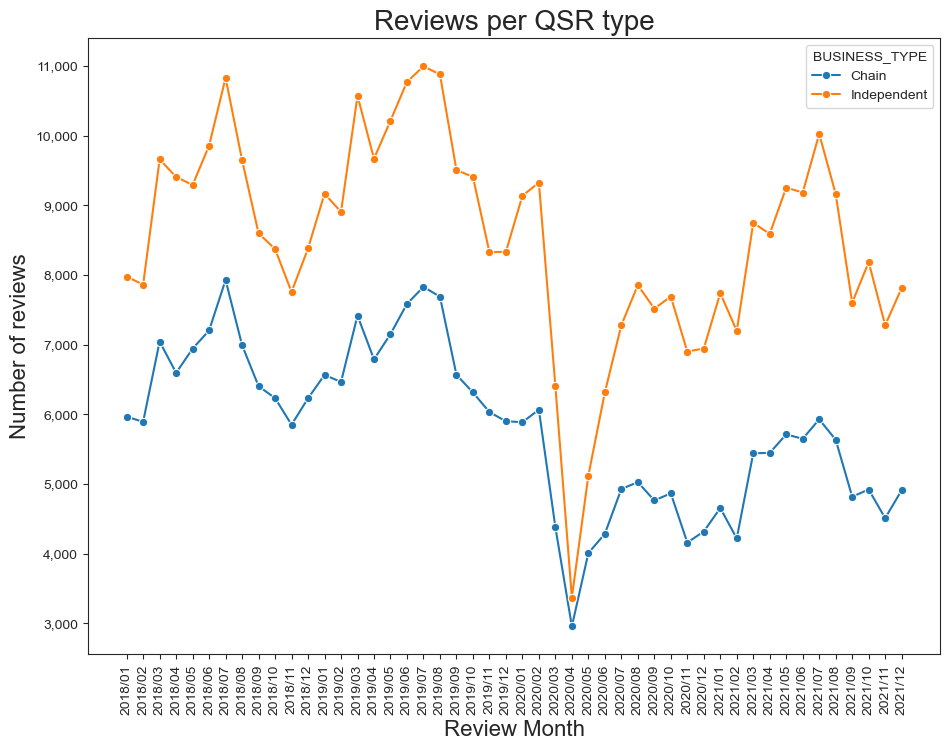

In [54]:
# Plot the reviews over the available date range, and review the business type for months.
# Include tick marks.
sns.set_style('ticks')

# Set figure size.
plt.figure(figsize=(11, 8))

# Create a lineplot.
ax = sns.lineplot(x='REVIEW_DATE_MONTH', 
                  y='REVIEW_TEXT', 
                  data=business_type_monthly_review.loc[business_type_monthly_review['REVIEW_DATE_MONTH'] != '2022/01'], 
                  hue='BUSINESS_TYPE', 
                  marker='o',
                  palette='tab10',
                  errorbar=None)

# Rotate the labels.
plt.xticks(rotation=90)

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

# Insert labels.
# Set the font size.
ax.set_title("Reviews per QSR type", fontsize=20)
ax.set_xlabel("Review Month", fontsize=16)
ax.set_ylabel("Number of reviews", fontsize=16)

# View output.
plt.show()

<h3 style="color:#475569;"> <i>Interpretation</i></h3>    

- Despite the fact that chains have a wider market coverage in the US, it is independents that receive the highest number of reviews on Yelp.
- This finding is unsurprising, considering that Yelp's tag line is 'Connect with great local businesses'.

<h1 style="color:#0F766E;"><b> 2.4 <u> QSR opening hours study</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.1 Opening hours
</h1>

</div>


In [55]:
# Create a new dataframe.
analytics_hours = analytics[['BUSINESS_ID', 'BUSINESS_NAME', 'BUSINESS_CITY', 
            'BUSINESS_STATE', 'BUSINESS_TYPE', 'BUSINESS_RATING', 
            'BUSINESS_ATTRIBUTES', 'BUSINESS_HOURS']].copy()

# View the output. 
analytics_hours.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_TYPE,BUSINESS_RATING,BUSINESS_ATTRIBUTES,BUSINESS_HOURS
0,G5kWtADcIMy5CgrjUerfnA,Chariot Pizza,Tucson,AZ,Chain,3.5,"{'WiFi': ""'free'"", 'RestaurantsTakeOut': 'True...","{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'..."
1,zupI44qitH6T8Bo9OjA6Yw,Bagelicious And More,Wesley Chapel,FL,Chain,3.5,"{'GoodForKids': 'True', 'BusinessParking': ""{'...","{'Monday': '6:0-15:0', 'Tuesday': '6:0-15:0', ..."
2,NgUst1ex3M2ibDzSb6Xkaw,Emmy Squared - Queen Village,Philadelphia,PA,Independent,4.0,"{'RestaurantsGoodForGroups': 'True', 'Business...","{'Monday': '0:0-0:0', 'Tuesday': '16:0-21:0', ..."
3,5yeL75bFLZlGB6dUfwCIQw,Cotoletta Fitler Square,Philadelphia,PA,Independent,4.0,"{'HasTV': 'True', 'HappyHour': 'True', 'Busine...","{'Monday': '17:0-21:0', 'Tuesday': '17:0-21:0'..."
4,zu1V7XhERCFA23srN_ro7g,Panera Bread,Wayne,PA,Chain,2.5,"{'Alcohol': ""u'none'"", 'BusinessAcceptsCreditC...","{'Monday': '7:0-21:0', 'Tuesday': '7:0-21:0', ..."


In [56]:
# View the shape. 
print(analytics_hours.shape) 

(696315, 8)


In [57]:
# Drop duplicates. 
analytics_hours.drop_duplicates(inplace=True) 
analytics_hours.reset_index(drop=True, inplace=True) 

# View output. 
analytics_hours.head(2)

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_TYPE,BUSINESS_RATING,BUSINESS_ATTRIBUTES,BUSINESS_HOURS
0,G5kWtADcIMy5CgrjUerfnA,Chariot Pizza,Tucson,AZ,Chain,3.5,"{'WiFi': ""'free'"", 'RestaurantsTakeOut': 'True...","{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'..."
1,zupI44qitH6T8Bo9OjA6Yw,Bagelicious And More,Wesley Chapel,FL,Chain,3.5,"{'GoodForKids': 'True', 'BusinessParking': ""{'...","{'Monday': '6:0-15:0', 'Tuesday': '6:0-15:0', ..."


In [58]:
# View the shape without duplicates
print(analytics_hours.shape) 

(18000, 8)


In [59]:
# View null values.
analytics_hours.isnull().sum()

BUSINESS_ID               0
BUSINESS_NAME             0
BUSINESS_CITY             0
BUSINESS_STATE            0
BUSINESS_TYPE             0
BUSINESS_RATING           0
BUSINESS_ATTRIBUTES     276
BUSINESS_HOURS         1765
dtype: int64

In [60]:
# Drop empty rows. 
analytics_hours = analytics_hours.dropna(subset=['BUSINESS_ATTRIBUTES', 'BUSINESS_HOURS']).reset_index(drop=True)

# View the shape. 
print(analytics_hours.shape) 

(16072, 8)


In [61]:
# View null values.
analytics_hours.isnull().sum()

BUSINESS_ID            0
BUSINESS_NAME          0
BUSINESS_CITY          0
BUSINESS_STATE         0
BUSINESS_TYPE          0
BUSINESS_RATING        0
BUSINESS_ATTRIBUTES    0
BUSINESS_HOURS         0
dtype: int64

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.2 Feature engineering
</h1>

</div>


<h3 style="color:#475569;"> <i>Number of weekly open days and the average daily opening hours</i></h3>   

In [62]:
# Extract the average daily opening hours.
# Extract the number of open days. 
daily_hours = analytics_hours['BUSINESS_HOURS'].str.findall(r"\d{1,2}:\d{1,2}\s*-\s*\d{1,2}:\d{1,2}")

# Create user-defined function. 
def calc_weekly_average(ranges):
    # Handle null values.
    if not isinstance(ranges, list) or len(ranges) == 0:
        return 0.0

    # Count the number of weekly open days. 
    days_logged = len(ranges)
    # Loop through the daily opening hours.
    total_hours = 0
    for item in ranges:
        start_str, end_str = item.split("-")

        # Turn opening hours into consistent formats. 
        # 8:0 becomes 08:00
        h_start, m_start = start_str.split(":")
        h_end, m_end = end_str.split(":")

        start_str = f"{int(h_start):02d}:{int(m_start):02d}"
        end_str = f"{int(h_end):02d}:{int(m_end):02d}"

        # Manage 24-hour opening hours.
        if start_str == end_str:
            total_hours += 24.0
            continue 

        # Create Pandas timedeltas.
        start_td = pd.to_timedelta(start_str + ":00")
        end_td = pd.to_timedelta(end_str + ":00")

        # Manage opening hours past midnight. 
        if end_td < start_td:
            duration = (end_td + pd.Timedelta(days=1)) - start_td
        else: 
            duration = end_td - start_td

        # Convert to numeric hours. 
        total_hours += duration.total_seconds() / 3600
    
    # Return the weekly average opening hours.
    avg_hours = round(total_hours/ days_logged, 2) if days_logged > 0 else 0.0
        
    return pd.Series([days_logged, avg_hours])

# Add the results to the hours DataFrame.
analytics_hours[["OPEN_DAYS", "AVG_DAILY_OPENING_HOURS"]] = daily_hours.apply(calc_weekly_average)

<h3 style="color:#475569;"> <i>Opening consistency</i></h3>   

In [63]:
# Calculate the opening hours consistency. 
def calc_opening_consistency(ranges):
    # Handle null values. 
    if not isinstance(ranges, list) or len (ranges) <= 1:
        return 0.0

    # Create an empty list.
    daily_durations = []

    # Turn opening hours into consistent formats. 
    # 8:0 becomes 08:00
    for item in ranges: 
        start_str, end_str = item.split("-")
        h_start, m_start = start_str.split(":")
        h_end, m_end = end_str.split(":")

        start_str = f"{int(h_start):02d}:{int(m_start):02d}"
        end_str = f"{int(h_end):02d}:{int(m_end):02d}"

        # Manage 24/7 opening hours. 
        if start_str == end_str:
            daily_durations.append(24.0)
            continue 
        
        # Create Pandas time deltas. 
        start_td = pd.to_timedelta(start_str + ":00")
        end_td = pd.to_timedelta(end_str + ":00")
        
        if end_td < start_td:
            duration = (end_td + pd.Timedelta(days=1)) - start_td
        else:
            duration = end_td - start_td
    
        daily_durations.append(duration.total_seconds() / 3600)
    
    # Calculate standard deviation if multiple days are logged. 
    return round(np.std(daily_durations, ddof=1), 2)

# Apply the results to the DataFrame.
analytics_hours["OPENING_CONSISTENCY"] = daily_hours.apply(calc_opening_consistency)

In [64]:
# View output. 
analytics_hours.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_TYPE,BUSINESS_RATING,BUSINESS_ATTRIBUTES,BUSINESS_HOURS,OPEN_DAYS,AVG_DAILY_OPENING_HOURS,OPENING_CONSISTENCY
0,G5kWtADcIMy5CgrjUerfnA,Chariot Pizza,Tucson,AZ,Chain,3.5,"{'WiFi': ""'free'"", 'RestaurantsTakeOut': 'True...","{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'...",7.0,12.29,0.49
1,zupI44qitH6T8Bo9OjA6Yw,Bagelicious And More,Wesley Chapel,FL,Chain,3.5,"{'GoodForKids': 'True', 'BusinessParking': ""{'...","{'Monday': '6:0-15:0', 'Tuesday': '6:0-15:0', ...",7.0,9.00,0.00
2,NgUst1ex3M2ibDzSb6Xkaw,Emmy Squared - Queen Village,Philadelphia,PA,Independent,4.0,"{'RestaurantsGoodForGroups': 'True', 'Business...","{'Monday': '0:0-0:0', 'Tuesday': '16:0-21:0', ...",7.0,9.14,6.87
3,5yeL75bFLZlGB6dUfwCIQw,Cotoletta Fitler Square,Philadelphia,PA,Independent,4.0,"{'HasTV': 'True', 'HappyHour': 'True', 'Busine...","{'Monday': '17:0-21:0', 'Tuesday': '17:0-21:0'...",7.0,4.29,0.49
4,zu1V7XhERCFA23srN_ro7g,Panera Bread,Wayne,PA,Chain,2.5,"{'Alcohol': ""u'none'"", 'BusinessAcceptsCreditC...","{'Monday': '7:0-21:0', 'Tuesday': '7:0-21:0', ...",7.0,14.00,0.00


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.3 Opening hours vs business rating
</h1>

</div>


In [65]:
# Invert the OPENING_CONSISTENCY for easier calculation.
# The consistency scale is 0-10
# OPENING_CONSISTENCY = 0 means the highest consistency, 10 means the lowest consistency. 
# INVERTED_HOUR_CONSISTENCY = 10 means the highest consistency, 0 means the lowest consistency.
analytics_hours["INVERTED_HOUR_CONSISTENCY"] = round(1 / (analytics_hours["OPENING_CONSISTENCY"] + 0.1), 2) 

In [66]:
# View the DataFrame. 
analytics_hours.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_TYPE,BUSINESS_RATING,BUSINESS_ATTRIBUTES,BUSINESS_HOURS,OPEN_DAYS,AVG_DAILY_OPENING_HOURS,OPENING_CONSISTENCY,INVERTED_HOUR_CONSISTENCY
0,G5kWtADcIMy5CgrjUerfnA,Chariot Pizza,Tucson,AZ,Chain,3.5,"{'WiFi': ""'free'"", 'RestaurantsTakeOut': 'True...","{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'...",7.0,12.29,0.49,1.69
1,zupI44qitH6T8Bo9OjA6Yw,Bagelicious And More,Wesley Chapel,FL,Chain,3.5,"{'GoodForKids': 'True', 'BusinessParking': ""{'...","{'Monday': '6:0-15:0', 'Tuesday': '6:0-15:0', ...",7.0,9.00,0.00,10.00
2,NgUst1ex3M2ibDzSb6Xkaw,Emmy Squared - Queen Village,Philadelphia,PA,Independent,4.0,"{'RestaurantsGoodForGroups': 'True', 'Business...","{'Monday': '0:0-0:0', 'Tuesday': '16:0-21:0', ...",7.0,9.14,6.87,0.14
3,5yeL75bFLZlGB6dUfwCIQw,Cotoletta Fitler Square,Philadelphia,PA,Independent,4.0,"{'HasTV': 'True', 'HappyHour': 'True', 'Busine...","{'Monday': '17:0-21:0', 'Tuesday': '17:0-21:0'...",7.0,4.29,0.49,1.69
4,zu1V7XhERCFA23srN_ro7g,Panera Bread,Wayne,PA,Chain,2.5,"{'Alcohol': ""u'none'"", 'BusinessAcceptsCreditC...","{'Monday': '7:0-21:0', 'Tuesday': '7:0-21:0', ...",7.0,14.00,0.00,10.00


In [67]:
# Measure the relationship between avg. daily opening hours 
# with the average star rating. 
correlation_matrix_hours = analytics_hours[['AVG_DAILY_OPENING_HOURS', 'OPEN_DAYS', 'INVERTED_HOUR_CONSISTENCY', 'BUSINESS_RATING', ]].corr()

Text(0.5, 1.0, 'Correlation Matrix')

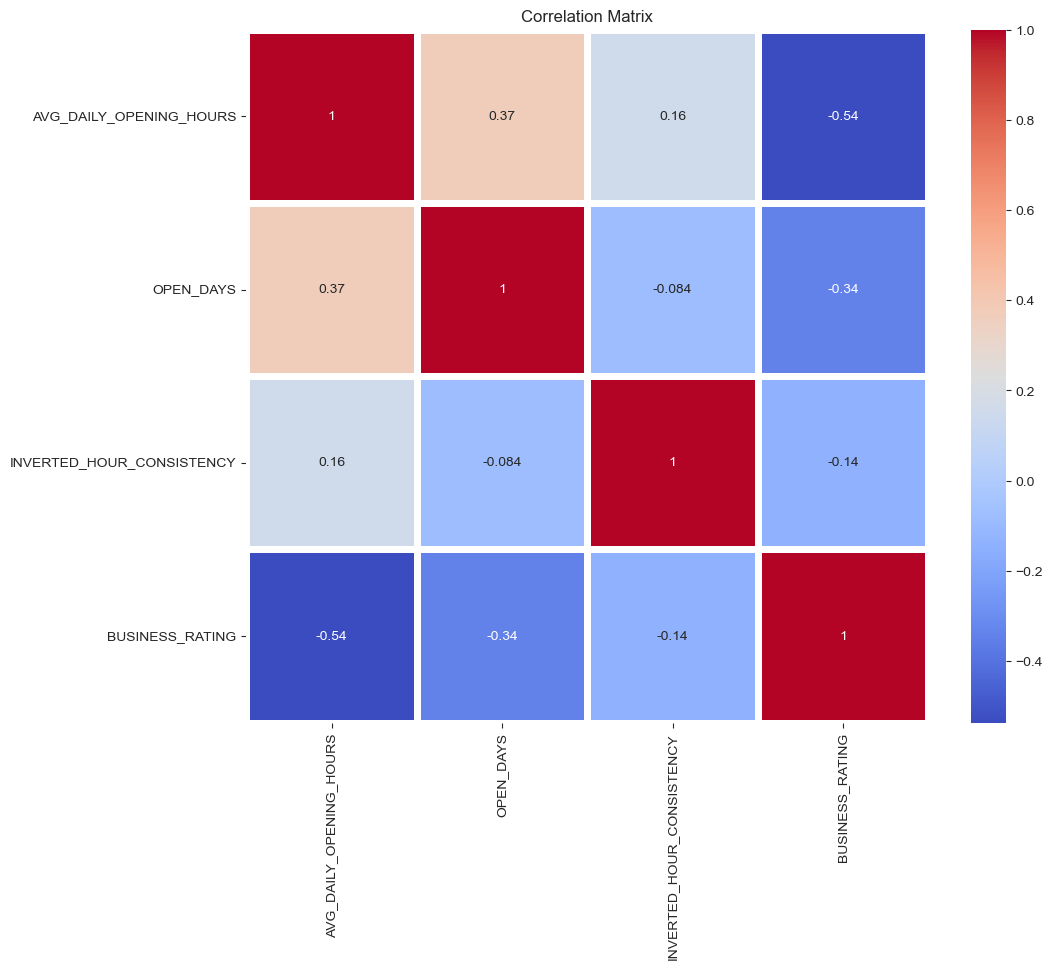

In [68]:
# Visualise the relationship.
plt.figure(figsize = (11,9))
sns.heatmap(correlation_matrix_hours, annot=True, cmap = 'coolwarm', linewidths = 5)
plt.title('Correlation Matrix')

<h3 style="color:#475569;"> <i> Interpretation</i></h3>  

- From the correlation matrix, we can see that longer opening hours and more open days have a negative impact on business ratings. Whilst this finding is surprising, it points to the possibility that QSRs operating under a 24/7 service model, fails at meeting service demands, and customer expectations. 
- In fact, other pieces of research have concluded similar outcomes. ResearchGate for example found that customer satisfaction was negatively affected by longer opening hours and more opening days, although the relationship is complex. 
- However, it is widely recognised within the QSR industry that consistency is a key driver behind performance. This includes consistent opening hours, that align with what's written on restaurant websites [(Revenue Management Solutions, 2026)](https://www.revenuemanage.com/blog/how-restaurant-hours-data-drives-profits/). For that reason, we will include the 'Opening Consistency' variable as part of the Location Health Index. 

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.5 Average daily opening hours
</h1>

</div>


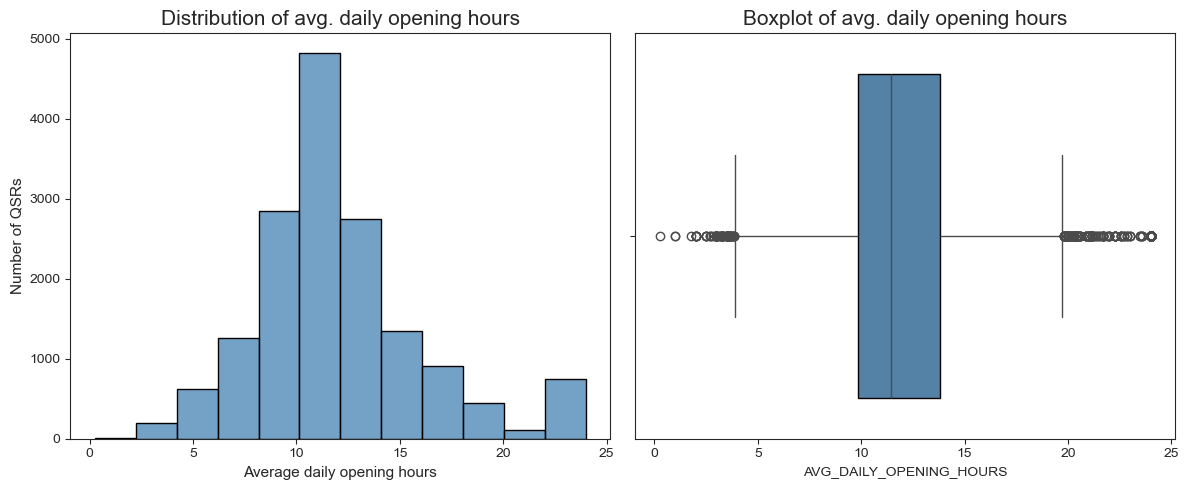

In [69]:
# Create a figure.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Create a histogram.
sns.histplot(data=analytics_hours, x='AVG_DAILY_OPENING_HOURS', binwidth=2, 
            color='steelblue', edgecolor='black', ax=ax1)

ax1.set_title("Distribution of avg. daily opening hours", fontsize=15)
ax1.set_xlabel("Average daily opening hours", fontsize=11)
ax1.set_ylabel("Number of QSRs", fontsize=11)

# Create a boxplot.
sns.boxplot(x=analytics_hours['AVG_DAILY_OPENING_HOURS'], 
            color='steelblue', 
            boxprops=dict(edgecolor="black"),
            ax=ax2)
ax2.set_title("Boxplot of avg. daily opening hours", fontsize=15)

# View output.
plt.tight_layout()
plt.show()

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.6 Weekly open days
</h1>

</div>


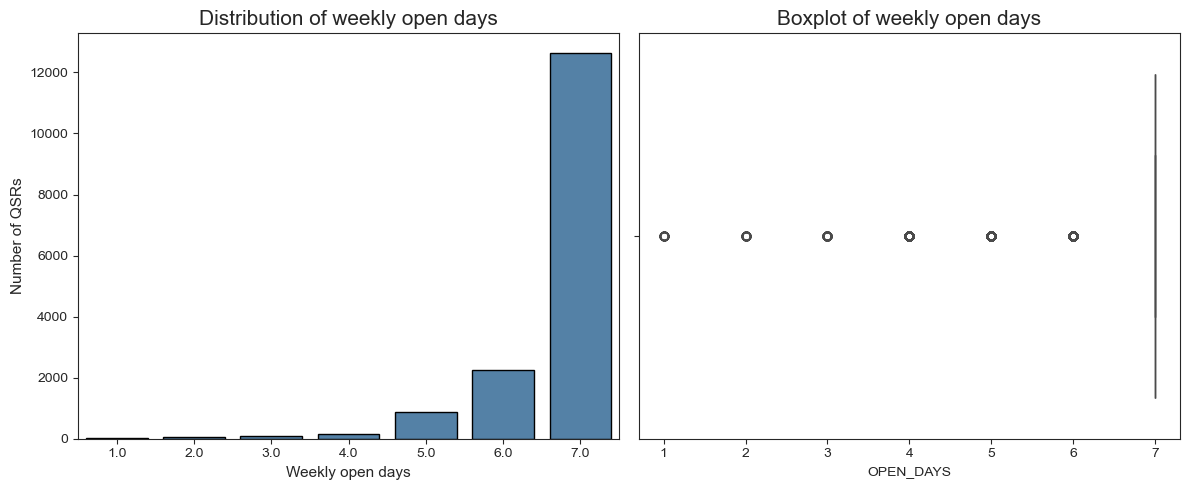

In [70]:
# Create a figure.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Create a countplot.
sns.countplot(data=analytics_hours, x='OPEN_DAYS', color='steelblue', edgecolor='black', ax=ax1)

ax1.set_title("Distribution of weekly open days", fontsize=15)
ax1.set_xlabel("Weekly open days", fontsize=11)
ax1.set_ylabel("Number of QSRs", fontsize=11)

# Create a boxplot.
sns.boxplot(x=analytics_hours['OPEN_DAYS'], 
            color='steelblue', 
            boxprops=dict(edgecolor="black"),
            ax=ax2)
ax2.set_title("Boxplot of weekly open days", fontsize=15)

# View output.
plt.tight_layout()
plt.show()

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.7 Daily opening consistency
</h1>

</div>


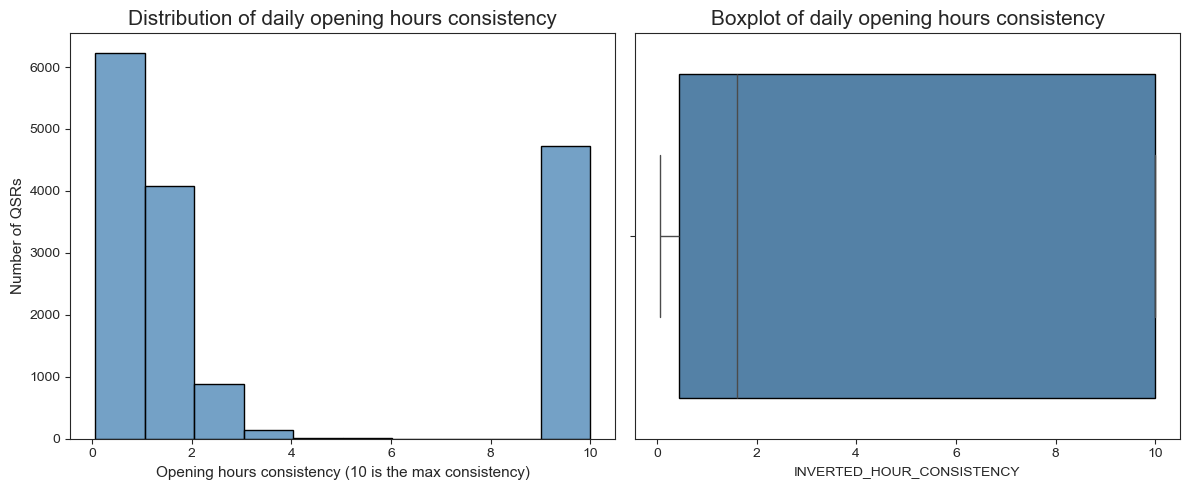

In [71]:
# Create a figure.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Create a countplot.
sns.histplot(data=analytics_hours, x='INVERTED_HOUR_CONSISTENCY', 
             binwidth=1, color='steelblue', 
             edgecolor='black', ax=ax1)

ax1.set_title("Distribution of daily opening hours consistency", fontsize=15)
ax1.set_xlabel("Opening hours consistency (10 is the max consistency)", fontsize=11)
ax1.set_ylabel("Number of QSRs", fontsize=11)

# Create a boxplot.
sns.boxplot(x=analytics_hours['INVERTED_HOUR_CONSISTENCY'], 
            color='steelblue', 
            boxprops=dict(edgecolor="black"),
            ax=ax2)
ax2.set_title("Boxplot of daily opening hours consistency", fontsize=15)

# View output.
plt.tight_layout()
plt.show()

In [72]:
# Check the statistics.
analytics_hours.describe()

,BUSINESS_RATING,OPEN_DAYS,AVG_DAILY_OPENING_HOURS,OPENING_CONSISTENCY,INVERTED_HOUR_CONSISTENCY
count,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000
mean,3.352476,6.677576,12.094107,1.641783,3.646694
std,0.987767,0.749969,4.119457,2.224641,4.150346
min,1.000000,1.000000,0.250000,0.000000,0.060000
25%,2.500000,7.000000,9.830000,0.000000,0.450000
50%,3.500000,7.000000,11.430000,0.520000,1.610000
75%,4.000000,7.000000,13.790000,2.130000,10.000000
max,5.000000,7.000000,24.000000,16.260000,10.000000


In [73]:
# Subset the DataFrame.
# Look at businesses that are open 24/7. 
analytics_hours[analytics_hours['AVG_DAILY_OPENING_HOURS'] == 24].head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_TYPE,BUSINESS_RATING,BUSINESS_ATTRIBUTES,BUSINESS_HOURS,OPEN_DAYS,AVG_DAILY_OPENING_HOURS,OPENING_CONSISTENCY,INVERTED_HOUR_CONSISTENCY
24,UxPNpzKEC4FpdidHz8MCcA,Mcdonald's,New Orleans,LA,Chain,2.5,"{'GoodForKids': 'True', 'BusinessParking': ""{'...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
31,kPy6jsVWuMREMRWRGTvEyw,Dunkin',Brandon,FL,Chain,3.0,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
44,29fX9PdevQa5LZavVDJsbw,Roberto's Taco Shop,Reno,NV,Chain,3.0,"{'RestaurantsAttire': ""'casual'"", 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
82,IZwgCD5U2izKWc5gBH6PAg,Steak 'n Shake,Indianapolis,IN,Chain,2.0,"{'RestaurantsTakeOut': 'True', 'RestaurantsGoo...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
147,sbYgnao47_vMVqZCYF59Dw,White Castle,Indianapolis,IN,Chain,4.5,"{'RestaurantsPriceRange2': '1', 'RestaurantsAt...","{'Monday': '5:0-5:0', 'Tuesday': '5:0-5:0', 'W...",7.0,24.0,0.0,10.0


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

- Majority of the QSR businesses are open 7 days a week, with an average daily opening of 12 hours.
- 50% of the businesses operate with inconsistent opening hours, at an average consistency score of 3.65 (0 = least inconsistent, 10 = most consistent).  

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.8 Multi Linear regression
</h1>

</div>


<h3 style="color:#475569;"> <i> Opening hours vs business rating</i></h3>   

In [74]:
# Define the dependent variable.
y = analytics_hours['BUSINESS_RATING']  

# Define the independent variable.
X = analytics_hours[['OPEN_DAYS', 'AVG_DAILY_OPENING_HOURS', 'INVERTED_HOUR_CONSISTENCY']] 

In [75]:
# Split the data in 'train' (80%) and 'test' (20%) sets.
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, y,
                                                                            test_size = 0.20,
                                                                            random_state = 5)

In [76]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(Y_train, sm.add_constant(X_train)).fit()

# Set the predicted response vector.
# X_test used to avoid overfitting - we want the model to learn, not memorise. 
Y_pred_2 = model.predict(sm.add_constant(X_test)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model) 

                            OLS Regression Results                            
Dep. Variable:        BUSINESS_RATING   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     2025.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:24:11   Log-Likelihood:                -15599.
No. Observations:               12857   AIC:                         3.121e+04
Df Residuals:                   12853   BIC:                         3.124e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

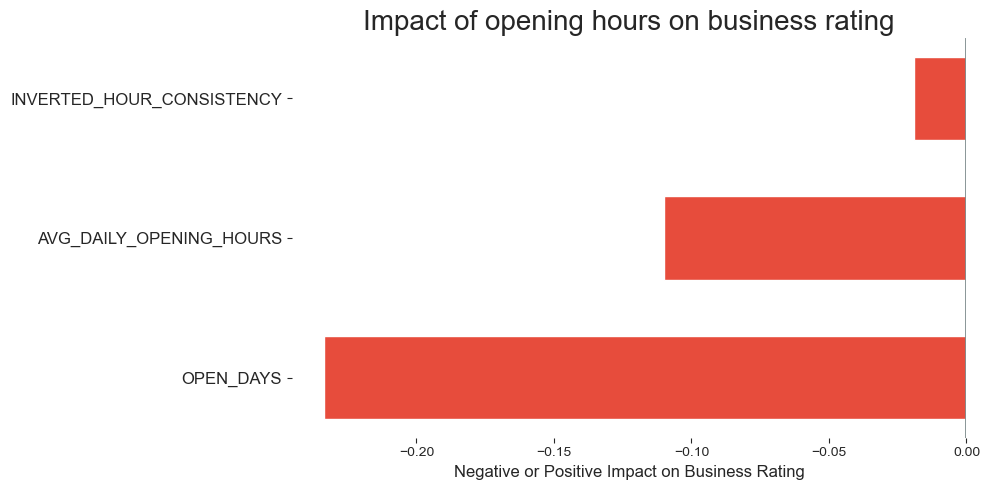

In [77]:
# Get the coefficients from the model. 
coefs = model.params.drop("const").sort_values()

# Add blue for positive, red for negative. 
colors = ["#3498db" if x >= 0 else "#e74c3c" for x in coefs]

# Create the barchart.
plt.figure(figsize=(10, 5))
plt.barh(coefs.index, coefs.values, color=colors, height=0.6)

# Add baseline and grid lines. 
plt.axvline(x=0, color="#7f8c8d", linewidth=2)
plt.grid(False)

# Insert labels.
# Set the font size.
plt.title("Impact of opening hours on business rating", fontsize=20)
plt.xlabel("Negative or Positive Impact on Business Rating", fontsize=12)
plt.yticks(fontsize=12)

# Show the plot. 
plt.box(False) 
plt.tight_layout()
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

- As was found in the corralation matrix, the multi linear regression model shows that as the average daily opening hours increase, the business rating decreases. The same is true for the number of open days.
- Let's take a closer look at businesses that operat with the 24/7 service model. 

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.9 Profiling of the 24/7 service model
</h1>

</div>


In [78]:
# Filter to show QSRs that are open 24/7.
filtered_hours = analytics_hours[(analytics_hours['OPEN_DAYS']==7) & (analytics_hours['AVG_DAILY_OPENING_HOURS']==24)].reset_index(drop=True) 

# View output. 
print(filtered_hours.shape) 
filtered_hours.head()

(699, 12)


,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_STATE,BUSINESS_TYPE,BUSINESS_RATING,BUSINESS_ATTRIBUTES,BUSINESS_HOURS,OPEN_DAYS,AVG_DAILY_OPENING_HOURS,OPENING_CONSISTENCY,INVERTED_HOUR_CONSISTENCY
0,UxPNpzKEC4FpdidHz8MCcA,Mcdonald's,New Orleans,LA,Chain,2.5,"{'GoodForKids': 'True', 'BusinessParking': ""{'...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
1,kPy6jsVWuMREMRWRGTvEyw,Dunkin',Brandon,FL,Chain,3.0,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
2,29fX9PdevQa5LZavVDJsbw,Roberto's Taco Shop,Reno,NV,Chain,3.0,"{'RestaurantsAttire': ""'casual'"", 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
3,IZwgCD5U2izKWc5gBH6PAg,Steak 'n Shake,Indianapolis,IN,Chain,2.0,"{'RestaurantsTakeOut': 'True', 'RestaurantsGoo...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",7.0,24.0,0.0,10.0
4,sbYgnao47_vMVqZCYF59Dw,White Castle,Indianapolis,IN,Chain,4.5,"{'RestaurantsPriceRange2': '1', 'RestaurantsAt...","{'Monday': '5:0-5:0', 'Tuesday': '5:0-5:0', 'W...",7.0,24.0,0.0,10.0


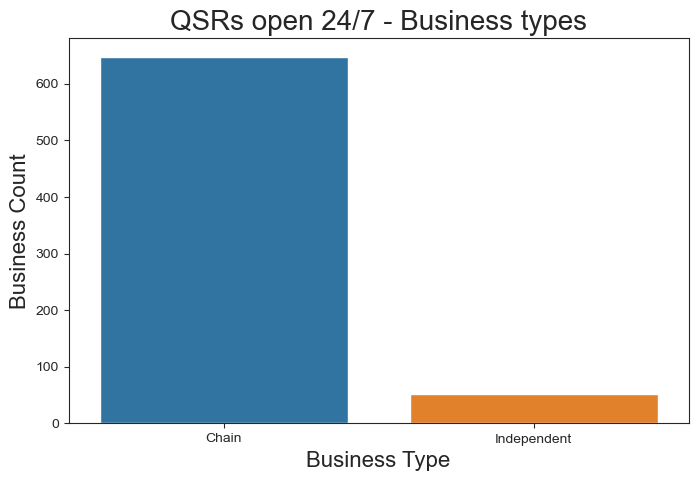

In [79]:
# Create a countplot.
# Profile businesses that are open 24/7.
# Show business type. 
# Set figure size.
plt.figure(figsize=(8, 5))

# Create a countplot.
ax = sns.countplot(data=filtered_hours,
                  x='BUSINESS_TYPE',
                  hue='BUSINESS_TYPE')

# Insert labels.
ax.set_title("QSRs open 24/7 - Business types", fontsize=20)
ax.set_xlabel("Business Type", fontsize=16)
ax.set_ylabel("Business Count", fontsize=16)

# View the barplot.
plt.show()

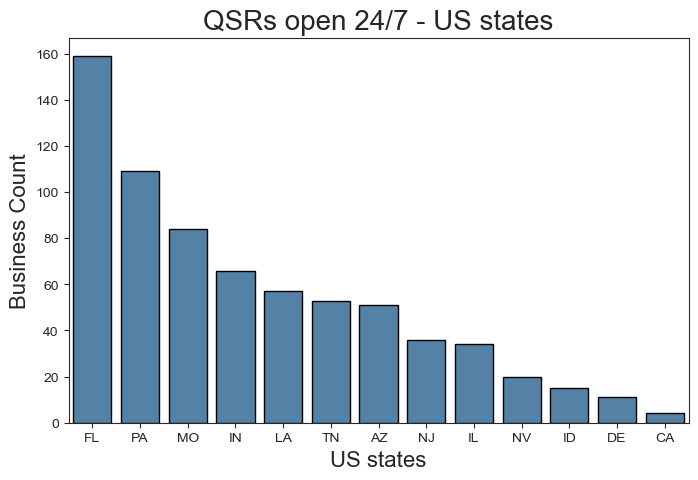

In [80]:
# Create a countplot.
# Profile businesses that are open 24/7.
# Show state. 
# Set figure size.
plt.figure(figsize=(8, 5))

# Arrange categories in order. 
ranked = filtered_hours['BUSINESS_STATE'].value_counts().index

# Create a countplot.
ax = sns.countplot(data=filtered_hours,
                  x='BUSINESS_STATE',color='steelblue',
                   edgecolor='black',
                   order=ranked)

# Insert labels.
ax.set_title("QSRs open 24/7 - US states", fontsize=20)
ax.set_xlabel("US states", fontsize=16)
ax.set_ylabel("Business Count", fontsize=16)

# View the barplot.
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

- An overwhelming majority of the QSRs that operate with the 24/7 service model are chains.
- Florida has the largest number of 24/7 QSRs, which could be due to the vibrant nightlife culture, creating demand for late-night food services. 

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
2.4.10 Write the dataframe back to Snowflake
</h1>

</div>


In [81]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_BUSINESS_OPE_HOURS
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    analytics_hours,
    table_name="QSR_BUSINESS_OPE_HOURS",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  16072


---

<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Summary of findings</u>
</h3>

<p>

 - **Relevant attributes:** The analysis found 10 operational attributes that positively impact customer sentiment, with **table service and caters** having the strongest positive impact on review ratings.
 - Flags were created (0=no, 1=yes) to indicate which operational attributes are offered by each QSR location. Health scores will be assigned for each attribute offered.
 - **Opening hours:** Interestingly, the regression analysis found a **negative relationship between opening hours and business rating**. Our hypothesis is that QSRs that offer longer hours, struggle to meet customer service expectations. This insight will be relayed back to the stakeholders for their consideration. 
 - The opening consistency was calculated per week; since **consistency is a key driver behind QSR performance**, we will award higher scores to QSRs that have a higher opening consistency. 

</p>

</li>

</ol>

</div>

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
3. REPUTATION LEVEL
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
    
Since the reputation of a QSR heavily **influences customer trust** and customer sentiment, this section explores two reputation signals: 

- Average star rating.
- Rating distribution (variance/ stability). 

This section primarily focuses on calculating for each location the average star rating between 2018 and 2022 (i.e. the chose time frame). Additionally, the rating distribution for each QSR will be derived using **standard deviation calculations**. 
</p>

</li>

</ol>

</div>

---

<h1 style="color:#0F766E;"><b> 3.1 <u>Average star rating</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
3.1.1 QSR star rating exploration
</h1>

</div>


<h3 style="color:#475569;"> <i>Business Rating & Review Rating Distribution</i></h3>

In [82]:
# Custom star-rating labels for x-axis display
plt.rcParams['font.family'] = 'DejaVu Sans' 
star_labels = ['★----\n1', '★★---\n2', '★★★--\n3', '★★★★-\n4', '★★★★★\n5']

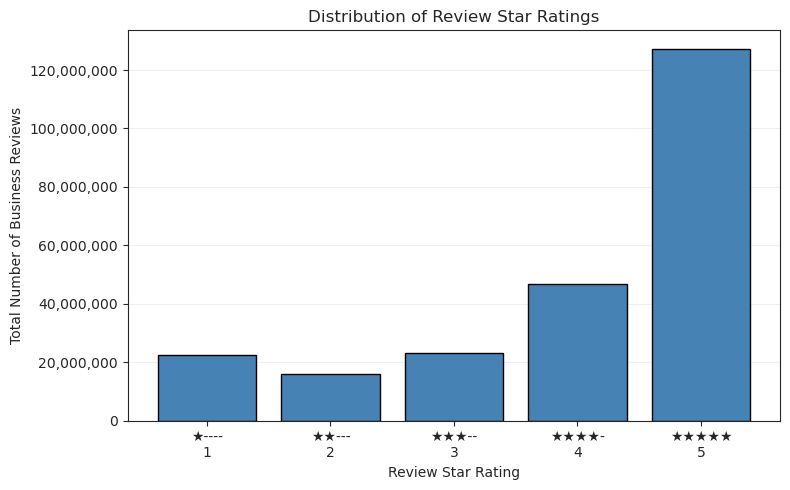

In [83]:
# Star Ratings Plot
plt.clf()
plt.close('all')
plt.figure(figsize=(8, 5))
plt.hist(analytics['REVIEW_STARS'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         # Include weight to account for the 'Review Count' column 
         weights=analytics["BUSINESS_REVIEW_COUNT"],
         edgecolor='black', color='steelblue', rwidth=0.8)

# Format
plt.title('Distribution of Review Star Ratings')
plt.xlabel('Review Star Rating')
plt.ylabel('Total Number of Business Reviews')
plt.xticks([1, 2, 3, 4, 5], star_labels)
# --------------------------------------
plt.ticklabel_format(style='plain', axis='y')      # Disable scientific notation on the y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))  #Add commas to make large numbers readable
# --------------------------------------
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

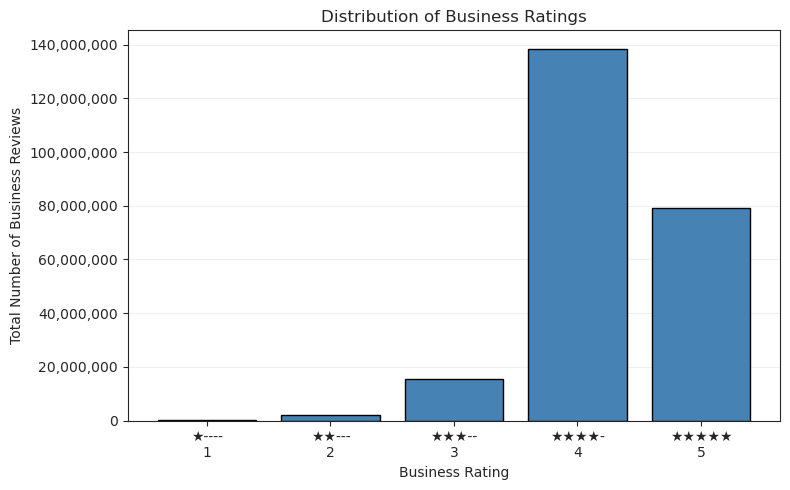

In [84]:
# Business Rating Plot
plt.clf()
plt.close('all')
plt.figure(figsize=(8, 5))
plt.hist(analytics['BUSINESS_RATING'], 
         bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         # Include weight to account for the 'Review Count' column 
         weights=analytics["BUSINESS_REVIEW_COUNT"],
         edgecolor='black', color='steelblue', rwidth=0.8)

# Format 
plt.title('Distribution of Business Ratings')
plt.xlabel('Business Rating')
plt.ylabel('Total Number of Business Reviews')
plt.xticks([1, 2, 3, 4, 5], star_labels)
# --------------------------------------
plt.ticklabel_format(style='plain', axis='y')      # Disable scientific notation on the y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))  #Add commas to make large numbers readable
# --------------------------------------
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h3 style="color:#475569;"> <i>Key finding</i></h3>

The distribution of QSR business ratings is concentrated primarily around 4 stars, indicating that most QSR locations higher-rated businesses are more common across the sampled QSR locations. 

Nevertheless, the distribution of stars is a lot different for 'Business Rating' vs 'Star Rating' which implies that business rating may have the Yelp algorithm applied to it but not 'Stars'. <br>
Good point is that it follows the same trends as Yelp's report here: https://www.yelp-press.com/company/fast-facts/default.aspx



<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
3.1.2 Average star rating
</h1>

</div>


We calculate the "AVERAGE_STAR_RATING" by averaging the star rating from the last 4 years (2018-2022)
and display "BUSINESS_RATING" = official Yelp business rating already stored in dataset for comparison

In [85]:
# Calculation details
av_star_rate = (
    analytics
    .groupby("BUSINESS_ID")
    .agg(
        AVERAGE_STAR_RATING=("REVIEW_STARS", "mean"),
        YELP_BUSINESS_RATING=("BUSINESS_RATING", "first")
    )
    .reset_index()
)

In [86]:
# Comparison
av_star_rate.head()

,BUSINESS_ID,AVERAGE_STAR_RATING,YELP_BUSINESS_RATING
0,---kPU91CF4Lq2-WlRu9Lw,4.500000,4.5
1,--0iUa4sNDFiZFrAdIWhZQ,5.000000,3.0
2,--epgcb7xHGuJ-4PUeSLAw,2.529412,3.0
3,--hF_3v1JmU9nlu4zfXJ8Q,4.733333,4.5
4,--lqIzK-ZVTtgwiQM63XgQ,2.090909,2.0


In [188]:
data_valid(av_star_rate)


Missing Values (per column):
BUSINESS_ID             0
AVERAGE_STAR_RATING     0
YELP_BUSINESS_RATING    0
dtype: int64

Unique Values (per column):
BUSINESS_ID             18000
AVERAGE_STAR_RATING      4203
YELP_BUSINESS_RATING        9
dtype: int64

Duplicate Rows in DataFrame:
0

Record Counts in DataFrame:
18000

Descriptive Statstics in DataFrame:
       AVERAGE_STAR_RATING  YELP_BUSINESS_RATING
count         18000.000000          18000.000000
mean              3.279417              3.356167
std               1.092675              0.986326
min               1.000000              1.000000
25%               2.400000              2.500000
50%               3.500000              3.500000
75%               4.200000              4.000000
max               5.000000              5.000000

Data Types in DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------      

<h3 style="color:#475569;"> <i>Key finding</i></h3>
We will keep "AVERAGE_STAR_RATING" from the last 4 years (2018-2022), to get an up-to-date view on the restaurant performances 
<br>(whereas the business rating is the average from all reviews since the restaurant joined Yelp).

<h1 style="color:#0F766E;"><b> 3.2 <u>Rating distribution (variance/stability)</b></u></h2>

In [206]:
# Calculates the standard deviation within ratings per QSR outlet/business id
# Creating a function
def compute_std_rating(df):

    rating_dist = (
        df.groupby(['BUSINESS_ID', 'BUSINESS_NAME'])
        .agg(
            STANDARD_DEVIATION=('REVIEW_STARS', 'std'),
            AVERAGE_STAR_RATING=('REVIEW_STARS', 'mean'),
            REVIEW_COUNT=('REVIEW_STARS', 'count')
        )
        .reset_index()
    )

    # Exclude businesses with only one review
    rating_dist = rating_dist[rating_dist['REVIEW_COUNT'] > 1]

    # Flag businesses with highly inconsistent ratings (Review count >=5)
    rating_dist['HIGH_VARIABILITY_FLAG'] = (
        (rating_dist['STANDARD_DEVIATION'] > 1.5)
        & (rating_dist['REVIEW_COUNT'] >= 5)
    )

    rating_dist['VARIABILITY_SCORE'] = np.where(
    (rating_dist['STANDARD_DEVIATION'] > 1.5)
    & (rating_dist['REVIEW_COUNT'] >= 5),
    0,   # penalty
    1    # consistent
    )

    # Sort by standard deviation
    rating_dist = rating_dist.sort_values(
        'STANDARD_DEVIATION',
        ascending=False
    )

    return rating_dist


In [207]:
# Calling the function and printing results
reputation_level = compute_std_rating(analytics)
reputation_level

,BUSINESS_ID,BUSINESS_NAME,STANDARD_DEVIATION,AVERAGE_STAR_RATING,REVIEW_COUNT,HIGH_VARIABILITY_FLAG,VARIABILITY_SCORE
9858,YMqvj4O6VGoisSgzORw-dg,Jalapeno's,2.828427,3.0,2,False,1
13574,kAlsU3rDJ7vYMp8Ky28-vQ,Rita's Italian Ice,2.828427,3.0,2,False,1
17732,z5HXbl8oiPAwp4vKhMqArg,Dunkin',2.828427,3.0,2,False,1
5698,JXqEKTVHCobDn1TIwQFnuA,Broad Street Snowballs,2.828427,3.0,2,False,1
8244,SigV0gKn7atQiBX7_IJhrg,Luigi's Pizza City,2.828427,3.0,2,False,1
...,...,...,...,...,...,...,...
1888,5_5X7seqU-GXpcbc1qvv2A,The Bakers At Red Lion,0.000000,5.0,6,False,1
15345,qaEqiGzQ67ief_yoKP97Hw,Mcdonald's,0.000000,1.0,12,False,1
7415,Plgm7jeRg8xbrku_tDitEw,Wudon K Bowl,0.000000,5.0,5,False,1
10611,a2Ts7eOdnK8PyHk8ott8Ng,Pizza Hut,0.000000,1.0,15,False,1


In [208]:
# Checking why some have 0 for std. Same rating?
analytics[analytics['BUSINESS_ID'] == 'yDriUh65Wpx1HnTmXln9nw'][[
    'REVIEW_STARS',
    'REVIEW_TEXT',
    'REVIEW_DATE']]


,REVIEW_STARS,REVIEW_TEXT,REVIEW_DATE


In [209]:
# Checking why some have 0 for std. Same rating?
analytics[analytics['BUSINESS_ID'] == 'RvV-egTT16QOsKw7DEu2NA'][[
    'REVIEW_STARS',
    'REVIEW_TEXT',
    'REVIEW_DATE']]


,REVIEW_STARS,REVIEW_TEXT,REVIEW_DATE
70321,1.0,"Terrible, Service and Concern for Customer's H...",2020-04-21
81880,1.0,This place has zero customer service. The empl...,2018-03-05
188984,1.0,"9:15 in the morning, I ordered the Midnight......",2021-12-09
191831,1.0,If I could give less than one star I would. Th...,2018-05-28
260479,1.0,See last few sentences for the update \nTerrib...,2020-04-23
433041,1.0,"horrible service, woman at the front shorted m...",2021-10-01
435901,1.0,"At this point in my life, I've probably visite...",2021-03-08


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

The QSRs with 0 std have the same star rating in each review

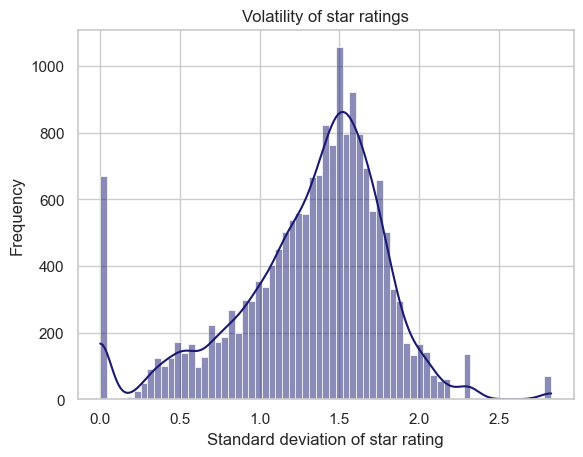

In [210]:
# Visualising the distribution of star rating variance
# Histogram
rating_dist = compute_std_rating(analytics)
plt.clf()
plt.close('all')
sns.histplot(data=rating_dist, x='STANDARD_DEVIATION', kde=True, color='midnightblue')

plt.title('Volatility of star ratings')
plt.xlabel('Standard deviation of star rating')
plt.ylabel('Frequency')
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

- Most QSR restaurants have moderately inconsistent reviews, with the majority having a std deviation around 1.5
- There are also 750 QSRs that have the same review (std 0), but these may have fewer reviews.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
3.2.1 Write the dataframe back to Snowflake
</h1>

</div>


In [211]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_BUSINESS_REPUTATION
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    reputation_level,
    table_name="QSR_BUSINESS_REPUTATION",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  17784


---

<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Summary of findings</u>
</h3>

<p>

 - For each QSR location, the **average Yelp star rating** for the last 4 years (2018-2022) was calculated to get an updated view on performance. In the Location Health scorecard, higher scores will be awarded to higher star ratings.
 - The **rating distribution**, calculated using standard deviation, showed that the majority of the population QSRs have inconsistent reviews, with a standard variation of around 1.5.
 - Lower scores will be given to those QSRs with a standard deviation of 1.5, and above, with the rational that **a large variation in star ratings points to inconsistent service levels**. Failing at providing consistent, positive service experiences can have catastophic consequences; especially considering that 51% of customers that had a negative experience will never return to that business [(QSR, 2024)](https://www.qsrmagazine.com/sponsored_content/what-all-successful-restaurants-have-in-common/). 

</p>

</li>

</ol>

</div>

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
4. REVIEW ENGAGEMENT
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
This section evaluates the review engagement and momentum for each QSR location, focusing on two engagement signals: 

- **Review volume**: Aggregated using the Business ID to calculate the total number of reviews between January 2018 and January 2022. 
- **Rating trends over time (improving or declining):** Evaluates whether the monthly review ratings have improved or dropped over the last 6-month period. This was done using a trend slope, with a negative trend number indicating that reviews ratings have dropped, whereas a positive number indicates an uplift in monthly review ratings. 


</p>

</li>

</ol>

</div>

---

<h1 style="color:#0F766E;"><b> 4.1 <u>Review volume</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
4.1.1 Review volume distribution
</h1>

</div>


In [94]:
# Review volume by total QSR
# Creating a function
def review_volume(df):
    review_counts = (
        df.groupby(['BUSINESS_ID', 'BUSINESS_NAME'])
          .agg(REVIEW_COUNT_PERIOD=('REVIEW_ID', 'count')).reset_index())
    return review_counts

In [95]:
# Calling the function and printing results
review_volume(analytics)


,BUSINESS_ID,BUSINESS_NAME,REVIEW_COUNT_PERIOD
0,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,24
1,--0iUa4sNDFiZFrAdIWhZQ,Pupuseria Y Restaurant Melba,1
2,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,17
3,--hF_3v1JmU9nlu4zfXJ8Q,Green District Salads - Monument Circle,15
4,--lqIzK-ZVTtgwiQM63XgQ,Wendy's,11
...,...,...,...
17995,zxRmQ_FWVowh8rlzLCSURQ,Verree Express Pizza,13
17996,zxqCNze-DDqEZIYrEMJLxg,Anthony's Deli Warehouse,19
17997,zz0l4dUf28wzPAaTdGqsSw,El Pique - Wilmington,76
17998,zzIF9qp2UoHN48EeZH_IDg,Domino's Pizza,8


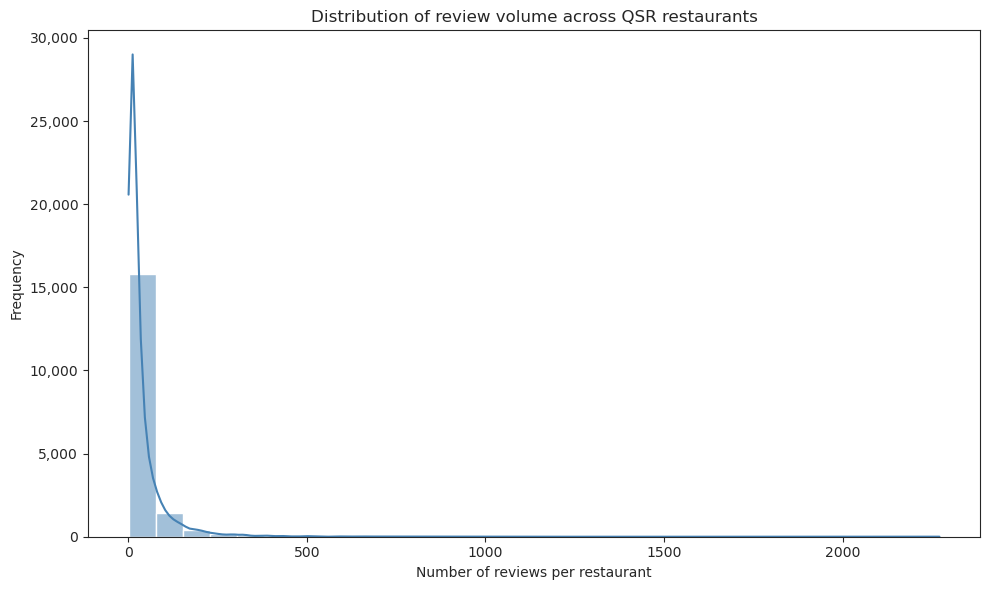

In [96]:
# Visualising the distribution of review volume
# Histogram
review_vol = review_volume(analytics)

plt.figure(figsize=(10,6))
sns.histplot(
    data=review_vol,
    x='REVIEW_COUNT_PERIOD',
    kde=True,
    bins=30,
    color='steelblue')

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

plt.title('Distribution of review volume across QSR restaurants')
plt.xlabel('Number of reviews per restaurant')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

- Some restaurants have a large number of reviews, exceeding 2,000, these will be the chains.
- There is a heavy right skew and a long tail

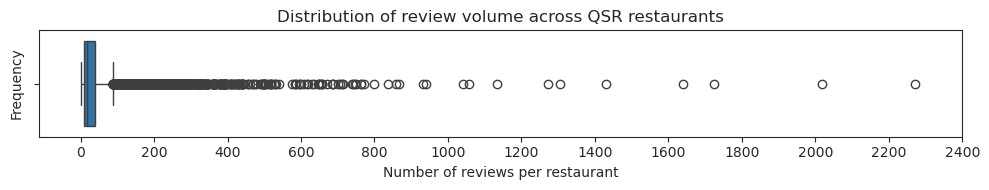

In [97]:
plt.figure(figsize=(10, 2))

sns.boxplot(data=review_vol,x='REVIEW_COUNT_PERIOD')
# Increase number of x-axis ticks
# Set ticks every 50 reviews
plt.xticks(np.arange(0, review_vol['REVIEW_COUNT_PERIOD'].max() + 200, 200))
plt.title('Review count distribution')
# labels

plt.title('Distribution of review volume across QSR restaurants')
plt.xlabel('Number of reviews per restaurant')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

The boxplot shows that the majority of QSRs have between 0 and 50 reviews

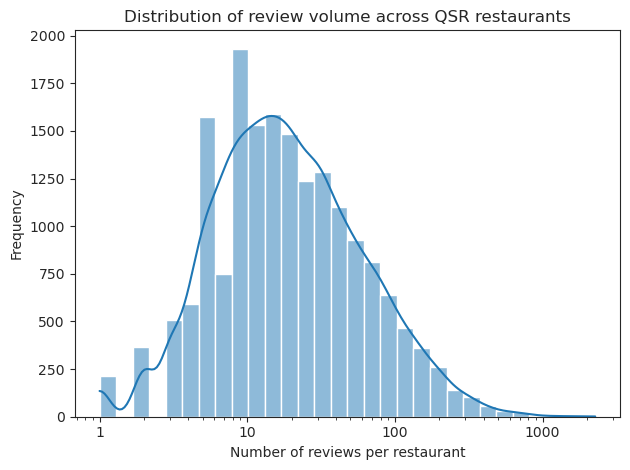

In [98]:
# Visualising using log scale to see the trends for reviews below 200

ax = sns.histplot(
    data=review_vol,
    x='REVIEW_COUNT_PERIOD',
    bins=30,
    kde=True,
    log_scale=True)

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
# Major + minor ticks
ax.xaxis.set_major_locator(ticker.LogLocator(base=10))
ax.xaxis.set_minor_locator(
    ticker.LogLocator(base=10, subs=[2,3,4,5,6,7,8,9]))

plt.title('Distribution of review volume across QSR restaurants')
plt.xlabel('Number of reviews per restaurant')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

The log scale shows that ten reviews is the most frequent number of reviews

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
4.1.2 Write the dataframe back to Snowflake
</h1>

</div>


In [99]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_BUSINESS_REVIEW_VOLUME
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    review_vol,
    table_name="QSR_BUSINESS_REVIEW_VOLUME",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18000


<h1 style="color:#0F766E;"><b> 4.2 <u>Trends over time</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
4.2.1 Rating trends by month
</h1>

</div>


In [100]:
# Rating trends by month
# Creating function
def avg_star_rating_month(df):
# Convert month to datetime
    df['REVIEW_DATE_MONTH'] = pd.to_datetime(df['REVIEW_DATE_MONTH'], format='%m/%Y')

# Sorting by month within business
    df = df.sort_values(['BUSINESS_ID', 'REVIEW_DATE_MONTH'])

# Calculate monthly averages
    avg_rating = (df.groupby(['BUSINESS_ID',
                    'BUSINESS_NAME',
                    'REVIEW_DATE_MONTH'])['REVIEW_STARS'].mean().reset_index(name='AVG_MONTHLY_REVIEW_RATING'))

    return avg_rating


In [101]:
monthly_review_rating = avg_star_rating_month(analytics)
monthly_review_rating

,BUSINESS_ID,BUSINESS_NAME,REVIEW_DATE_MONTH,AVG_MONTHLY_REVIEW_RATING
0,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-01-01,5.0
1,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-02-01,5.0
2,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-03-01,5.0
3,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-06-01,3.5
4,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-08-01,4.0
...,...,...,...,...
301761,zznJox6-nmXlGYNWgTDwQQ,Dunkin',2020-07-01,1.0
301762,zznJox6-nmXlGYNWgTDwQQ,Dunkin',2020-08-01,1.0
301763,zznJox6-nmXlGYNWgTDwQQ,Dunkin',2021-01-01,1.0
301764,zznJox6-nmXlGYNWgTDwQQ,Dunkin',2021-07-01,1.0


In [102]:
data_valid(monthly_review_rating)


Missing Values (per column):
BUSINESS_ID                  0
BUSINESS_NAME                0
REVIEW_DATE_MONTH            0
AVG_MONTHLY_REVIEW_RATING    0
dtype: int64

Unique Values (per column):
BUSINESS_ID                  18000
BUSINESS_NAME                 9835
REVIEW_DATE_MONTH               49
AVG_MONTHLY_REVIEW_RATING      764
dtype: int64

Duplicate Rows in DataFrame:
0

Record Counts in DataFrame:
301766

Descriptive Statstics in DataFrame:
                   REVIEW_DATE_MONTH  AVG_MONTHLY_REVIEW_RATING
count                         301766              301766.000000
mean   2019-12-28 18:37:07.956761600                   3.505196
min              2018-01-01 00:00:00                   1.000000
25%              2019-01-01 00:00:00                   2.000000
50%              2019-12-01 00:00:00                   4.000000
75%              2021-01-01 00:00:00                   5.000000
max              2022-01-01 00:00:00                   5.000000
std                              N

In [103]:
# View unique dates. 
print(monthly_review_rating['REVIEW_DATE_MONTH'].value_counts())

REVIEW_DATE_MONTH
2019-08-01    7127
2019-07-01    7105
2019-06-01    7040
2019-05-01    6869
2021-07-01    6848
2019-03-01    6824
2021-08-01    6809
2019-09-01    6706
2021-05-01    6705
2021-06-01    6595
2018-07-01    6583
2019-04-01    6569
2019-10-01    6559
2021-04-01    6467
2020-02-01    6453
2021-03-01    6414
2018-08-01    6395
2021-10-01    6382
2020-01-01    6365
2018-06-01    6350
2019-11-01    6321
2019-12-01    6250
2019-02-01    6242
2021-12-01    6235
2019-01-01    6215
2020-08-01    6171
2018-05-01    6171
2021-09-01    6143
2018-09-01    6138
2020-10-01    6080
2018-12-01    6065
2018-03-01    6054
2021-01-01    5995
2020-07-01    5967
2020-09-01    5966
2018-04-01    5949
2018-10-01    5944
2021-11-01    5873
2018-11-01    5862
2020-12-01    5728
2021-02-01    5725
2020-11-01    5667
2018-02-01    5538
2020-03-01    5488
2020-06-01    5483
2018-01-01    5481
2020-05-01    5078
2022-01-01    4722
2020-04-01    4050
Name: count, dtype: int64


<h3 style="color:#475569;"> <i> Comments</i></h3>   

- Convert date into datetime format.
- No missing values, no duplicates.
- All dates are set to be the first day of the month. 

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
4.2.2 Rating trends - last 6 months
</h1>

</div>


In [104]:
"""
1. Create user-defined funtion.
"""

# Create user_defined function. 
def calc_6_month_rating_trends(category_df, value_col='AVG_MONTHLY_REVIEW_RATING'):
    category_df = category_df.sort_values(by='REVIEW_DATE_MONTH')
    # Filter data to look at the last 6 months. 
    trend_window = category_df[category_df['REVIEW_DATE_MONTH'] > start_date]
    
    # Create the slope trend for the last 6 months. 
    month_num = range(1, 7)
    slope, _ = np.polyfit(month_num, trend_window[value_col],1)
    return slope    

In [105]:
"""
2. Filter data to the last 6-month window.
"""

# Convert data to datetime. 
monthly_review_rating['REVIEW_DATE_MONTH'] = pd.to_datetime(monthly_review_rating['REVIEW_DATE_MONTH'], format='%Y-%m-%d')

# Find the latest date. 
latest_global_date = monthly_review_rating['REVIEW_DATE_MONTH'].max()

# Calculate the cut-off date.
start_date = latest_global_date - pd.DateOffset(months=6)

# Pull data from the last 12 months to capture history. 
history_start_date = latest_global_date - pd.DateOffset(months=12)
history_df = monthly_review_rating[(monthly_review_rating['REVIEW_DATE_MONTH'] > history_start_date) & 
(monthly_review_rating['REVIEW_DATE_MONTH'] <= latest_global_date)].copy()

# Create  an index for the last 12 months and sort in order. 
all_ids = monthly_review_rating['BUSINESS_ID'].unique()
all_months = history_df['REVIEW_DATE_MONTH'].unique()
full_index = pd.MultiIndex.from_product([all_ids, all_months], names=['BUSINESS_ID', 'REVIEW_DATE_MONTH'])

complete_df = (
    history_df.set_index(['BUSINESS_ID', 'REVIEW_DATE_MONTH'])
    .reindex(full_index) 
    .reset_index()
    .sort_values(by=['BUSINESS_ID', 'REVIEW_DATE_MONTH']) 
)

In [106]:
"""
3. Manage missing values. 
"""

# Fill in missing months with the average rating from the previous month. 
complete_df['AVG_MONTHLY_REVIEW_RATING'] = complete_df.groupby('BUSINESS_ID')['AVG_MONTHLY_REVIEW_RATING'].ffill()

# If a QSR is new and has zero history, default to 0. 
complete_df['AVG_MONTHLY_REVIEW_RATING'] = complete_df['AVG_MONTHLY_REVIEW_RATING'].fillna(0)

In [107]:
"""
3. Run the slope calculation.
"""

# Group by BUSINESS_ID. 
# Calculate the review trends, last 6 months. 
review_trends = (
    complete_df.groupby('BUSINESS_ID')
    .apply(calc_6_month_rating_trends, value_col='AVG_MONTHLY_REVIEW_RATING', include_groups=False)
    .reset_index(name='TREND_SLOPE')
)

# Create four decimal places. 
review_trends['TREND_SLOPE'] = review_trends['TREND_SLOPE'].round(4) 

# View output. 
print(review_trends)

                  BUSINESS_ID  TREND_SLOPE
0      ---kPU91CF4Lq2-WlRu9Lw       0.4514
1      --0iUa4sNDFiZFrAdIWhZQ      -0.0000
2      --epgcb7xHGuJ-4PUeSLAw       0.6190
3      --hF_3v1JmU9nlu4zfXJ8Q       0.7043
4      --lqIzK-ZVTtgwiQM63XgQ      -0.3429
...                       ...          ...
17995  zxRmQ_FWVowh8rlzLCSURQ      -0.0000
17996  zxqCNze-DDqEZIYrEMJLxg      -0.0000
17997  zz0l4dUf28wzPAaTdGqsSw      -0.0000
17998  zzIF9qp2UoHN48EeZH_IDg       0.4286
17999  zznJox6-nmXlGYNWgTDwQQ      -0.0000

[18000 rows x 2 columns]


Text(0, 0.5, 'Number of QSRs')

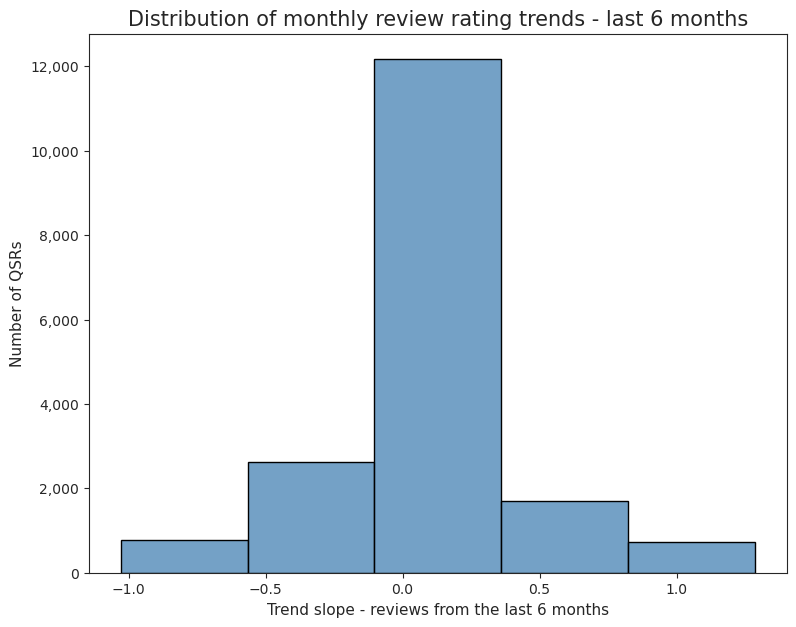

In [108]:
# Plot the result
plt.figure(figsize = (9,7))

ax = sns.histplot(x='TREND_SLOPE',  
             data=review_trends,
             binwidth=0.5,
             color='steelblue', edgecolor='black')

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

ax.set_title("Distribution of monthly review rating trends - last 6 months", fontsize=15)
ax.set_xlabel("Trend slope - reviews from the last 6 months", fontsize=11)
ax.set_ylabel("Number of QSRs", fontsize=11)

<h3 style="color:#475569;"> <i> Comments</i></h3>   

- Around 4,000 QSRs experienced a decrease in their review ratings over the last 6-month period.
- Since a decrease in review ratings can negatively impact revenue [(QSR Media UK)](https://qsrmedia.co.uk/executive-insights/commentary/responding-negative-restaurant-reviews), these trends should be a cause of concern for the affected QSRs.
- On the flip side, QSRs that have seen an improvement to their ratings should investigate what actions in particular have improved their customer satisfaction.  

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
4.2.3 Write the dataframes back to Snowflake
</h1>

</div>


In [109]:
# Convert the datetime column to Snowflake-friendly datetime format
monthly_review_rating['REVIEW_DATE_MONTH'] = monthly_review_rating['REVIEW_DATE_MONTH'].dt.strftime('%Y-%m-%d')

In [110]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_REVIEW_MONTHLY_RATING
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    monthly_review_rating,
    table_name="QSR_REVIEW_MONTHLY_RATING",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  301766


In [111]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_BUSINESS_RATING_TRENDS
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    review_trends,
    table_name="QSR_BUSINESS_RATING_TRENDS",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18000


---

<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Summary of findings</u>
</h3>

<p>

 - **Review volume:** The analysis showed that whilst the majority of the QSR population have between 0 to 50 reviews, some chains with a wide market presence have up to 2,000 reviews (outliers). To normalise the data, we calculated the review volume per business ID, not per brand name, which othwerwise would have heavily skewed the data. For the scorecard, higher points will be awarded to QSRs with a higher review volume - the rational being that review volume translates to consumer trust.
> **Limitations:** High review volumes that have a below average rating could deter customers. At the same time, if the restaurant have taken the time to properly acknowledge and respond to the criticism, this could sway consumer perception from negative, to positive [(QSR Magazine, 2023)](https://www.qsrmagazine.com/uncategorized/missing-piece-consumer-satisfaction-restaurant-industry/). For that reason, we decided to use higher review volume as a positive measure for the scorecard.  
 - **Rating trends:** The trend slope calculations showed that majority of the QSRs have seen consistent or improved performance across Yelp reviews in the last 6-months (August 2021 - January 2022). Higher scores will be given to these QSRs, whereas the 4,000 QSRs that have seen a dip in performance, will receive lower scores. 

</p>

</li>

</ol>

</div>

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
5. RECENCY WEIGHTED RISK
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
This section evaluates the recency-weighted risk for each QSR location, focusing on two risk factors: 

- **Detection of recent negative spikes**: Calculated using the rolling standard deviation and z-score for the last 3 months. If a negative spike was detected (translated as a z-score at -1.0 or below), the boolean 'True' gets returned. For all other scenarios, boolean 'False' gets returned. The 3-month time frame was used to capture recent trends that can be actioned by QSRs; in the fast-moving QSR sector, things move quickly, so information needs to be recent to remain relevant. 
- **Recency-weighted average weighting:** Uses a decay-factor to award higher weights to more recent reviews, considered over a 12-month period. The rational behind this is that market performance can change quickly - restaurants that struggled 12-months ago may excel today, and vice versa. Therefore, higher points will be awarded to QSRs that have a higher recency-weighted average star rating. 


</p>

</li>

</ol>

</div>

---

<h1 style="color:#0F766E;"><b> 5.1 <u>Operational Risk Spike Detection</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
5.1.1 Detection of recent negative spikes
</h1>

</div>


In [112]:
def detect_negative_spikes(df, recent_months=3):

    # Create copy 
    df = df.copy()

    # Converting to datetime
    df['REVIEW_DATE_MONTH'] = pd.to_datetime(
        df['REVIEW_DATE_MONTH'],format='%m/%Y',errors='coerce')

    # Sorting months before grouping 
    df = df.sort_values([
        'BUSINESS_ID',
        'REVIEW_DATE_MONTH'])

    # Monthly average star rating
    monthly = (
        df.groupby([
            'BUSINESS_ID',
            'BUSINESS_NAME',
            'REVIEW_DATE_MONTH']).agg(
            
            AVERAGE_STAR_RATING=('REVIEW_STARS', 'mean'),

            # Count number of reviews so can filter out those with less than 5 later           
            # Helps avoid false spikes from tiny review counts
            REVIEW_COUNT=('REVIEW_STARS', 'size'),

            # Keep review text (list of all texts for that month)
            REVIEW_TEXT=('REVIEW_TEXT', lambda x: list(x))).reset_index())

    # Ensure months are in proper order within each business
    monthly = monthly.sort_values([
        'BUSINESS_ID',
        'REVIEW_DATE_MONTH']).reset_index(drop=True)

    # Building a rolling baseline of last 6 months
    # Excludes current month from baseline 
    monthly['rolling_mean'] = (
        monthly.groupby('BUSINESS_ID')['AVERAGE_STAR_RATING']
        .transform(lambda x: (
            x.shift(1).rolling(window=6, min_periods=3).mean())))

    monthly['rolling_std'] = (
        monthly.groupby('BUSINESS_ID')['AVERAGE_STAR_RATING']
        .transform(lambda x: (
            x.shift(1).rolling(window=6, min_periods=3).std())))

    # Filtering out where standard deviation is below 0.25 to avoid inflated z scores
    monthly['adjusted_std'] = (
        monthly['rolling_std'].clip(lower=0.25))

    # Measures how unusual the current month is relative to recent history/ divide by monthly standard deviation
    monthly['z_score'] = (
        (monthly['AVERAGE_STAR_RATING']
         - monthly['rolling_mean'])
        / monthly['adjusted_std'])

    # Filtering out where standard deviation is 0
    monthly['z_score'] = (
        monthly['z_score']
        .replace([np.inf, -np.inf], np.nan))

    # Identifying latest month in dataset
    latest_month = monthly['REVIEW_DATE_MONTH'].max()

    # Filtering to only recent months
    recent_cutoff = (
        latest_month
        - pd.DateOffset(months=recent_months - 1))

    monthly['RECENT_PERIOD'] = (
        monthly['REVIEW_DATE_MONTH']
        >= recent_cutoff)

    # Flag negative spikes
    # Only flagged as spike if has more than 3 reviews, and monthly z score -1.0 or less 
    # Only flags spikes within recent period
    monthly['NEGATIVE_SPIKE'] = (
        (monthly['RECENT_PERIOD']) &
        (monthly['z_score'] < -1.0) &
        (monthly['REVIEW_COUNT'] >= 3))

    return monthly


In [113]:
# Returning results
spikes = detect_negative_spikes(analytics)

spikes.head()

,BUSINESS_ID,BUSINESS_NAME,REVIEW_DATE_MONTH,AVERAGE_STAR_RATING,REVIEW_COUNT,REVIEW_TEXT,rolling_mean,rolling_std,adjusted_std,z_score,RECENT_PERIOD,NEGATIVE_SPIKE
0,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-01-01,5.0,1,[Unfortunately the site for Frankie's is incor...,NaN,NaN,NaN,NaN,False,False
1,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-02-01,5.0,2,[Great new local seafood spot. It' actually re...,NaN,NaN,NaN,NaN,False,False
2,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-03-01,5.0,1,[Great place for group of friends to meet & ea...,NaN,NaN,NaN,NaN,False,False
3,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-06-01,3.5,2,[I was sadly disappointed in my experience. We...,5.000,0.00,0.25,-6.000000,False,False
4,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,2020-08-01,4.0,1,[Ate here for the 1st time on Saturday 08/07/2...,4.625,0.75,0.75,-0.833333,False,False


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

Columns with NaN do not meet the criteria to have a baseline created- 3 consecutive cells of numbers.

In [114]:
# Exploring z score distributions to validate the <-1.0= spike threshold
# Converting monthly z scores to dataframe outside of function
spikes['z_score'].describe()

count    248702.000000
mean         -0.119670
std           1.897168
min         -16.000000
25%          -0.790569
50%           0.074785
75%           0.774972
max          16.000000
Name: z_score, dtype: float64

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

25% of z-scores are below −0.79, a threshold near this value would produce excessive spike detections. A slightly stricter threshold of −1.0 was used to isolate more substantial deviations from historical performance (baseline).

In [115]:
# Calculating the % of z scores within different thresholds

bins = [-np.inf, -2, -1.5, -1, np.inf]
labels = ['< -2', '-2 to -1.5', '-1.5 to -1', '>= -1']

spikes['z_bin'] = pd.cut(spikes['z_score'], bins=bins, labels=labels)

pct = spikes['z_bin'].value_counts(normalize=True) * 100 
pct

z_bin
>= -1         79.799519
< -2           8.369856
-1.5 to -1     7.538741
-2 to -1.5     4.291883
Name: proportion, dtype: float64

In [116]:
# How many negative spikes are there?
spikes['NEGATIVE_SPIKE'].value_counts()

NEGATIVE_SPIKE
False    301186
True        580
Name: count, dtype: int64

In [117]:
# Showing negative spikes only for validation.
only_spikes = spikes[spikes['NEGATIVE_SPIKE']]

In [118]:
only_spikes.head()

,BUSINESS_ID,BUSINESS_NAME,REVIEW_DATE_MONTH,AVERAGE_STAR_RATING,REVIEW_COUNT,REVIEW_TEXT,rolling_mean,rolling_std,adjusted_std,z_score,RECENT_PERIOD,NEGATIVE_SPIKE,z_bin
417,-78Va3llKcPbL6SW4is8lw,Mungo's Italian Eatery,2021-12-01,1.750000,4,"[We've been there twice, and the food has been...",4.916667,0.204124,0.250000,-12.666667,True,True,< -2
2932,-e1BUAOBk9RAu89c6uTyGA,Texas Roadhouse,2022-01-01,3.857143,7,[I received an $25.00 gift certificate for Chr...,4.434524,0.470381,0.470381,-1.227474,True,True,-1.5 to -1
3087,-fs09akgCKv5rTTy7iUHUg,Ici Macarons & Cafe,2021-12-01,4.000000,3,[I just witnessed the single worst example of ...,4.916667,0.204124,0.250000,-3.666667,True,True,< -2
3561,-mIlmp5l4hKlp1tvHRdvTg,Sonny's Famous Steaks,2021-11-01,2.818182,11,[Overall the food was pretty good. I was expec...,3.757200,0.337324,0.337324,-2.783726,True,True,< -2
3643,-nIXhxPvxST6bTuj9jo1UQ,Damò Pasta Lab,2021-12-01,3.333333,3,[The tiramisu is really good! I would recommen...,3.858730,0.377624,0.377624,-1.391321,True,True,-1.5 to -1


In [119]:
# Extracting QSRs with the biggest dip in star rating in the last 4 months for validation

# Extract five QSRs with the greatest star rating dip (based on z score)
biggest_recent_dips = only_spikes.sort_values("z_score").head(5)
top_ids = biggest_recent_dips["BUSINESS_ID"].unique()

# 2. Filter to last 4 months
latest_month = spikes["REVIEW_DATE_MONTH"].max()
cutoff = latest_month - pd.DateOffset(months=3)

recent_ts = spikes[
    (spikes["REVIEW_DATE_MONTH"] >= cutoff) &
    (spikes["BUSINESS_ID"].isin(top_ids))]


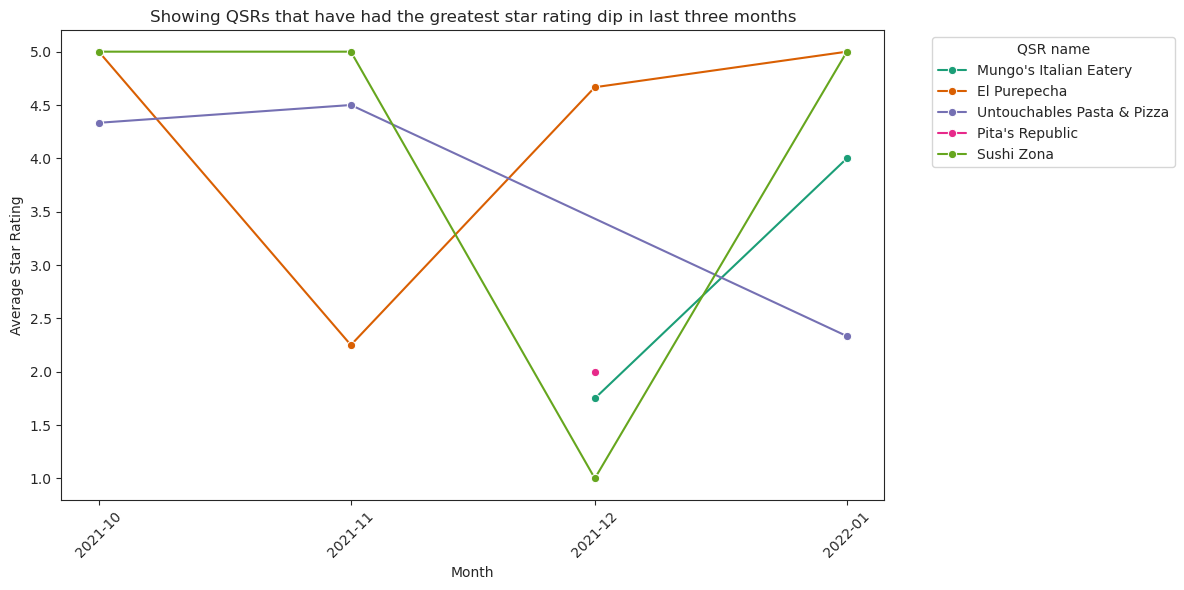

In [120]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=recent_ts,
    x="REVIEW_DATE_MONTH",
    y="AVERAGE_STAR_RATING",
    hue="BUSINESS_NAME",
    palette="Dark2",
    marker="o",
    ax=ax)

# Use only months that exist in your data
month_ticks = sorted(recent_ts["REVIEW_DATE_MONTH"].dropna().unique())

ax.set_xticks(month_ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    
# Placement of legend
plt.legend(title='QSR name', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Showing QSRs that have had the greatest star rating dip in last three months")
plt.xlabel("Month")
plt.ylabel("Average Star Rating")
plt.xticks(rotation=45)
plt.tight_layout()

# Download chart
plt.savefig('Most declining QSRs',bbox_inches="tight")

plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

detect_negative_spikes function is correctly identifying QSRs that have had a recent negative spike in star ratings

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
5.1.2 Write the dataframe back to Snowflake
</h1>

</div>


In [121]:
# =========================================
# Standardise column names
# =========================================

# Convert all dataframe column names to uppercase
spikes.columns = spikes.columns.str.upper()

# =========================================
# Create negative spike risk flag
# =========================================

# Convert boolean TRUE/FALSE values (note the ~ value)
# 1: positive, the business had no negative trend review in the past 3 months
# 0: penalty, the business has had negative trend review in the past 3 months
spikes["NEGATIVE_SPIKE_SCORE"] = (~spikes["NEGATIVE_SPIKE"]).astype(int)

# only negative_spike useed for scoring
export_spikes = spikes[[
    "BUSINESS_ID",
    "NEGATIVE_SPIKE",
    "NEGATIVE_SPIKE_SCORE"
]]

# remove duplicatets 
export_spikes = export_spikes.drop_duplicates()

# View results
print("\nNegative spike check:\n",export_spikes[
    export_spikes["NEGATIVE_SPIKE"] == True
][["NEGATIVE_SPIKE", "NEGATIVE_SPIKE_SCORE"]].head())

print("\n Not Negative spike check:\n",export_spikes[
    export_spikes["NEGATIVE_SPIKE"] == False
][["NEGATIVE_SPIKE", "NEGATIVE_SPIKE_SCORE"]].head())

print("\n number of rows for export negative spikes:\n", len(export_spikes))


Negative spike check:
       NEGATIVE_SPIKE  NEGATIVE_SPIKE_SCORE
417             True                     0
2932            True                     0
3087            True                     0
3561            True                     0
3643            True                     0

 Not Negative spike check:
     NEGATIVE_SPIKE  NEGATIVE_SPIKE_SCORE
0            False                     1
14           False                     1
15           False                     1
28           False                     1
33           False                     1

 number of rows for export negative spikes:
 18524


In [122]:
# export to Snowflake
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_BUSINESS_RECENT_SPIKES
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    export_spikes,
    table_name="QSR_BUSINESS_RECENT_SPIKES",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18524


<h1 style="color:#0F766E;"><b> 5.2 <u>Recency-weighted average rating</b></u></h2>

<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
The below workflow implements a <b>Recency-Weighted Average Rating</b> at business level.<br>
The objective is to give more importance to recent customer reviews while progressively reducing the influence of older reviews.
</p>

<ol>

<li>

<h4 style="color:#1F4E79;">
Defining the Reference Date
</h4>

<p>
Because the dataset is historical and static, the most recent review date in the dataset is treated as the "present day" reference point.
<br>
The age of each review is then calculated in days relative to this latest review date:
</p>

<ul>
    <li>A review written today has an age of 0 days</li>
    <li>A review written one year ago has an age of 365 days</li>
</ul>

</li>

<li>

<h4 style="color:#1F4E79;">
Defining the Decay Rate
</h4>

<p>
The methodology applies the concept of a half-life using exponential decay.
A half-life of 365 days means that after one year, a review contributes only half of its original influence to the final score.
<br>
The decay constant \( \lambda \) controls the speed at which older reviews lose importance over time.
</p>

</li>

<li>

<h4 style="color:#1F4E79;">
Calculating the Time Decay Factor
</h4>

<p>
Each review receives a recency weight using the exponential decay formula: \( e^{-\lambda t} \)
</p>

<ul>
    <li>0-day-old review → weight = 1.00</li>
    <li>365-day-old review → weight = 0.50</li>
    <li>730-day-old review → weight = 0.25</li>
</ul>

<p>
This ensures that newer reviews have a stronger influence on the final business rating.
</p>

</li>

<li>

<h4 style="color:#1F4E79;">
Combining Review Rating and Recency
</h4>

<p>
The customer review star rating is multiplied by the recency decay factor to create a weighted review contribution.
<br>
This step combines:
</p>

<ul>
    <li>customer sentiment (star rating)</li>
    <li>review freshness (time decay)</li>
</ul>

</li>

<li>

<h4 style="color:#1F4E79;">
Calculating the Business-Level Weighted Average
</h4>

<p>
Finally, reviews are aggregated at business level using a weighted average formula:
</p>

<p style="font-size:16px;">
\[
\text{Weighted Average Rating}
=
\frac{\sum (\text{Stars} \times \text{Weight})}
{\sum \text{Weight}}
\]
</p>

<p>
The resulting score reflects both customer satisfaction and the recency of customer feedback.
</p>

</li>

</ol>

</div>

In [123]:
# Anchor to most recent date in the dataset
max_date = analytics["REVIEW_DATE"].max()

# 1. Calculate age in days
analytics["AGE_DAYS"] = (max_date - analytics["REVIEW_DATE"]).dt.days

# 2. Calculate lambda (365-day half-life)
half_life = 365
lam = np.log(2) / half_life

# 3. Calculate the time decay factor for the row
analytics["DECAY_FACTOR"] = np.exp(-lam * analytics["AGE_DAYS"])

# 4. Multiply the decay factor by REVIEW_COUNT to get the final adjusted weight
analytics["FINAL_WEIGHT"] = (
    analytics["DECAY_FACTOR"] * analytics["BUSINESS_REVIEW_COUNT"]
)

# Calculate the weighted stars product for the numerator
analytics["WEIGHTED_STARS_PRODUCT"] = (
    analytics["REVIEW_STARS"] * analytics["FINAL_WEIGHT"]
)

# Group by business and sum the components
# Formula: Sum(stars * final_weight) / Sum(final_weight)
grouped = analytics.groupby(["BUSINESS_ID", "BUSINESS_NAME"]).agg(
    TOTAL_WEIGHTED_STARS=("WEIGHTED_STARS_PRODUCT", "sum"),
    TOTAL_WEIGHT=("FINAL_WEIGHT", "sum"),
    TOTAL_ACTUAL_REVIEWS=("BUSINESS_REVIEW_COUNT", "sum"),  
)

# Calculate the final recency-weighted average
grouped["RECENCY_WEIGHTED_AVG_STARS"] = (
    grouped["TOTAL_WEIGHTED_STARS"] / grouped["TOTAL_WEIGHT"]
)

# Reset index
recency_weighted_ratings = grouped[
    ["TOTAL_ACTUAL_REVIEWS", "RECENCY_WEIGHTED_AVG_STARS"]
].reset_index()


In [124]:
# view output 
recency_weighted_ratings.head()

,BUSINESS_ID,BUSINESS_NAME,TOTAL_ACTUAL_REVIEWS,RECENCY_WEIGHTED_AVG_STARS
0,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,576,4.560543
1,--0iUa4sNDFiZFrAdIWhZQ,Pupuseria Y Restaurant Melba,14,5.000000
2,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,578,2.524836
3,--hF_3v1JmU9nlu4zfXJ8Q,Green District Salads - Monument Circle,225,4.741039
4,--lqIzK-ZVTtgwiQM63XgQ,Wendy's,165,2.119434


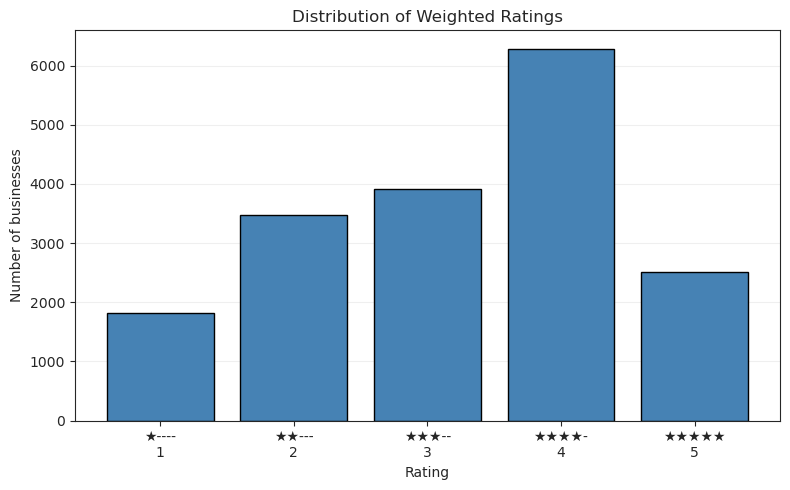

In [125]:
# plot the result
plt.clf()
plt.close('all')
plt.figure(figsize=(8, 5))
plt.hist(recency_weighted_ratings['RECENCY_WEIGHTED_AVG_STARS'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         edgecolor='black', color='steelblue', rwidth=0.8)
plt.title('Distribution of Weighted Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of businesses')
plt.xticks([1, 2, 3, 4, 5], star_labels)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

<p>
The distribution of recency-weighted business ratings is concentrated between 3 and 4 stars, with 4-star businesses representing the largest segment of the dataset. 
<br>
This suggests that most QSR businesses receive generally positive customer feedback, while relatively few locations experience persistently low ratings.
<br>
Because the ratings are recency-weighted, the distribution reflects more recent customer sentiment rather than historical lifetime performance.
</p>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
5.2.1 Write the dataframe back to Snowflake
</h1>

</div>


In [126]:
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_RECENCY_WEIGHTED_RATINGS
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    recency_weighted_ratings,
    table_name="QSR_RECENCY_WEIGHTED_RATINGS",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18000


---

<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Summary of findings</u>
</h3>

<p>

 - **Detection of recent negative spikes:** Around 13% of the QSR population have a z-score at -1.5% or below, resulting in a boolean of 'True', and thereby a lower score in the final scorecard. 
 - **Recency-weighted average weighting:** The distribution shows a left-skewed distribution, peaking at 4-stars. However, compared to the historical lifetime performance, the percentage of reviews in the recency-weighted distribution receiving one or two stars is higher, suggesting that more locations are dealing with negative customer sentiment in recent times.
 - These signals **will help QSR managers** take appropriate actions at affected outlets, particularly those that have experienced recent negative spikes. The final scorecard will outline possible reasons behind the trends, along with suitable solutions. 

</p>

</li>

</ol>

</div>

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
6. SENTIMENT TRACKING <br>
& ROOT CAUSE THEMES (NLP)
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
    
- This section **analyses the root-cause themes from customer reviews,** to gain deeper insights into areas for improvement.
- The VADER and ASBA libraries were used for extracting and grouping key themes into **six service categories**:
  1. Service speed
  2. Order accuracy
  3. Customer service
  4. Cleanliness
  5. Value/ price
  6. Food temperature/ quality 
- The thinking behind this approach, is that QSRs will be able to use the resulting insights to **provide solutions to customer pain points**, which may lead to improvements across review ratings.
- Due to processing limitations, the analysis is **restricted to 200,000 reviews**, pulled from the franchise locations with the largest national coverage (i.e. the likes of McDonald's, Starbucks etc.).    


</p>

</li>

</ol>

</div>

---

<h1 style="color:#0F766E;"><b> 6.1 <u>Rating and Vader EDA</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.1.1 Seasonality of reviews
</h1>

</div>

In [127]:
# Creating a subset for sentiment analysis
sentiment = analytics[[
    'BUSINESS_ID',
    'BUSINESS_NAME',
    'REVIEW_ID',
    'BUSINESS_STATE',
    'BUSINESS_STATE_FULL_NAME',
    'REVIEW_DATE_MONTH',
    'BUSINESS_REGION',
    'REVIEW_STARS',
    'REVIEW_TEXT'
]].copy()

In [128]:
# Seasonality of reviews
# Creating series for each year to clearly show whether any seasonality to reviews

# Creating monthly series for each year
reviews_series = sentiment[['REVIEW_ID','REVIEW_DATE_MONTH']].copy()   

# Converting review month column to datetime
reviews_series["date"] = pd.to_datetime(reviews_series["REVIEW_DATE_MONTH"], errors="coerce")

# Creating year, month and month number columns
reviews_series["year"] = reviews_series["date"].dt.year
reviews_series["month"] = reviews_series["date"].dt.strftime("%b")
reviews_series["month_num"] = reviews_series["date"].dt.month

# Count number of reviews per month 
reviews_series = (reviews_series.groupby(["year", "month", "month_num"], as_index=False)["REVIEW_ID"].count().rename(columns={"REVIEW_ID": "TOTAL_REVIEWS"}))

# Ordering of months but no plotting of zero
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
years = sorted(reviews_series["year"].unique())

full = pd.MultiIndex.from_product([years, months], names=["year","month"]).to_frame(index=False)

# Merging months onto year series
reviews_series = full.merge(reviews_series, on=["year","month"], how="left")

# Fill missing months with zero reviews
reviews_series["TOTAL_REVIEWS"] = reviews_series["TOTAL_REVIEWS"].fillna(0)

# Ordering of months as numbers in dataframe
month_to_num = {m:i+1 for i, m in enumerate(months)}
reviews_series["month_num"] = reviews_series["month"].map(month_to_num)

# Ordering of months for plotting
reviews_series["month"] = pd.Categorical(reviews_series["month"], categories=months, ordered=True)
reviews_series = reviews_series.sort_values(["year","month_num"])

print(reviews_series.head(10))


   year month  month_num  TOTAL_REVIEWS
0  2018   Jan          1        13941.0
1  2018   Feb          2        13753.0
2  2018   Mar          3        16702.0
3  2018   Apr          4        16001.0
4  2018   May          5        16233.0
5  2018   Jun          6        17060.0
6  2018   Jul          7        18757.0
7  2018   Aug          8        16641.0
8  2018   Sep          9        15001.0
9  2018   Oct         10        14604.0


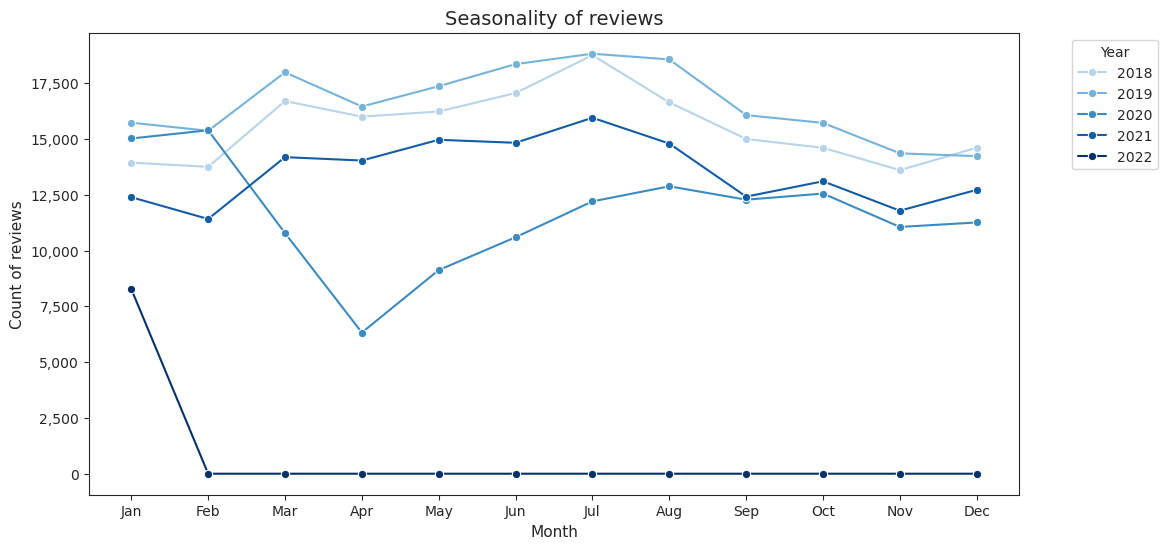

In [129]:
# Use only darker part of colourmap as one line in blues is too light
palette = sns.color_palette("Blues", as_cmap=True)
dark_blues = palette(np.linspace(0.3, 1, 5)) 

plt.figure(figsize=(12, 6))

sns. lineplot(data=reviews_series,x='month',y=reviews_series['TOTAL_REVIEWS'],hue='year',
             marker='o',palette=dark_blues,errorbar=None)

plt.title('Seasonality of reviews',fontsize=14)
plt.xlabel('Month',fontsize=11)
plt.ylabel('Count of reviews',fontsize=11)

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

# Placement of legend
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

In the US, customers are more likely to leave a QSR review in the summer months. This could reflect
higher footfall in this season.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.1.2 Seasonality of negative reviews
</h1>

</div> 

In [130]:
# Plotting negative star review by month. 1 & 2 star weighting
# When are customers most likely to leave a low star rating?
# Create year + month columns
sentiment["YEAR"] = pd.to_datetime(sentiment["REVIEW_DATE_MONTH"]).dt.year
sentiment["MONTH"] = pd.to_datetime(sentiment["REVIEW_DATE_MONTH"]).dt.month

# Aggregate
seasonality = (sentiment.groupby(["YEAR", "MONTH"]).agg(
            TOTAL_REVIEWS=("REVIEW_ID", "count"),NEGATIVE_REVIEWS=("REVIEW_STARS",
                          lambda x: x.isin([1,2]).sum())).reset_index())

# Calculate %
seasonality["NEGATIVE_PCT"] = (seasonality["NEGATIVE_REVIEWS"] /seasonality["TOTAL_REVIEWS"] * 100)

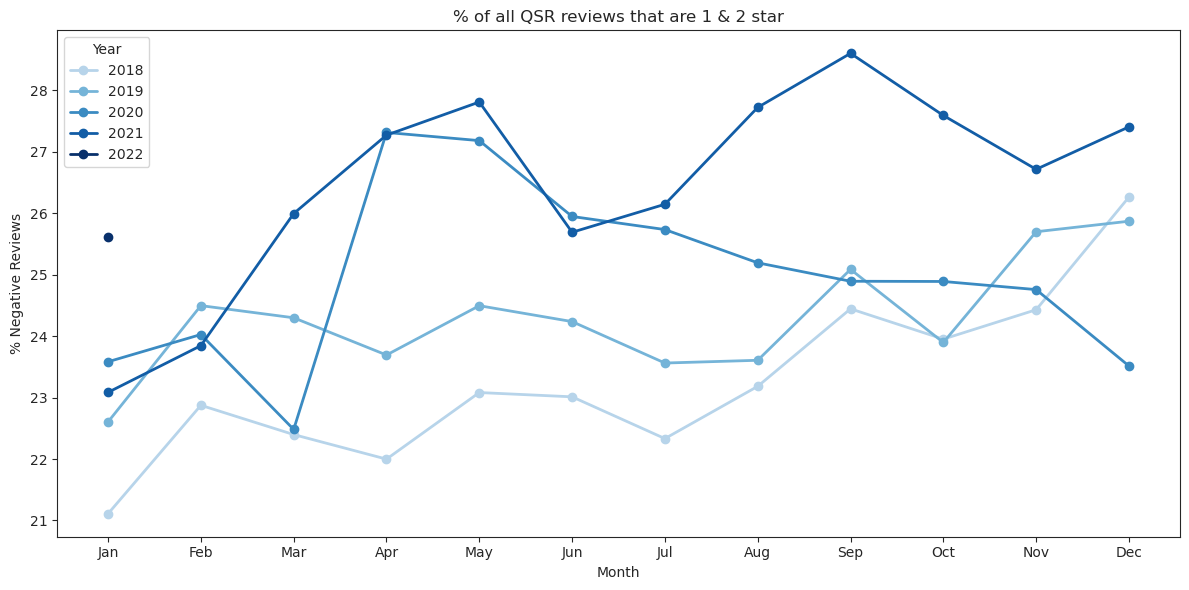

In [131]:
# Plotting seasonality of negative QSR reviews
years = sorted(seasonality["YEAR"].unique())

# Create shades of blue
colours = plt.cm.Blues(np.linspace(0.3, 1, len(years)))

plt.figure(figsize=(12, 6))

for year, color in zip(years, colours):

    temp = seasonality[seasonality["YEAR"] == year]

    plt.plot(
        temp["MONTH"],
        temp["NEGATIVE_PCT"],
        marker="o",
        label=year,
        color=color,     
        linewidth=2)

plt.xticks(
    range(1, 13),
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"])

plt.title("% of all QSR reviews that are 1 & 2 star")
plt.xlabel("Month")
plt.ylabel("% Negative Reviews")
plt.legend(title="Year")

plt.tight_layout()
plt.show()


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

The proportion of reviews that are one and two stars declines in the summer months and tends to climb again towards Christmas when people's expectations maybe higher.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.1.3 Vader sentiment analysis
</h1>

</div> 

<div style="
    background-color: #fefce8;
    border-left: 4px solid #ca8a04;
    padding: 20px;
    border-radius: 8px;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
    box-shadow: 0 1px 3px 0 rgba(0, 0, 0, 0.05);
">
    <h3 style="color: #854d0e; margin-top: 0; font-weight: 600; letter-spacing: -0.025em;">
        Data Sampling Strategy & Scope
    </h3>
    <p style="color: #451a03; font-size: 0.95em; line-height: 1.5; margin-bottom: 15px;">
        <strong>Context:</strong> Due to current local memory and compute constraints, the NLP pipeline is optimized to process a maximum of <strong>200,000 reviews</strong>. 
    </p>
    <hr style="border: 0; border-top: 1px solid #fef08a; margin: 15px 0;">
    <ul style="color: #713f12; font-size: 0.9em; line-height: 1.6; padding-left: 20px; margin-bottom: 0;">
        <li><strong style="color: #451a03;">Selection Bias Mitigation:</strong> To maximize data density and relevance under this cap, the sample is restricted exclusively to high-volume, top-tier business chains (detailed below).</li>
        <li><strong style="color: #451a03;">Future Scalability:</strong> Transitioning this pipeline to a cloud-based API or Spark environment will remove these volume thresholds in future iterations.</li>
    </ul>
</div>

In [132]:
# Calculate the number of locations per business name. 
# Calculate the number of reviews per business name. 
# Group by BUSINESS_ID.
analytics_reviews_count = analytics.groupby(['BUSINESS_NAME', 'BUSINESS_TYPE']).agg({'BUSINESS_ADDRESS': 'nunique', 
                                                                       'REVIEW_TEXT': 'nunique'}).reset_index()

# View output. 
analytics_reviews_count

,BUSINESS_NAME,BUSINESS_TYPE,BUSINESS_ADDRESS,REVIEW_TEXT
0,#1 Mongolian Bbq - Best Stir Fried Noodles In ...,Independent,1,25
1,&Pizza - Upenn,Independent,1,65
2,&Pizza - Walnut,Independent,1,184
3,&Pizza - Willow Grove,Independent,1,20
4,1 2 Tea,Independent,1,42
...,...,...,...,...
9852,Zuzu's Kitchen,Independent,1,60
9853,Zz Pizzas,Independent,1,5
9854,Àlavita,Independent,1,146
9855,Àrdana Food & Drink,Independent,1,83


In [133]:
# Sort by business address (i.e. the number of locations). 
analytics_reviews_sorted = analytics_reviews_count.sort_values(by='BUSINESS_ADDRESS', ascending=False)

# View output. 
analytics_reviews_sorted.head(20)

,BUSINESS_NAME,BUSINESS_TYPE,BUSINESS_ADDRESS,REVIEW_TEXT
5461,Mcdonald's,Chain,615,10752
2488,Dunkin',Chain,491,5352
8101,Subway,Chain,358,1833
8278,Taco Bell,Chain,337,4932
9591,Wendy's,Chain,301,3646
1135,Burger King,Chain,298,3150
2358,Domino's Pizza,Chain,280,3419
6354,Papa John's Pizza,Chain,176,1593
6762,Pizza Hut,Chain,170,1580
6900,Popeyes Louisiana Kitchen,Chain,149,3371


In [134]:
# Add a cumulative column. 
analytics_reviews_sorted['CUM_REVIEWS'] = analytics_reviews_sorted['REVIEW_TEXT'].cumsum()

# Cap the DataFrame at 200K reviews (cum). 
sample_analytics = analytics_reviews_sorted[analytics_reviews_sorted['CUM_REVIEWS'] <=200000]

# View output. 
sample_analytics

,BUSINESS_NAME,BUSINESS_TYPE,BUSINESS_ADDRESS,REVIEW_TEXT,CUM_REVIEWS
5461,Mcdonald's,Chain,615,10752,10752
2488,Dunkin',Chain,491,5352,16104
8101,Subway,Chain,358,1833,17937
8278,Taco Bell,Chain,337,4932,22869
9591,Wendy's,Chain,301,3646,26515
...,...,...,...,...,...
7854,Sodalicious,Chain,2,27,199489
7981,Squealers Award Winning Barbeque,Chain,2,159,199648
8055,Stella's Ice Cream,Chain,2,92,199740
3675,Habit Burger Grill,Chain,2,101,199841


In [135]:
# Reset the index. 
sample_final = sample_analytics.reset_index(drop=True) 

# View output. 
sample_final 

,BUSINESS_NAME,BUSINESS_TYPE,BUSINESS_ADDRESS,REVIEW_TEXT,CUM_REVIEWS
0,Mcdonald's,Chain,615,10752,10752
1,Dunkin',Chain,491,5352,16104
2,Subway,Chain,358,1833,17937
3,Taco Bell,Chain,337,4932,22869
4,Wendy's,Chain,301,3646,26515
...,...,...,...,...,...
665,Sodalicious,Chain,2,27,199489
666,Squealers Award Winning Barbeque,Chain,2,159,199648
667,Stella's Ice Cream,Chain,2,92,199740
668,Habit Burger Grill,Chain,2,101,199841


In [136]:
# Export as CSV. 
# sample_final.to_csv("NLP_capped.csv", index=False)

In [137]:
data_valid(sample_final)


Missing Values (per column):
BUSINESS_NAME       0
BUSINESS_TYPE       0
BUSINESS_ADDRESS    0
REVIEW_TEXT         0
CUM_REVIEWS         0
dtype: int64

Unique Values (per column):
BUSINESS_NAME       670
BUSINESS_TYPE         2
BUSINESS_ADDRESS     68
REVIEW_TEXT         353
CUM_REVIEWS         670
dtype: int64

Duplicate Rows in DataFrame:
0

Record Counts in DataFrame:
670

Descriptive Statstics in DataFrame:
       BUSINESS_ADDRESS   REVIEW_TEXT    CUM_REVIEWS
count        670.000000    670.000000     670.000000
mean          12.753731    298.507463  150359.200000
std           44.330198    679.986342   38408.960967
min            2.000000      2.000000   10752.000000
25%            2.000000     54.000000  129270.250000
50%            3.000000    123.000000  157717.000000
75%            6.000000    274.500000  181640.750000
max          615.000000  10752.000000  200000.000000

Data Types in DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data col

<h3 style="color:#475569;"> <i> Comments</i></h3>   

- The QSRs with the largest number of locations were ranked in a descending order.
- The 'CUM_REVIEWS' column capped the number of QSRs once the cumulative number of reviews reached 200,000.
- By using this approach, our NLP analysis will focus on the top chains, ranked by location, excluding independents.
- As mentioned earlier, an API could help circumvent this constraint, enabling a full analysis of unlimited QSR locations. 

In [138]:
# Add the business IDs. 
sample_business_names = sample_final[['BUSINESS_NAME']]

# Output. 
sample_business_names

,BUSINESS_NAME
0,Mcdonald's
1,Dunkin'
2,Subway
3,Taco Bell
4,Wendy's
...,...
665,Sodalicious
666,Squealers Award Winning Barbeque
667,Stella's Ice Cream
668,Habit Burger Grill


In [139]:
# Add business IDs to the column.
sample_business_id = pd.merge(
    sample_business_names,
    analytics[['BUSINESS_NAME', 'BUSINESS_ID']],
    on='BUSINESS_NAME',
    how='left'
)

In [140]:
# View output. 
sample_business_id

,BUSINESS_NAME,BUSINESS_ID
0,Mcdonald's,UxPNpzKEC4FpdidHz8MCcA
1,Mcdonald's,W0QKIbOBpPDD56umLllxsg
2,Mcdonald's,jHZi9YI4zUWoBZ0BTj_92w
3,Mcdonald's,Tgq7FzfhLx97K5NBXGO5fA
4,Mcdonald's,Tgq7FzfhLx97K5NBXGO5fA
...,...,...
200735,The Bistro,ctVn7wMvJX8f4Z9SnOnrHw
200736,The Bistro,ctVn7wMvJX8f4Z9SnOnrHw
200737,The Bistro,ctVn7wMvJX8f4Z9SnOnrHw
200738,The Bistro,ctVn7wMvJX8f4Z9SnOnrHw


In [141]:
# Drop duplicates. 
sample_business_clean = sample_business_id.drop_duplicates()

# Reset the index.
sample_business_clean.reset_index(drop=True, inplace=True) 

# View output. 
sample_business_clean

,BUSINESS_NAME,BUSINESS_ID
0,Mcdonald's,UxPNpzKEC4FpdidHz8MCcA
1,Mcdonald's,W0QKIbOBpPDD56umLllxsg
2,Mcdonald's,jHZi9YI4zUWoBZ0BTj_92w
3,Mcdonald's,Tgq7FzfhLx97K5NBXGO5fA
4,Mcdonald's,kayZz9qkn24KGspavVYxfA
...,...,...
8570,Stella's Ice Cream,3rbEwQf_VVA_7C7Tl22gBg
8571,Habit Burger Grill,VQypuqGYepDfaJS7A-QjYg
8572,Habit Burger Grill,-ipZBVF9nWm1vzrvQ3444A
8573,The Bistro,jVPzcDZHP8Vz32tInYbzLw


In [142]:
# Download CSV file. 
# sample_clean.to_csv("NLP_capped_ID.csv", index=False)

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.1.4 Write the dataframe back to Snowflake
</h1>

</div>


In [143]:
# to save the list of business_id in database 
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_SAMPLE_BUSINESS_ID
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    sample_business_clean,
    table_name="QSR_SAMPLE_BUSINESS_ID",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  8575


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.1.5 Sentiment analysis
</h1>

</div>


<div style="
    background-color: #f8fafc;
    border-left: 4px solid #64748b;
    padding: 20px;
    border-radius: 8px;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
    box-shadow: 0 1px 3px 0 rgba(0, 0, 0, 0.05);
">
    <h3 style="color: #334155; margin-top: 0; font-weight: 600; letter-spacing: -0.025em;">
        Pipeline Design: Sentiment Preprocessing Note
    </h3>
    <p style="color: #475569; font-size: 0.95em; line-height: 1.5; margin-bottom: 0;">
        <strong>Strategic Decision:</strong> Standard text preprocessing (such as lowercasing, removing punctuation, or stripping emojis) is explicitly omitted for the VADER pipeline. <br> 
        VADER is natively tuned to leverage capitalization, exclamation marks, and emojis to calculate sentiment intensity; removing these elements would actively degrade model performance.
    </p>
</div>

In [144]:
# Create a variable  to store the SentimentIntensityAnalyser() method.
analyse = SentimentIntensityAnalyzer()

In [145]:
# Keep only reviews for businesses present in the clean business dataset ("sample_business_clean")
sample_sentiment = sentiment[sentiment['BUSINESS_ID'].isin(sample_business_clean['BUSINESS_ID'])].copy()

# Verify total available rows before drawing the final sample
print('Total matching reviews available:', len(sample_sentiment))

Total matching reviews available: 200740


In [146]:
# Run Vader on each each review
sample_sentiment['VADER_SCORE'] = sample_sentiment['REVIEW_TEXT'].apply(lambda x: analyse.polarity_scores(str(x))['compound'])

In [147]:
sample_sentiment.head()

,BUSINESS_ID,BUSINESS_NAME,REVIEW_ID,BUSINESS_STATE,BUSINESS_STATE_FULL_NAME,REVIEW_DATE_MONTH,BUSINESS_REGION,REVIEW_STARS,REVIEW_TEXT,YEAR,MONTH,VADER_SCORE
0,G5kWtADcIMy5CgrjUerfnA,Chariot Pizza,tRCAiCmBpTx8omM_o8yNsA,AZ,Arizona,2018-01-01,West,2.0,I got a coupon via email from FiveStars that I...,2018,1,0.5245
4,zu1V7XhERCFA23srN_ro7g,Panera Bread,IfTkHd76hkIf-bMvibbfHg,PA,Pennsylvania,2019-10-01,Northeast,5.0,Want to give a shout out to assistant manager ...,2019,10,0.5411
10,4GEYFqAia0tCjkm2qwRVjg,Kfc,hFaQss_7xmuqa0uJDd6uyA,TN,Tennessee,2019-05-01,South,5.0,This is the best KFC. We come from Hendersonvi...,2019,5,0.9794
12,bK8e7Say_kRIUCgejOSVyw,Domino's Pizza,m3ZDy_tvYlP5y3_mM8l92A,PA,Pennsylvania,2019-05-01,Northeast,5.0,Wonderful delivery staff. Friendly environment...,2019,5,0.9421
21,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,ZqHEYLPPdpLoLvzrcx4f5A,MO,Missouri,2020-03-01,Midwest,1.0,"Oh, Chipotle - what happened to you? Ever sinc...",2020,3,-0.3400


In [148]:
sample_sentiment['vader_sentiment'] = pd.cut(sample_sentiment.VADER_SCORE, bins=[-1, -0.05, 0.05, 1], labels=['negative','neutral','positive'])

In [149]:
# Converting to percentages
sent_pct = sample_sentiment.vader_sentiment.value_counts(normalize=True) * 100

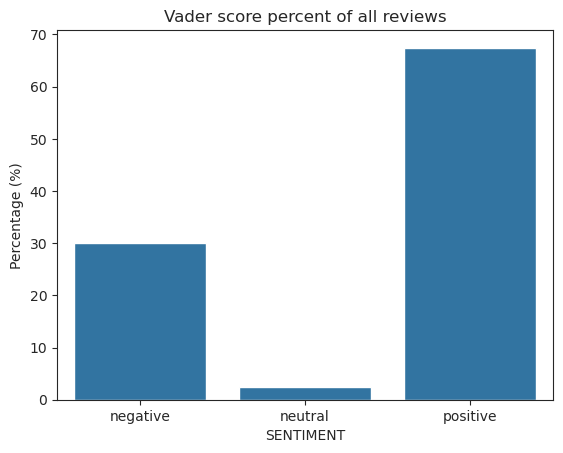

In [150]:
sns.barplot(x=sent_pct.index, y=sent_pct.values)
plt.title('Vader score percent of all reviews')
plt.xlabel('SENTIMENT')
plt.ylabel('Percentage (%)')

plt.savefig('VADER scores %',bbox_inches="tight")
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>  

The bar chart shows that the vast majority of reviews are positive (around 67%), followed by negative reviews at 30%, while neutral reviews make up a tiny fraction (under 5%) of the total dataset.

#

<h3 style="color:#475569;"> <i> Run Vader on for each grouped business ID by month</i></h3>   

In [151]:
def month_vader(
    df,
    text_col="REVIEW_TEXT",
    business_id_col="BUSINESS_ID",
    business_name_col="BUSINESS_NAME",
    business_state_col="BUSINESS_STATE_FULL_NAME",
    date_col="REVIEW_DATE_MONTH"):

    data = df.copy()

# Convert date column to datetime
    data[date_col] = pd.to_datetime(data[date_col])

  
# Calculate VADER per review
    sia = SentimentIntensityAnalyzer()
    data["VADER_SCORE"] = data[text_col].apply(
        lambda x: sia.polarity_scores(str(x))["compound"])

# Group by business + name + state + month
    monthly_vader = (
        data.groupby([
            business_id_col,
            business_name_col,
            business_state_col,
            "REVIEW_DATE_MONTH"])["VADER_SCORE"].mean().reset_index().rename(columns={"VADER_SCORE": "MONTHLY_VADER"}))

    return monthly_vader


In [152]:
# Return a dataframe from function
QSR_vader_month = month_vader(sample_sentiment)

In [153]:
QSR_vader_month.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,REVIEW_DATE_MONTH,MONTHLY_VADER
0,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,Pennsylvania,2018-01-01,0.34865
1,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,Pennsylvania,2018-03-01,0.26105
2,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,Pennsylvania,2018-06-01,0.00000
3,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,Pennsylvania,2018-11-01,0.97900
4,--epgcb7xHGuJ-4PUeSLAw,Manhattan Bagel,Pennsylvania,2019-02-01,-0.64780


<h1 style="color:#0F766E;"><b> 6.2 <u>Root Cause Theme Analysis</b></u></h2>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.2.1 ABSA with embedding
</h1>

</div> 

<h3 style="color:#475569;"> <i> Preparing data before NLP</i></h3>   

In [154]:
# Creating function for NLP data preperation-Tokenise, lower case, remove puntuation/stopwords and lemmatisation.
# Defining stop words
english_stopwords = set(stopwords.words('english'))

def clean_review_tokens(text):
    
    # Tokenise words
    tokens = word_tokenize(str(text))
    
    # Change all to lower case and join with a space.
    tokens = [word.lower() for word in tokens]
    
    # Replace all the punctuation in review column.
    tokens = [word for word in tokens if word not in string.punctuation]
    
    # Filter out tokens that are neither alphabet nor numbers.
    tokens = [word for word in tokens if word.isalnum()]

    # Defining stop words
    english_stopwords = set(stopwords.words('english'))
    
    # Removing stopwords
    tokens = [word for word in tokens if word not in english_stopwords]
    
    # Create an instance of the class.
    lemmatizer = WordNetLemmatizer()
    
    # Apply lemmatisation to both columns with stop words removed 
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return tokens



In [155]:
sample_sentiment['REVIEW_TOKENS_NONSTOP_lemma'] = sample_sentiment['REVIEW_TEXT'].apply(clean_review_tokens)

In [156]:
print(sample_sentiment['REVIEW_TOKENS_NONSTOP_lemma'].head())

0     [got, coupon, via, email, fivestars, 10, dolla...
4     [want, give, shout, assistant, manager, dan, h...
10    [best, kfc, come, hendersonville, frequently, ...
12    [wonderful, delivery, staff, friendly, environ...
21    [oh, chipotle, happened, ever, since, coli, is...
Name: REVIEW_TOKENS_NONSTOP_lemma, dtype: object


In [157]:
# Determine the 50 most common words in negative reviews to inform embedding 
# Apply VADER filter
filtered = sample_sentiment[sample_sentiment['VADER_SCORE'] < 0.05]

# Flatten tokens from the filtered dataframe
token_word_summary = [
    t for sublist in filtered['REVIEW_TOKENS_NONSTOP_lemma']
    for t in sublist]

# Frequency distribution
freq_summary = FreqDist(token_word_summary)

top50_summary = freq_summary.most_common(50)

# Convert to dataframe
neg_top50 = pd.DataFrame(top50_summary, columns=['word', 'count'])

print(neg_top50)


          word  count
0        order  48414
1         food  37899
2         time  32266
3          get  24701
4          one  22810
5      service  21271
6         back  19546
7        place  19206
8      ordered  18797
9       minute  18336
10          go  18070
11       would  17842
12    location  16920
13         got  16867
14    customer  16399
15       never  15933
16        like  15219
17        even  15138
18       pizza  14609
19        said  14479
20       could  12453
21     manager  12332
22       asked  12037
23           u  11930
24       drive  11859
25    employee  11503
26        told  11321
27        went  10662
28        ever  10474
29      people   9872
30        good   9781
31     chicken   9742
32       worst   9539
33        rude   9475
34        give   9393
35        wait   9103
36    sandwich   9068
37        come   8839
38       wrong   8549
39         bad   8269
40        know   8212
41       going   8201
42        came   8164
43        make   8089
44        

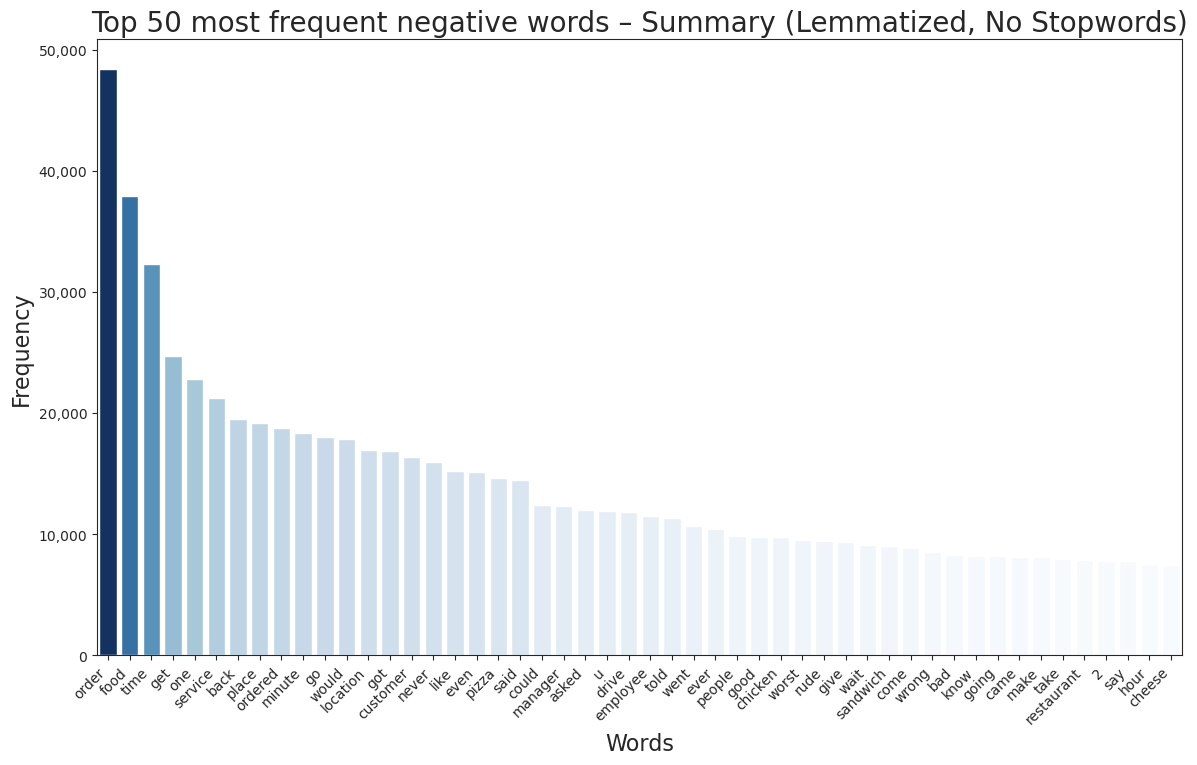

In [158]:
# Plot 50 most frequent words for negative reviews- to inform embedding

plt.figure(figsize=(14, 8), dpi=100)
sns.barplot(data=neg_top50, x='word', y='count', palette='Blues', hue='count', legend=False)

plt.title('Top 50 most frequent negative words – Summary (Lemmatized, No Stopwords)', fontsize=20)
plt.xlabel('Words', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xticks(rotation=45, ha='right')

#Add commas to make large numbers readable
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

plt.show()


## <h3 style="color:#475569;"> <i> Key Observations & Data Distribution</i></h3>   

- **The Long-Tail Distribution**: The chart exhibits a sharp, right-skewed "long-tail" distribution. A small handful of words dominate the total frequency, while the majority of the top 50 words level out to a steady frequency between 8,000 and 15,000 occurrences.

- **Top Drivers**: The words "**order**" (~ 49,000), "**food**" (~ 38,000), and "**time**" (~ 32,000) are heavily dominant, indicating that the core complaints are overwhelmingly centered around transactional issues, product quality, and service speed.

- We can see some big categories
  - **Operational & Efficiency (Time)** - *time, service, back, ordered, minute, wait, hour*
  - **Staff & Customer Service** - *customer, manager, asked, employee, told, rude*
  - **Product & Quality** - *food, pizza, chicken, sandwich, cheese*

- Few natural language processing (NLP) artifacts visible: words like "good" appear in this negative word count

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.2.2 ABSA NEGATIVE REVIEWS ONLY
</h1>

</div> 

<h3 style="color:#475569;"> <i> ABSA and VADER score against each aspect. For negative reviews- VADER (<0.05)</i></h3>    

*While standard sentiment analysis tells us that customers are unhappy, <br> **A**spect-**B**ased **S**entiment **A**nalysis (ABSA) will tell us what they are talking about (specifically useful on negative reviews)*

In [159]:
def run_absa_negative(
    reviews,
    text_col="REVIEW_TEXT",
    business_id_col="BUSINESS_ID",
    business_name_col="BUSINESS_NAME",
    business_state_col="BUSINESS_STATE_FULL_NAME",
    vader_col="VADER_SCORE",
    stars_col="REVIEW_STARS"):

 
    # ----------------------------------------------------
    # 0. Filter to negative reviews only
    # ----------------------------------------------------
    filtered = reviews[reviews[vader_col] < -0.05].copy()
        
    # ----------------------------------------------------
    # 1. Define QSR aspects
    # ----------------------------------------------------
    aspects = {
        "customer_service": [
            "staff", "service", "rude", "friendly", "helpful", "attitude",
            "manager", "ignored", "unprofessional", "polite", "ignore", "personality"],
        "food_quality": [
            "food", "taste", "fresh", "stale", "burnt", "cold", "raw",
            "overcooked", "undercooked", "flavour", "quality", "charred",
            "poison", "uncooked"],
        "cleanliness": [
            "clean", "dirty", "hygiene", "messy", "filthy", "sticky",
            "smell", "odour", "disgusting", "gross", "hygiene", "sanitary"],
        "speed": [
            "slow", "quick", "wait", "queue", "delay", "long line",
            "took forever", "speed"],
        "order_accuracy": [
            "wrong order", "missing", "incorrect", "mistake", "forgot",
            "not what I ordered", "wrong item", "absent", "wrong"],
        "value": [
            "price", "expensive", "cheap", "value", "overpriced",
            "worth", "cost"]}

    # ----------------------------------------------------
    # 2. Sentence tokenisation
    # ----------------------------------------------------
    filtered["sentences"] = filtered[text_col].fillna("").apply(sent_tokenize)

    # ----------------------------------------------------
    # 3. Aspect classifier
    # ----------------------------------------------------
    def classify_aspect(sentence):
        sentence_lower = sentence.lower()
        matched = []
        for aspect, keywords in aspects.items():
            if any(k in sentence_lower for k in keywords):
                matched.append(aspect)
        return matched

    # ----------------------------------------------------
    # 4. VADER on aspect sentences
    # ----------------------------------------------------
    sia = SentimentIntensityAnalyzer()
    aspect_rows = []

    for _, row in filtered.iterrows():
        business_id = row[business_id_col]
        business_name = row[business_name_col]
        business_state = row[business_state_col]

        for sentence in row["sentences"]:
            matched_aspects = classify_aspect(sentence)
            if matched_aspects:
                score = sia.polarity_scores(sentence)["compound"]
                for aspect in matched_aspects:
                    aspect_rows.append({
                        business_id_col: business_id,
                        business_name_col: business_name,
                        business_state_col: business_state,
                        "aspect": aspect,
                        "sentence": sentence,
                        "vader": score})

    aspect_df = pd.DataFrame(
        aspect_rows,
        columns=[
            business_id_col,
            business_name_col,
            business_state_col,
            "aspect",
            "sentence",
            "vader"])

    if aspect_df.empty:
        aspect_summary = pd.DataFrame(
            columns=[
                business_id_col,
                business_name_col,
                business_state_col,
                "aspect",
                "aspect_vader",
                "overall_vader",
                "vader_rank"])

        return aspect_df, aspect_summary

    # ----------------------------------------------------
    # 5. Aggregate sentiment per aspect per location
    # ----------------------------------------------------
    aspect_summary = (
        aspect_df.groupby([business_id_col, business_name_col, business_state_col, "aspect"])["vader"]
        .mean()
        .reset_index()
        .rename(columns={"vader": "aspect_vader"}))

    # ----------------------------------------------------
    # 6. Compute overall VADER per business
    # ----------------------------------------------------
    overall_vader = (
        filtered.groupby([business_id_col, business_name_col, business_state_col])[vader_col]
        .mean()
        .reset_index()
        .rename(columns={vader_col: "overall_vader"}))

    # ----------------------------------------------------
    # 7. Merge overall VADER into aspect summary
    # ----------------------------------------------------
    aspect_summary = aspect_summary.merge(
        overall_vader,
        on=[business_id_col, business_name_col, business_state_col],
        how="left")

    # ----------------------------------------------------
    # 8. Rank businesses by overall VADER (most negative = rank 1)
    # ----------------------------------------------------
    aspect_summary["vader_rank"] = (
        aspect_summary["overall_vader"]
        .rank(method="dense", ascending=True))

    # ----------------------------------------------------
    # 9. Sort by rank so the worst locations appear first
    # ----------------------------------------------------
    aspect_summary = aspect_summary.sort_values("vader_rank")

    return aspect_df, aspect_summary

In [160]:
# Checking vader scores against sentences
aspect_df, aspect_summary = run_absa_negative(sample_sentiment)


In [161]:
aspect_summary.head(20)

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,aspect,aspect_vader,overall_vader,vader_rank
28173,tGzu2uZYz0Yqh5F0H9jmFQ,Currito,Pennsylvania,food_quality,-0.542300,-0.9898,1.0
28172,tGzu2uZYz0Yqh5F0H9jmFQ,Currito,Pennsylvania,customer_service,-0.609550,-0.9898,1.0
28174,tGzu2uZYz0Yqh5F0H9jmFQ,Currito,Pennsylvania,value,0.000000,-0.9898,1.0
30869,yhVVd6_khah7nXobbVksvA,Five Guys,Florida,food_quality,-0.202300,-0.9837,2.0
30870,yhVVd6_khah7nXobbVksvA,Five Guys,Florida,value,-0.202300,-0.9837,2.0
21649,g1GAK8JA4DAAek_io8vR3g,Little Caesars,Missouri,order_accuracy,0.000000,-0.9809,3.0
21650,g1GAK8JA4DAAek_io8vR3g,Little Caesars,Missouri,speed,-0.094067,-0.9809,3.0
21647,g1GAK8JA4DAAek_io8vR3g,Little Caesars,Missouri,customer_service,-0.247940,-0.9809,3.0
21648,g1GAK8JA4DAAek_io8vR3g,Little Caesars,Missouri,food_quality,-0.464000,-0.9809,3.0
11260,LwNtL2KiLzKYudgMQ2iYXw,Jersey Mike's Subs,Florida,cleanliness,-0.476700,-0.9806,4.0


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

The majority of aspect vader scores explain what issue is bringing the overall vader score down. <br>
However, there are some occasions where all the aspect Vader scores are below the overall score.  <br>
The embedded dictionary was rechecked using the BERT transformer model. 
<br>This reduced the inconsistencies, but some still remained <br> e.g Five Guys in Florida:
- Overall VADER Score (overall_vader): $-0.9837$ (Extremely negative)
- Aspect VADER Scores (aspect_vader):
  - value: $-0.2023$ (Mildly negative)
  - food_quality: $-0.4640$ (Mildly negative)

In [162]:
aspect_df.sort_values(by='vader', ascending=True).head(20)

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,aspect,sentence,vader
134607,W6qvolKFTRme_vNGFPw1RA,Burger King,Tennessee,food_quality,Ms.vita is not the person I thought she was bu...,-0.9982
142405,LLx6iXXDWz205YXs6Puzdg,Mcdonald's,Arizona,order_accuracy,Horrible horrible horrible Horrible horrible h...,-0.9982
142403,LLx6iXXDWz205YXs6Puzdg,Mcdonald's,Arizona,cleanliness,Horrible horrible horrible Horrible horrible h...,-0.9982
142402,LLx6iXXDWz205YXs6Puzdg,Mcdonald's,Arizona,food_quality,Horrible horrible horrible Horrible horrible h...,-0.9982
142404,LLx6iXXDWz205YXs6Puzdg,Mcdonald's,Arizona,speed,Horrible horrible horrible Horrible horrible h...,-0.9982
134608,W6qvolKFTRme_vNGFPw1RA,Burger King,Tennessee,speed,Ms.vita is not the person I thought she was bu...,-0.9982
130978,M99ZH5s10gditCQZCJfCMQ,Mcdonald's,New Jersey,customer_service,Since I wrote my first review about this \nMcD...,-0.9964
21438,TlusNUxZToaR7yjn69H5JA,Mcdonald's,Pennsylvania,food_quality,Worst Worst Worst Worst Worst Worst Worst Wors...,-0.9957
15400,M99ZH5s10gditCQZCJfCMQ,Mcdonald's,New Jersey,customer_service,However now there are new owners or managers b...,-0.9952
15401,M99ZH5s10gditCQZCJfCMQ,Mcdonald's,New Jersey,speed,However now there are new owners or managers b...,-0.9952


In [163]:
aspect_df.sort_values(by='vader', ascending=False).head(20)

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,aspect,sentence,vader
36841,Nvidc0_2sYA5ZHrLmXs_0A,Blaze Pizza,Idaho,value,Blaze Pizza it's an absolute fantastic restaur...,0.9649
16098,e4Ykq4wvcUmBQmJTMd3Vzw,Domino's Pizza,Delaware,cleanliness,one time i ordered a pizza medium no cheese sa...,0.9624
16097,e4Ykq4wvcUmBQmJTMd3Vzw,Domino's Pizza,Delaware,food_quality,one time i ordered a pizza medium no cheese sa...,0.9624
16096,e4Ykq4wvcUmBQmJTMd3Vzw,Domino's Pizza,Delaware,customer_service,one time i ordered a pizza medium no cheese sa...,0.9624
142719,jgOgj1gvfPy3DEIpSjQiOQ,Mcdonald's,Nevada,food_quality,I get it that it's fast food but wow at least ...,0.9604
57308,UdcLHHBRIxtelgbKBnhitA,Nifty Fifty's,Pennsylvania,customer_service,But thanks to Will the manager and a older wom...,0.9598
57309,UdcLHHBRIxtelgbKBnhitA,Nifty Fifty's,Pennsylvania,order_accuracy,But thanks to Will the manager and a older wom...,0.9598
113944,SUMe4HABRMtLIGind-RieQ,Ihop,Idaho,speed,District Manager please tell me how a manager ...,0.9552
113943,SUMe4HABRMtLIGind-RieQ,Ihop,Idaho,food_quality,District Manager please tell me how a manager ...,0.9552
113942,SUMe4HABRMtLIGind-RieQ,Ihop,Idaho,customer_service,District Manager please tell me how a manager ...,0.9552


In [164]:
aspect_df[aspect_df['vader'] == 0].head(20)

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,aspect,sentence,vader
0,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,Missouri,food_quality,"However, the chicken bowl was cold and soupy.",0.0
1,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,Missouri,food_quality,And everything tasted so salty.,0.0
2,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,Missouri,food_quality,Even the guacamole tastes pre-packaged.,0.0
3,QJiA9H2GMdp0Ge1zmQpwLg,The Baked Bear,Missouri,value,And pricey!.,0.0
7,W55GtTcl8tv564IZ1tk8vw,Kfc,Arizona,food_quality,Today for example I go in and wait for my food...,0.0
8,W55GtTcl8tv564IZ1tk8vw,Kfc,Arizona,speed,Today for example I go in and wait for my food...,0.0
22,MSHk4H_8PvNEgwfAtGYEDQ,Teriyaki Madness,New Jersey,customer_service,Then the staff up front told the kitchen staff...,0.0
23,MSHk4H_8PvNEgwfAtGYEDQ,Teriyaki Madness,New Jersey,food_quality,Now onto the food quality.,0.0
25,MSHk4H_8PvNEgwfAtGYEDQ,Teriyaki Madness,New Jersey,food_quality,Lots of raw pieces in the fillet.,0.0
30,Hx8DHtPTRq-Qa98fRCTofA,Burger King,Delaware,cleanliness,"The dining room is filthy, the parking lot has...",0.0


In [165]:
aspect_df[
    (aspect_df['BUSINESS_NAME'] == "Wendy's") & 
    (aspect_df['BUSINESS_STATE_FULL_NAME'] == "Louisiana") & 
    (aspect_df['vader'] == 0) & 
    (aspect_df['aspect'] == "food_quality") 
]

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,aspect,sentence,vader
11571,cUAcZ787QO67GrDMnZNsMQ,Wendy's,Louisiana,food_quality,This location has gone down in quality consist...,0.0
11572,cUAcZ787QO67GrDMnZNsMQ,Wendy's,Louisiana,food_quality,Buns are stale.,0.0
11573,cUAcZ787QO67GrDMnZNsMQ,Wendy's,Louisiana,food_quality,The only thing consistent here is the food tem...,0.0
15283,phjKQDkg4l062nUifkqbLQ,Wendy's,Louisiana,food_quality,I have never encountered a fast food restauran...,0.0
24588,LXPOh6K2N4b1zA8wgahlKg,Wendy's,Louisiana,food_quality,When I informed the cashier that the food was ...,0.0
25106,p9xlp1XHbJIag9OdI1o5Zg,Wendy's,Louisiana,food_quality,"As far as the food, it wasn't even for me, it ...",0.0
29880,Ntvm3GvN9dk3GthYv-riUA,Wendy's,Louisiana,food_quality,The manager handed me this food.,0.0
29882,Ntvm3GvN9dk3GthYv-riUA,Wendy's,Louisiana,food_quality,What happened to quality control?,0.0
30182,vrx3ZpbsX9W7C5UFWOghtw,Wendy's,Louisiana,food_quality,While waiting in line at a drive thru next doo...,0.0
36705,mYwkkmabduKgDnbcb2ePJA,Wendy's,Louisiana,food_quality,Food=typical Wendy's.,0.0


<h3 style="color:#475569;"> <i> Observations</i></h3>   

Globally correct, **especially for positive**, <br>
<u>BUT</u>:
  
* <i><u>The "Duplicate Review" Aspect</u></i>
  - A single review text is being broken out across multiple rows if it mentions more than one aspect. Still, the vader score is evaluated on the whole sentence/paragraph, not the specific aspect.
  - e.g. 140427 to 140430: McDonald's in Arizona. The exact same sentence ("Horrible horrible horrible...") is evaluated 4 separate times because it maps to food_quality, cleanliness, speed, and order_accuracy.
  - 
* <i><u>VADER’s Vulnerability to Repetition</u></i>
  - VADER uses rules for capitalization and repetition to intensify sentiment scores.
  - Row 140427 repeats "Horrible" multiple times, pushing the score to an extreme max-negative -0.9982.
  - Row 41686 repeats "Worst" over and over, resulting in -0.9957
  - 
* <i><u>Sarcasm and Complex Language Tripping VADER Up (False Positives)</u></i>
  - Reading some actual sentences, several highly positive scores are, in fact, misclassified:
  - Row 140758 (McDonald's, vader: 0.9604): "I get it that it's fast food but wow at least..." This is clearly a negative or highly sarcastic complaint, but words like "wow" or "at least" might be misread as positive markers.
  - Row 85919 (IHOP, vader: 0.9552): "District Manager please tell me how a manager..." This text is an angry demand to a district manager regarding poor leadership, yet VADER scored it as almost perfectly positive. This usually happens when words like "please" or "appreciate" appear in a formal complaint.
  - Row 149459 (Domino's, vader: 0.9624): A complicated pizza customization order story that scored incredibly high despite likely being a neutral description of an error.
  - 
* <i><u> Problem on some "Neutral" reviews (vader = 0.0)</u></i>
  - "The chicken was so burnt our kids couldn't eat..." (vader: 0.0)
  - "You guys are selling OLD food !" (vader: 0.0)
  - "The SLOWEST." (vader: 0.0)
  - "Extremely long wait for cold, over cooked food!" (vader: 0.0)
  -
* <i><u>Same for rhetorical questions (vader = 0.0)</u></i>
  - Row 73768: "What fast food establishment runs out of soda?"
  - Row 81059: "What happened to quality control?"

In [166]:
# Exporting to excel for analysis
aspect_summary.to_excel("aspect_summary.xlsx", index=False)

<h3 style="color:#475569;"> <i> Embedding check on negative VADER</i></h3>   

In [167]:
# ==============================================================================
#  DATA SELECTION: ISOLATING NEGATIVE SENTIMENT
# ==============================================================================
# Filter for negative reviews to optimize aspect discovery.
# INSIGHT: By isolating VADER negative scores (< 0), we focus the embedding search
# on vocabulary relevant to customer pain points (e.g., "stale", "rude", "delayed").
# This reduces noise from highly positive or irrelevant contextual words in the corpus.

neg = sample_sentiment[sample_sentiment["VADER_SCORE"] < 0].copy()

In [168]:
# ==============================================================================
# ASPECT DICTIONARY EXPANSION FUNCTION
# ==============================================================================
# Checking for similar text in the reviews to expand ASBA dictionary to ensure searches for all relevant words for each aspect :
# Expands predefined aspect seed dictionaries using semantic embeddings derived from the local review corpus vocabulary.
# This bridges the gap between generic seed words and unique customer vocabulary (slang, typos).

def expand_aspects_with_embeddings(
    reviews,
    text_col="REVIEW_TEXT",
    base_aspects=None,
    top_n=10,
    similarity_threshold=0.45):

    # Load embedding model
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Extracting vocabulary
    all_text = " ".join(reviews[text_col].astype(str).tolist()).lower()

    # Simple tokenisation
    words = re.findall(r"[a-zA-Z']+", all_text)
    vocab = list(set(words))

    # Embed vocabulary
    vocab_embeddings = model.encode(vocab, convert_to_tensor=True)

    # ----------------------------------------------------
    # Look up dictionary of words for each aspect
    # ----------------------------------------------------
    expanded_aspects = {
        "customer_service": [
            "staff", "service", "rude", "friendly","traits","useful", "helpful", "attitude","disregarding","demeanor",
            "manager","neglect", "ignored", "unprofessional", "polite", "ignore", "personality"],
        "food_quality": [
            "food", "taste", "fresh", "stale", "burnt", "cold", "raw","chilly","flavor","precooked","toxix",
            "overcooked", "undercooked", "flavour", "quality", "charred",
            "poison", "uncooked"],
        "cleanliness": [
            "clean", "dirty", "hygiene", "messy", "filthy", "sticky","tidy","stink",
            "smell", "odour","odor", "disgusting", "gross", "hygiene", "sanitary"],
        "speed": [
            "slow", "quick", "wait", "queue", "delay", "long line","arrival","lenghy","line",
            "took forever", "fast", "speed"],
        "order_accuracy": [
            "wrong order", "missing", "incorrect", "mistake", "forgot","corrected","item","misplaced",
            "not what I ordered", "wrong item", "absent", "wrong","vanished"],
        "value": [
            "price", "expensive", "cheap", "value", "overpriced","overpaid",
            "worth", "cost"]}

    # Expand each aspect
    for aspect, seed_words in base_aspects.items():

        new_terms = set(seed_words)

        for seed in seed_words:
            seed_emb = model.encode(seed, convert_to_tensor=True)

            # Compute similarity to all vocab words
            cos_scores = util.cos_sim(seed_emb, vocab_embeddings)[0]

            # Get top N similar words
            top_results = np.argpartition(-cos_scores, range(top_n))[:top_n]

            for idx in top_results:
                word = vocab[idx]
                score = float(cos_scores[idx])

                if score >= similarity_threshold:
                    new_terms.add(word)

        expanded_aspects[aspect] = sorted(new_terms)

    return expanded_aspects


In [169]:
# ==============================================================================
# 3. EXECUTION & SEED INITIALIZATION
# ==============================================================================
# Define the baseline vocabulary for Aspect-Based Sentiment Analysis (ABSA).
# Using current dictionary to check against
base_aspects = {
        "customer_service": [
            "staff", "service", "rude", "friendly", "helpful", "attitude","disregarding","demeanor",
            "manager","neglect", "ignored", "unprofessional", "polite", "ignore", "personality"],
        "food_quality": [
            "food", "taste", "fresh", "stale", "burnt", "cold", "raw",
            "overcooked", "undercooked", "flavour", "quality", "charred",
            "poison", "uncooked"],
        "cleanliness": [
            "clean", "dirty", "hygiene", "messy", "filthy", "sticky","tidy",
            "smell", "odour", "disgusting", "gross", "hygiene", "sanitary"],
        "speed": [
            "slow", "quick", "wait", "queue", "delay", "long line",
            "took forever", "fast", "speed"],
        "order_accuracy": [
            "wrong order", "missing", "incorrect", "mistake", "forgot",
            "not what I ordered", "wrong item", "absent", "wrong"],
        "value": [
            "price", "expensive", "cheap", "value", "overpriced",
            "worth", "cost"]}

In [170]:
# Run the pipeline focusing on the top 5 nearest semantic neighbors per seed word
expanded_aspects = expand_aspects_with_embeddings(
    neg,
    text_col="REVIEW_TEXT",
    base_aspects=base_aspects,
    top_n=5,
    similarity_threshold=0.45)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [171]:
# Output final enhanced lexical dictionary
pprint(expanded_aspects)

{'cleanliness': ["'clean",
                 "'clean'",
                 "'cleaning'",
                 'clean',
                 "clean'",
                 'cleaned',
                 'cleaning',
                 'cleanliness',
                 'dirt',
                 'dirtiest',
                 'dirty',
                 'dirtydining',
                 'disgusted',
                 'disgusting',
                 'disgustingfinish',
                 'disgustingly',
                 'disgustingness',
                 'faeces',
                 'filthy',
                 'gross',
                 'grossed',
                 'grossest',
                 'grossly',
                 'grossness',
                 'hygiene',
                 'mess',
                 'messiest',
                 'messy',
                 'odor',
                 'odors',
                 'odour',
                 'sanitary',
                 'sanitation',
                 'smell',
                 'smelled',


Root words that were not part of the original aspect dictionary were then added back up into original list.

In [172]:
#==============================================================================
# UPDATE THE EXISTING ASPECT COLUMN WITH EXPANDED DICTIONARY
# ==============================================================================
# we update the 'aspect' column based

def assign_aspects_from_sentence(sentence_text, aspect_dict):
    if not isinstance(sentence_text, str):
        return "Unclassified"

    sentence_text = sentence_text.lower()

    for aspect, terms in aspect_dict.items():
        for term in terms:
            # INSIGHT: If the dictionary term contains spaces (a phrase like "wrong order"),
            # we check if ALL individual words in that phrase exist in the sentence.
            # This catches "the order was wrong" without breaking simple single-word matches.
            if " " in term:
                phrase_words = term.split()
                if all(word in sentence_text for word in phrase_words):
                    return aspect
            else:
                # Standard substring match for single words (e.g., "quick", "stale")
                if term in sentence_text:
                    return aspect

    return "Unclassified"

In [173]:
# Apply the mapping to create the aspect_df you are calling
aspect_df["aspect"] = aspect_df["sentence"].apply(
    lambda x: assign_aspects_from_sentence(x, expanded_aspects)
)

In [174]:
aspect_df.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_STATE_FULL_NAME,aspect,sentence,vader
0,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,Missouri,food_quality,"However, the chicken bowl was cold and soupy.",0.0000
1,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,Missouri,food_quality,And everything tasted so salty.,0.0000
2,ZnY77IphK8pTi_jPvSAA9A,Chipotle Mexican Grill,Missouri,food_quality,Even the guacamole tastes pre-packaged.,0.0000
3,QJiA9H2GMdp0Ge1zmQpwLg,The Baked Bear,Missouri,value,And pricey!.,0.0000
4,C6PUZBrxf7EJytNoEqTqlA,Zoup!,Pennsylvania,food_quality,"Firstly, I wasn't given the soup I ordered and...",-0.5661


In [175]:
### Visualising the importance of aspects for negative reviews
# Plotting frequency of each aspect in negative reviews
# What do customers complain about the most
freq = (
    aspect_df["aspect"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
    .rename(columns={"index": "aspect"}))


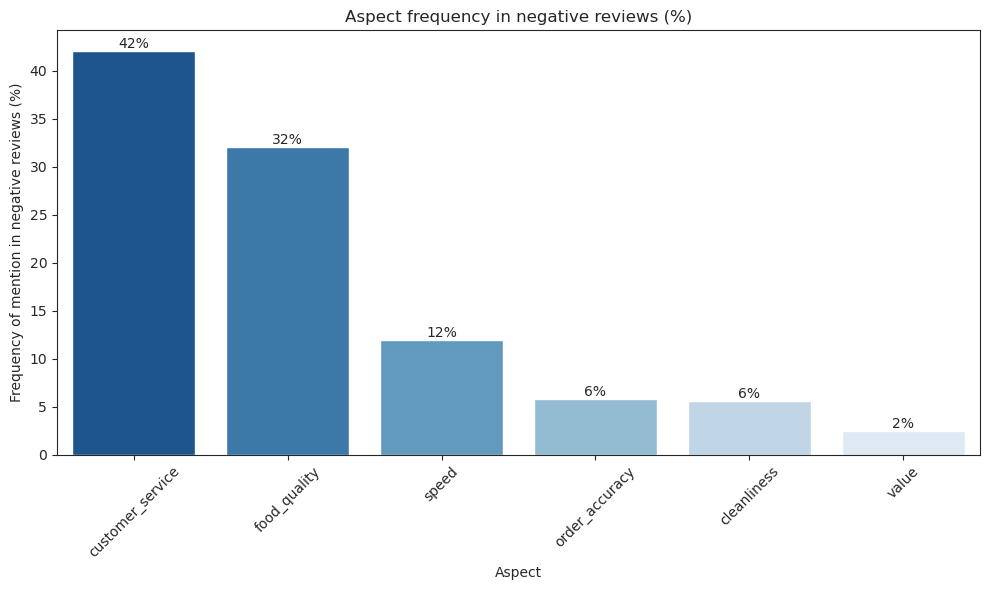

In [176]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=freq, x="aspect", y="percent", palette='Blues_r', hue='aspect', legend=False)

# Add labels on top of each bar
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.0f}%",                    
        (p.get_x() + p.get_width() / 2, value),
        ha="center", va="bottom",
        fontsize=10)

plt.title("Aspect frequency in negative reviews (%)")
plt.ylabel("Frequency of mention in negative reviews (%)")
plt.xlabel("Aspect")
plt.xticks(rotation=45)
plt.tight_layout()

# Download chart
plt.savefig('Most frequent aspects',bbox_inches="tight")

plt.show()


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

"Customer service" quality is mentioned the most in negative reviews. <br>
Second is "Food Quality". 
<br> "Value" for money is mentioned the least.

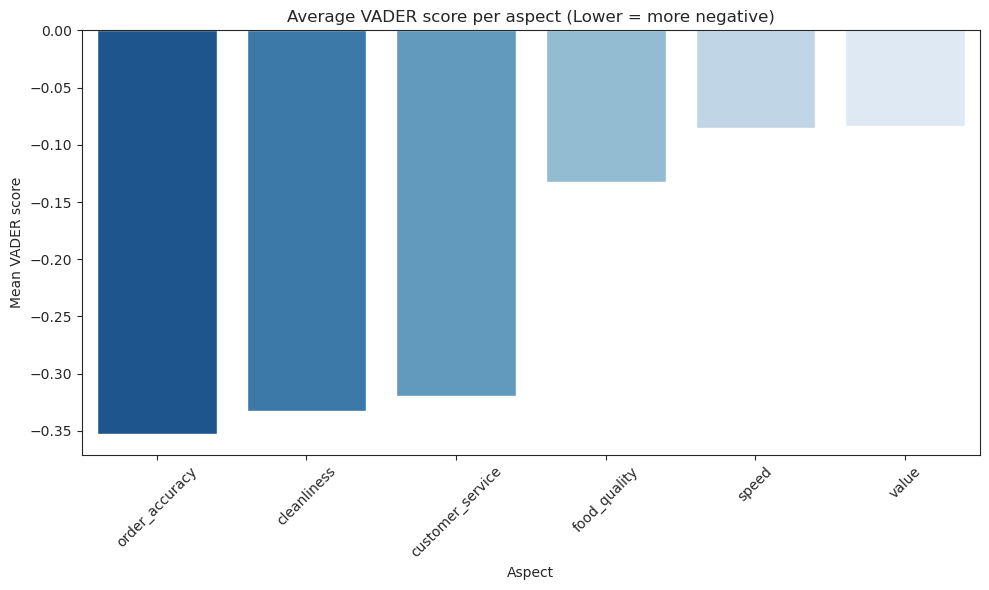

In [177]:
# Average VADER score per aspect
# What do customers feel the most negative about
avg_vader = (
    aspect_df.groupby("aspect")["vader"]
    .mean()
    .reset_index()
    .sort_values("vader"))

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_vader, x="aspect", y="vader", palette='Blues_r', hue="aspect",legend=False)
plt.title("Average VADER score per aspect (Lower = more negative)")
plt.ylabel("Mean VADER score")
plt.xlabel("Aspect")
plt.xticks(rotation=45)
plt.tight_layout()

# Download chart
plt.savefig('Average VADER score by aspect',bbox_inches="tight")

plt.show()


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

- Primary Pain Points: Customers express the harshest negative sentiment when discussing "**Order Accuracy**" and "**Cleanlines** ;
- Secondary Friction: "**Customer Service**" also tracks heavily negative ;
- Least Severe Negative Scores: Interestingly, "**Food Quality**", "**Value**", and "**Speed**" exhibit the mildest negative scores in this subset.

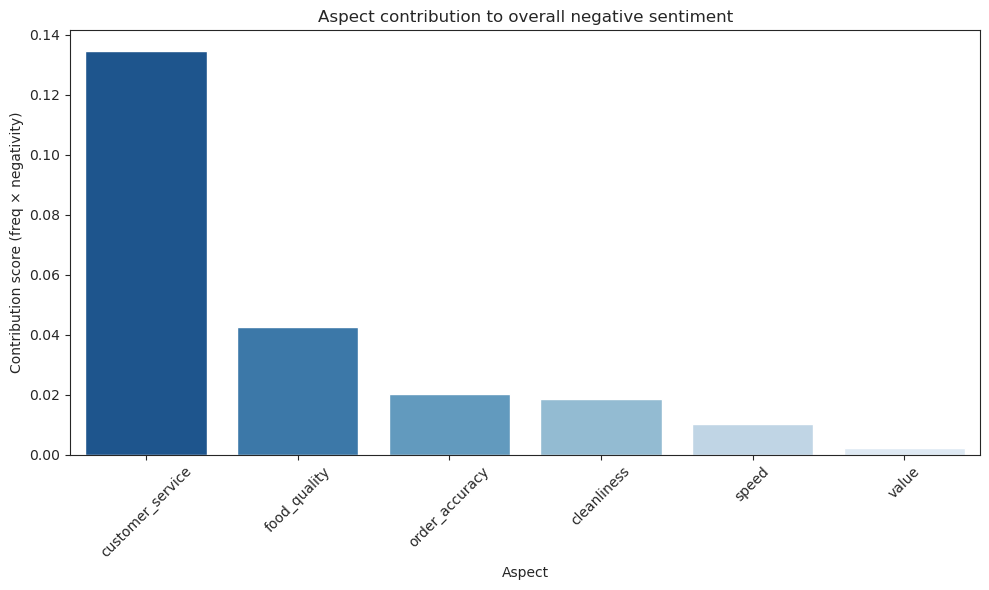

In [178]:
# What aspect drives overall negativity the most (overall vader score)
# Frequency X mean vader score of each aspect
# Not using correlation matrix as it doesn't take into account frequency.

freq = aspect_df["aspect"].value_counts(normalize=True)

# Negativity (invert VADER so more negative = higher contribution)
neg = -aspect_df.groupby("aspect")["vader"].mean()

# Contribution score
contrib = (freq * neg).reset_index()
contrib.columns = ["aspect", "contribution"]
contrib = contrib.sort_values("contribution", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=contrib, x="aspect", y="contribution", palette='Blues_r', hue="aspect",legend=False)
plt.title("Aspect contribution to overall negative sentiment")
plt.ylabel("Contribution score (freq × negativity)")
plt.xlabel("Aspect")
plt.xticks(rotation=45)
plt.tight_layout()

# Download chart
plt.savefig('Aspect contribution',bbox_inches="tight")

plt.show()


<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

Here we multiply Frequency by Severity (Sentiment Score), it tells us how intense a complaint is (*a customer might forgive a slightly messy table or a forgotten order if the staff handles it beautifully.*)
- While the previous chart showed that "order accuracy" was the most severely negative aspect when it happened, 
- This one reveals that "**customer service**" is what actually damages the brand the most overall due to its sheer volume.

<h3 style="color:#475569;"> <i> What is the root cause theme of underperforming QSRs (negative VADER)</i></h3>   

In [179]:
# Underperforming QSRs
target_ids = [
    "TfS4WxvQaQ96ts6fprfH0Q",
    "KwWmZOV6q6GTva8j6h05Nw",
    "H2jXjqiq7MkhZHg8H6nc1Q",
    "ep9S1yrEiSo_WxXbTSPjkA",
    "pL4OBJSskWnhtu811wgpTw",
    "Si8GQOgALsPdZiudT6WszQ",
    "FYIAXtgq-OuT7kYR-TFNJQ",
    "hDGYyMhYXGXfEZmFJgLqdA"]

# Filter to the underperforming QSRs
root_cause = aspect_summary[aspect_summary["BUSINESS_ID"].isin(target_ids)].copy()

# Combine the columns related to business into a new column called 'DISPLAY_NAME'
root_cause['DISPLAY_NAME'] = root_cause['BUSINESS_NAME'] + ' (' + root_cause['BUSINESS_STATE_FULL_NAME'] + ')'


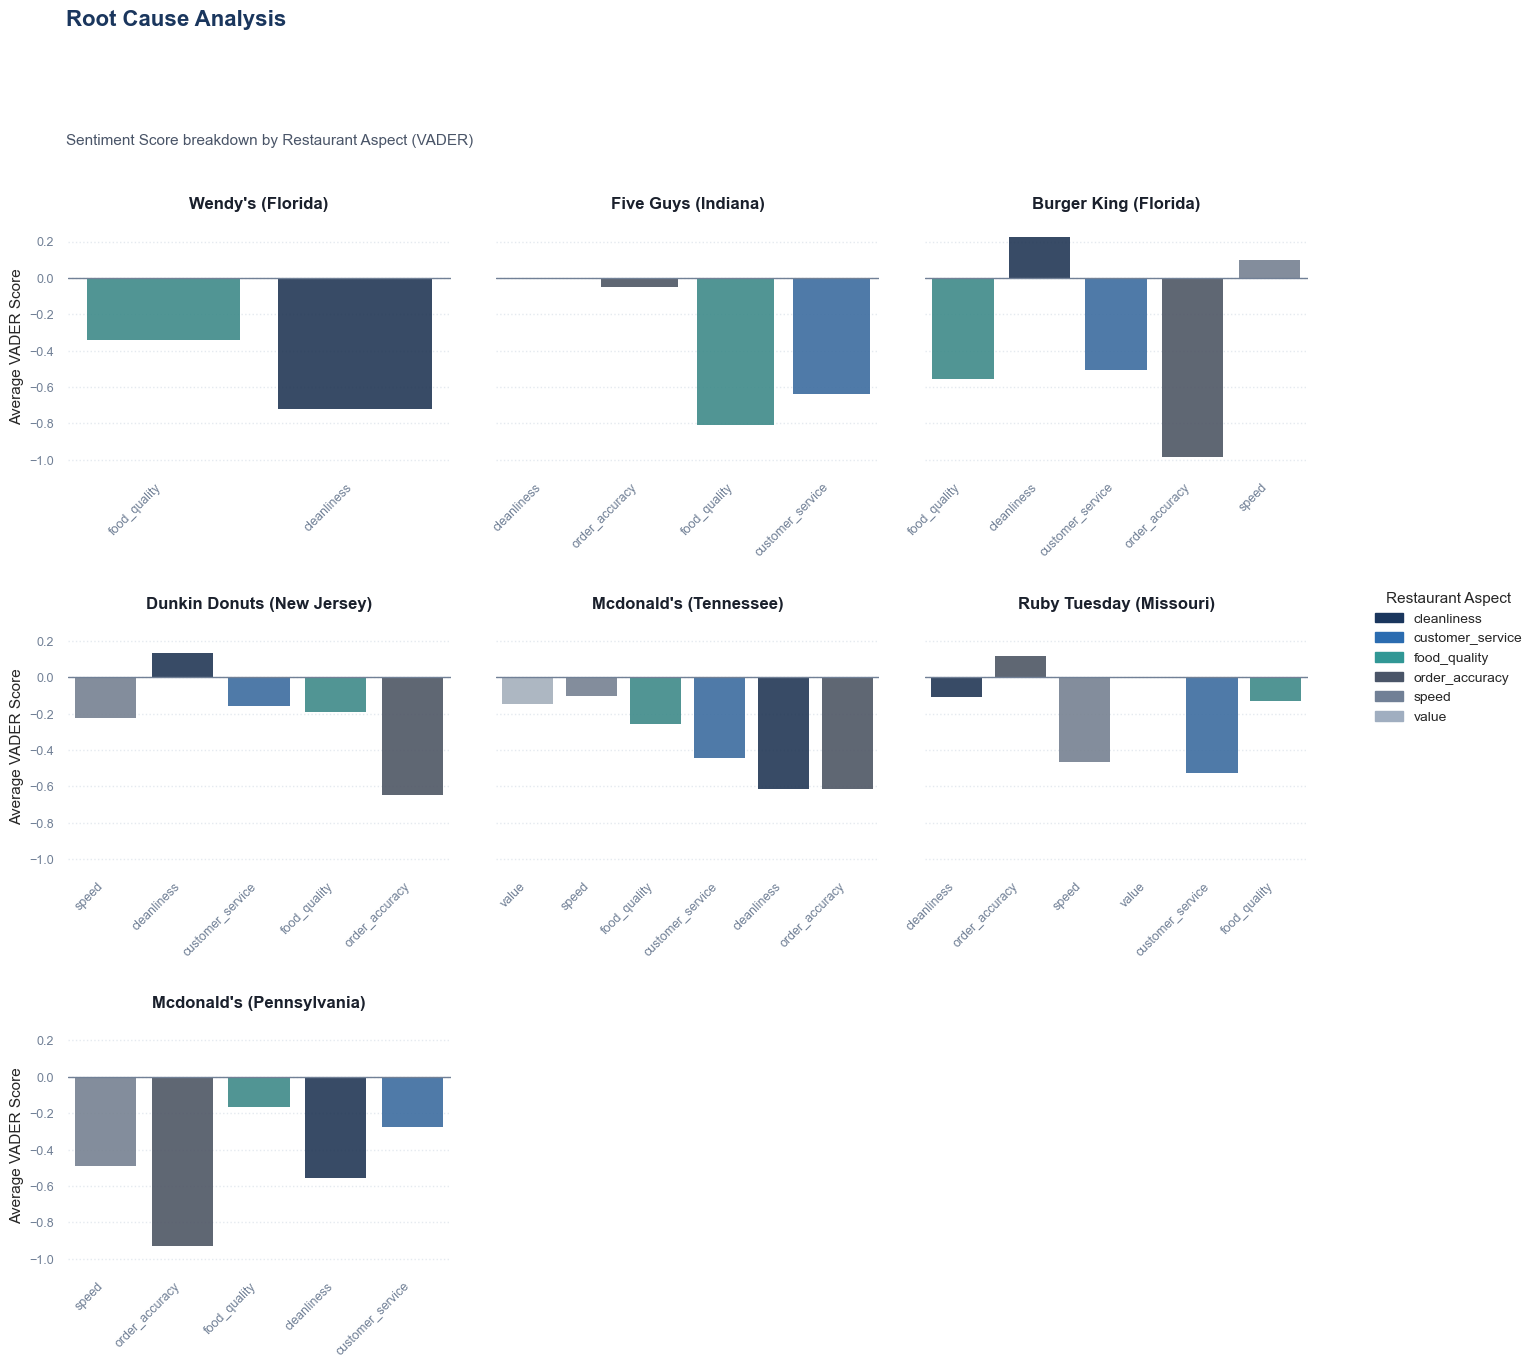

In [180]:
# Plot the result
# Set style for a cleaner look
sns.set_theme(style="whitegrid")

# Create small multiples/facets per restaurant
g = sns.FacetGrid(
    root_cause, 
    col="DISPLAY_NAME", 
    col_wrap=3, 
    sharex=False, 
    height=4.5, 
    aspect=1.0
)

# Create an explicit dictionary mapping each aspect to a strict, permanent color
unique_aspects = sorted(root_cause["aspect"].unique())
modern_palette = ["#1A365D", "#2B6CB0", "#319795", "#4A5568", "#718096", "#A0AEC0"]
color_map = dict(zip(unique_aspects, modern_palette[:len(unique_aspects)]))


# Map a bar plot to each facet
g.map_dataframe(
    sns.barplot, 
    x="aspect", 
    y="aspect_vader", 
    hue="aspect", 
    palette=color_map,       
    hue_order=unique_aspects, 
    errorbar=None,
    linewidth=0,
    alpha=0.9,
    legend=False
)

# Clean up axes and titles
g.set_axis_labels("", "Average VADER Score", fontsize=11, fontweight='medium')

# Polishing individual subplots
for ax in g.axes.flat:
    # Clean up title formatting string pulled from column configuration
    raw_title = ax.get_title().split('=')[-1].strip()
    ax.set_title(raw_title, fontsize=12, fontweight='bold', pad=12, color='#1A202C')
    
    # Structural guidelines
    ax.axhline(0, color='#718096', linewidth=1, linestyle='-') 
    ax.grid(axis='y', linestyle=':', alpha=0.5, color='#CBD5E0')
    
    # Prevent text clipping on long labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9, color='#4A5568')
    ax.tick_params(colors='#718096', labelsize=9)
    
    # Strip unnecessary enclosing borders
    sns.despine(ax=ax, left=True, bottom=True)

# Build and place a global legend using our color mapping
legend_handles = [
    mpatches.Patch(color=color_map[aspect], label=aspect) 
    for aspect in unique_aspects
]

g.figure.legend(
    handles=legend_handles,
    title="Restaurant Aspect",
    title_fontsize=11,
    fontsize=10,
    loc="center left", 
    bbox_to_anchor=(1.02, 0.5), 
    frameon=False               
)

# hspace adds vertical padding between the rows of subplots
plt.subplots_adjust(top=0.82, hspace=0.65) 

# Main Titles
g.figure.suptitle(
    "Root Cause Analysis\n", 
    fontsize=16, 
    fontweight='bold', 
    color='#1A365D',
    x=0.06,          
    ha='left'
)
g.figure.text(
    0.06, 0.88, 
    "Sentiment Score breakdown by Restaurant Aspect (VADER)", 
    fontsize=11, 
    color='#4A5568', 
    ha='left'
)

# Save the polished visualization
plt.savefig('Aspect_by_QSR_Facetted.png', dpi=300, bbox_inches="tight")
plt.show()

<h3 style="color:#475569;"> <i> Interpretation</i></h3>   

We can identify the specific catalyst dragging down each location's reputation:
* <i><u>The Order Accuracy Crisis</u></i>:
  - **Burger King (Florida)** and **McDonald's (Pennsylvania)** are suffering from catastrophic failures in order_accuracy.
  - **Dunkin Donuts (New Jersey)** shares a similar major deficit primarily in order_accuracy.
<br>
  
* <i><u>The Product Quality Outliers</u></i>:
  - **Subway (Alberta)** does not have a product issue—it has an execution and service issue. Because food_quality is actively praised,
<br>
 
* <i><u>The Sanitation Failures</u></i>:
  - **Wendy's (Florida)** and **McDonald's (Tennessee)** have severe negative spikes in cleanliness. For Wendy's (Florida), hygiene appears to be the single most dominating complaint in their negative review profile.
<br>
 
* <i><u>Service and Speed Bottlenecks</u></i>:
  - **Ruby Tuesday (Missouri)** their deepest pain points are customer_service  and speed.

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
6.2.3 Write the dataframe back to Snowflake
</h1>

</div>


In [181]:
# --- 1. TRANSFORM THE DATAFRAME ---

# Pivot the aspect rows into separate columns
aspect_pivoted = aspect_summary.pivot_table(
    index=["BUSINESS_ID", "BUSINESS_NAME", "BUSINESS_STATE_FULL_NAME", "overall_vader", "vader_rank"],
    columns="aspect",
    values="aspect_vader"
).reset_index()

# Clean up the multi-index column name attribute left by pivot_table
aspect_pivoted.columns.name = None


# FORCE ALL HEADERS TO CAPITAL LETTERS
aspect_pivoted.columns = aspect_pivoted.columns.str.upper()


#aspect_pivoted.head(20)


In [182]:
# --- 2. CONNECT AND EXPORT TO SNOWFLAKE ---

cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_NLP_ROOT_CAUSE_THEMES
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    aspect_pivoted,
    table_name="QSR_NLP_ROOT_CAUSE_THEMES",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  7800


---

<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Summary of findings</u>
</h3>

<p>

 - **Customer Service came out as the top complaint** among all reviews, followed by Food Quality, then Speed. These findings suggest that many QSRs are falling short in meeting customer service expectations, which in turn may have a negative effect on customer loyalty.
 - The final scorecard will highlight the top service issue for the selected franchise, broken down per location. In this way, **QSR managers can use the scorecard to make swift internal changes**; for example, if customer service is the main issue, managers may decide to offer more staff training, reduce shift hours etc. 

</p>

</li>

</ol>

</div>

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
7. SNOWFLAKE FEATURE MERGING STEP
</h1>

</div>

<div style="
    background-color:#F0FDF4;
    border-left:6px solid #10B981;
    padding:18px;
    border-radius:8px;
    margin-top:15px;
    margin-bottom:20px;
">

<h3 style="color:#065F46; margin-top:0;">
<u>Data Integration Process</u>
</h3>

<p>
Prior to executing the final QSR Health Index scoring framework, a critical consolidation phase is performed directly within Snowflake. 
<br>
The previously exported DataFrames are uploaded as database tables and integrated via a <code>LEFT JOIN</code>. This merging step consolidates:
</p>

<ul>
    <li>REPUTATION_LEVEL</li>
    <li>REVIEW_ENGAGEMENT</li>
    <li>RECENCY_WEIGHTED_RISK</li>
    <li>ROOT_CAUSE_THEMES (NLP)</li>
    <li>OPERATIONAL_PROFILE</li>
</ul>

<p>
The integration process created a final consolidated analytical view:
</p>

<p style="
    font-size:18px;
    font-weight:bold;
    color:#1F4E79;
">
STG_QSR_ANALYTICS_FULL
</p>

<p style="color: darkslategray;">
  <i>(This final Snowflake view acts as the central modelling and scoring layer used for below Health Index calculation and business risk segmentation.)</i>
</p>

</div>

---

### 

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
8. QSR HEALTH INDEX <br>
(SCORING)
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
    
- This section combines the scores from the previous key features, resulting in a final **QSR Location Health Index Scorecard**.
- Weights assigned:
* 🟨 RECENCY_WEIGHTED_RISK **25%**
* 🟥 ROOT_CAUSE_THEMES (NLP) **25%**
* 🟦 REPUTATION_LEVEL **20%**
* 🟩 REVIEW_ENGAGEMENT **15%**
* 🟪 OPERATIONAL_PROFILE **15%**
> External research informed the corresponding feature weights:
> - In particular, research suggests that food quality, customer service and cleanliness are some of the most important features that influence how customers perceive a QSR [(Performance in People)](https://www.performanceinpeople.co.uk/blog/research-study-quick-service-restaurants-the-7-key-factors-influencing-the-customer-experience). **Root cause themese** should therefore have the highest weighting.
> - **Recency-weighted risk** is a clear trigger that immediate action is necessary, and has therefore been weighted similarly to root-cause themes.
> - **Reputation level** has received the second highest weighting. Whilst not as urgent as recency weighted risk, a low reputation level can deter customers, and is therefore an important factor.
> - **Review enegagement** and the **operational profile** have received the lowest overall weighting; deemed less urgent compared to the other features. 
- The scores were log transformed to normalise the data and reduce skewness.
- MinMaxScaler was then applied to ensure that every variable is strictly bound to 0-1.
- The final scorecard allows QSRs to compare franchise performance across different locations, enabling swift responses to customer pain points. 

</p>

</li>

</ol>

</div>

---

In [216]:
# =========================================
# Load dataset from Snowflake
# =========================================

# Connect to Snowflake, create dataframe with SQL queries, 
analytics_full = pd.read_sql("SELECT * FROM LSE_YELP_TEAMS_DB.TEAM_15.STG_QSR_ANALYTICS_FULL", conn)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [217]:
# Keep only required columns
analytics_full_subset = analytics_full[[
    "BUSINESS_ID",
    "BUSINESS_NAME",
    "BUSINESS_CITY",
    "AVERAGE_STAR_RATING",
    "VARIABILITY_SCORE",
    "REVIEW_COUNT_PERIOD",
    "TREND_SLOPE",
    "NEGATIVE_SPIKE_SCORE",
    "RECENCY_WEIGHTED_AVG_STARS",
    "CLEANLINESS",
    "CUSTOMER_SERVICE",
    "FOOD_QUALITY",
    "ORDER_ACCURACY",
    "SPEED",
    "VALUE",
    "HAS_VADER_RATING",
    "INVERTED_HOUR_CONSISTENCY",
    "ATTRIBUTE_SCORING"
]].copy()


In [218]:
# remove duplicates
analytics_full_subset = analytics_full_subset.drop_duplicates(
    subset=["BUSINESS_ID"]
)

In [219]:
data_valid(analytics_full_subset)


Missing Values (per column):
BUSINESS_ID                   0
BUSINESS_NAME                 0
BUSINESS_CITY                 0
AVERAGE_STAR_RATING           0
VARIABILITY_SCORE             0
REVIEW_COUNT_PERIOD           0
TREND_SLOPE                   0
NEGATIVE_SPIKE_SCORE          0
RECENCY_WEIGHTED_AVG_STARS    0
CLEANLINESS                   0
CUSTOMER_SERVICE              0
FOOD_QUALITY                  0
ORDER_ACCURACY                0
SPEED                         0
VALUE                         0
HAS_VADER_RATING              0
INVERTED_HOUR_CONSISTENCY     0
ATTRIBUTE_SCORING             0
dtype: int64

Unique Values (per column):
BUSINESS_ID                   18000
BUSINESS_NAME                  9835
BUSINESS_CITY                   665
AVERAGE_STAR_RATING            4204
VARIABILITY_SCORE                 2
REVIEW_COUNT_PERIOD             435
TREND_SLOPE                    1167
NEGATIVE_SPIKE_SCORE              1
RECENCY_WEIGHTED_AVG_STARS    17121
CLEANLINESS                 

In [220]:
analytics_full_subset.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,AVERAGE_STAR_RATING,VARIABILITY_SCORE,REVIEW_COUNT_PERIOD,TREND_SLOPE,NEGATIVE_SPIKE_SCORE,RECENCY_WEIGHTED_AVG_STARS,CLEANLINESS,CUSTOMER_SERVICE,FOOD_QUALITY,ORDER_ACCURACY,SPEED,VALUE,HAS_VADER_RATING,INVERTED_HOUR_CONSISTENCY,ATTRIBUTE_SCORING
0,3_WGRjRrnZX2b4ZVpjmL6w,Arnold's Country Kitchen,Nashville,4.377246,1,334,0.1051,1,4.257914,0.00000,0.00,0.000000,0.0000,0.000000,0.0000,N,0.32,10
1,JsUWxd9KwOvuq_Im8DZfEw,Johnny Rockets,Tampa,2.681818,0,22,-0.0000,1,2.175886,-0.40264,-0.05,-0.010075,-0.5267,-0.173425,0.3612,Y,1.06,8
2,u40qery_d1rwMwOprqCfKw,Big Ez Seafood,Gretna,4.250000,1,216,0.0381,1,4.134109,0.00000,0.00,0.000000,0.0000,0.000000,0.0000,N,0.81,9
3,_1JmbxhyiTXO_CDytQTkgA,Ike's Sandwiches,Reno,4.236181,1,199,-0.0000,1,4.108851,0.00000,0.00,0.000000,0.0000,0.000000,0.0000,N,0.17,9
4,vT1zrTTIji2JDhUHjFKopg,Laurel Street Bakery,New Orleans,4.279412,1,68,-0.0000,1,4.503874,0.00000,0.00,0.000000,0.0000,0.000000,0.0000,N,10.00,8


<h3 style="color:#475569;"> <i> Get stats on numerical columns</i></h3>   

In [221]:
analytics_full_subset.describe().T

,count,mean,std,min,25%,50%,75%,max
AVERAGE_STAR_RATING,18000.0,3.242973,1.133031,0.0000,2.343750,3.470588,4.181818,5.0000
VARIABILITY_SCORE,18000.0,0.632056,0.482260,0.0000,0.000000,1.000000,1.000000,1.0000
REVIEW_COUNT_PERIOD,18000.0,38.684167,71.808619,1.0000,8.000000,17.000000,40.000000,2271.0000
TREND_SLOPE,18000.0,0.051731,0.344468,-1.0286,-0.000000,-0.000000,0.142900,1.2857
NEGATIVE_SPIKE_SCORE,18000.0,1.000000,0.000000,1.0000,1.000000,1.000000,1.000000,1.0000
RECENCY_WEIGHTED_AVG_STARS,18000.0,3.236306,1.147938,1.0000,2.271625,3.457938,4.209426,5.0000
CLEANLINESS,18000.0,-0.084207,0.209154,-0.9869,0.000000,0.000000,0.000000,0.8741
CUSTOMER_SERVICE,18000.0,-0.123788,0.213300,-0.9958,-0.264002,0.000000,0.000000,0.8779
FOOD_QUALITY,18000.0,-0.058677,0.160253,-0.9835,-0.067516,0.000000,0.000000,0.8519
ORDER_ACCURACY,18000.0,-0.108525,0.216172,-0.9876,0.000000,0.000000,0.000000,0.8907


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
8.1.1 Check skewness of those columns
</h1>

</div>


<h3 style="color:#475569;"> <i> Why ?</i></h3>   

=> Identify which features have non-normal distributions that might need transformation (like log scaling)

In [222]:
skew = analytics_full_subset.skew(numeric_only=True)

skew.sort_values(ascending=False)

REVIEW_COUNT_PERIOD           9.011386
INVERTED_HOUR_CONSISTENCY     0.989005
TREND_SLOPE                   0.581549
NEGATIVE_SPIKE_SCORE          0.000000
RECENCY_WEIGHTED_AVG_STARS   -0.365817
AVERAGE_STAR_RATING          -0.527943
VARIABILITY_SCORE            -0.547714
ATTRIBUTE_SCORING            -0.859657
CUSTOMER_SERVICE             -1.077663
ORDER_ACCURACY               -1.565313
FOOD_QUALITY                 -1.580417
CLEANLINESS                  -1.767170
VALUE                        -1.941910
SPEED                        -1.984035
dtype: float64

<h3 style="color:#475569;"> <i> Interpretation</i></h3>  

|Skew value|	Meaning	|Action|
|-----|-----|-----|
|> 2	|very skewed	|log transform|
|1–2	|moderately skewed	|consider log|
|~0	|normal	|no log|
|negative	|left-skewed	|usually skip|

<h3 style="color:#475569;"> <i> Decision on log-transformation</i></h3>  

In [223]:
analytics_df = analytics_full_subset.copy()

analytics_skewness = analytics_df.skew(numeric_only=True)

skew_candidates = analytics_skewness[analytics_skewness.abs() > 1].index

def is_bounded(col):
    return (
        analytics_df[col].max() <= 10 and
        analytics_df[col].min() >= 0 and
        analytics_df[col].nunique() < 50
    )

log_transform_columns = [
    col for col in skew_candidates
    if (
        analytics_df[col].min() >= 0
        and analytics_df[col].max() > 50   # key fix: ensures it's not bounded scale
    )
]

print("\ncolumns to log-transform:\n", log_transform_columns)


columns to log-transform:
 ['REVIEW_COUNT_PERIOD']


<i> We create new columns suffixed _LOG (This is much safer) </i>

In [224]:
for col in log_transform_columns:
    analytics_full_subset[col + '_LOG'] = np.log1p(analytics_full_subset[col])

<h3 style="color:#475569;"> <i> Check skewness after log-transformation on <b><u>all columns</u></b></i></h3>   

In [225]:
before_skew = analytics_full_subset[log_transform_columns].skew()

log_cols_transformed = [c + '_LOG' for c in log_transform_columns]
after_skew = analytics_full_subset[log_cols_transformed].skew()

after_skew.index = log_transform_columns

comparison = pd.DataFrame({
    "skewness before": before_skew,
    "skewness after": after_skew
})

comparison

,skewness before,skewness after
REVIEW_COUNT_PERIOD,9.011386,0.420619


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
8.1.2 Apply MinMax scaling
</h1>

</div>


<div style="
    background-color: #f8fafc;
    border-left: 4px solid #64748b;
    padding: 20px;
    border-radius: 8px;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
    box-shadow: 0 1px 3px 0 rgba(0, 0, 0, 0.05);
">
    <h3 style="color: #334155; margin-top: 0; font-weight: 600; letter-spacing: -0.025em; margin-bottom: 12px;">
        Why?
    </h3>
    <p style="color: #475569; font-size: 0.95em; line-height: 1.5; margin-bottom: 0;">
        <strong>Easier interpretation:</strong>
        <ul style="color: #475569; font-size: 0.95em; line-height: 1.5; margin-top: 6px; margin-bottom: 12px; padding-left: 20px;">
            <li>0 = weakest</li>
            <li>1 = strongest</li>
        </ul>
        Good for business scoring systems.
    </p>
</div>

In [226]:
# keep only numeric columns
numeric_cols = analytics_full_subset.select_dtypes(include=np.number).columns

# remove obvious bad columns to be safe
exclude_cols = [
    "BUSINESS_ID"
]

candidate_features = [c for c in numeric_cols if c not in exclude_cols]

#display
candidate_features

['AVERAGE_STAR_RATING',
 'VARIABILITY_SCORE',
 'REVIEW_COUNT_PERIOD',
 'TREND_SLOPE',
 'NEGATIVE_SPIKE_SCORE',
 'RECENCY_WEIGHTED_AVG_STARS',
 'CLEANLINESS',
 'CUSTOMER_SERVICE',
 'FOOD_QUALITY',
 'ORDER_ACCURACY',
 'SPEED',
 'VALUE',
 'INVERTED_HOUR_CONSISTENCY',
 'ATTRIBUTE_SCORING',
 'REVIEW_COUNT_PERIOD_LOG']

In [227]:
#MinMaxScaling
scaler = MinMaxScaler()

scaled_matrix = scaler.fit_transform(
    analytics_full_subset[numeric_cols].astype(float)
)

scaled_analytics = pd.DataFrame(
    scaled_matrix,
    columns=numeric_cols,
    index=analytics_full_subset.index
)

# display result
scaled_analytics

,AVERAGE_STAR_RATING,VARIABILITY_SCORE,REVIEW_COUNT_PERIOD,TREND_SLOPE,NEGATIVE_SPIKE_SCORE,RECENCY_WEIGHTED_AVG_STARS,CLEANLINESS,CUSTOMER_SERVICE,FOOD_QUALITY,ORDER_ACCURACY,SPEED,VALUE,INVERTED_HOUR_CONSISTENCY,ATTRIBUTE_SCORING,REVIEW_COUNT_PERIOD_LOG
0,0.875449,1.0,0.146696,0.489867,0.0,0.814479,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,0.032,1.0,0.727902
1,0.536364,0.0,0.009251,0.444454,0.0,0.293971,0.313949,0.504777,0.530361,0.245381,0.441056,0.709798,0.106,0.8,0.347158
2,0.850000,1.0,0.094714,0.460917,0.0,0.783527,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,0.081,0.9,0.666179
3,0.847236,1.0,0.087225,0.444454,0.0,0.777213,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,0.017,0.9,0.654583
4,0.855882,1.0,0.029515,0.444454,0.0,0.875968,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,1.000,0.8,0.503315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775985,0.300000,1.0,0.000441,0.444454,0.0,0.080925,0.530306,0.115493,0.520118,0.198957,0.533797,0.520042,1.000,0.5,0.057633
776460,0.000000,0.0,0.000000,0.444454,0.0,1.000000,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,0.000,0.6,0.000000
782271,0.000000,0.0,0.000000,0.444454,0.0,0.000000,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,1.000,0.6,0.000000
785247,0.000000,0.0,0.000000,0.444454,0.0,0.000000,0.530306,0.531462,0.535850,0.525795,0.533797,0.520042,0.000,0.0,0.000000


In [228]:
scaled_analytics.describe().T

,count,mean,std,min,25%,50%,75%,max
AVERAGE_STAR_RATING,18000.0,0.648595,0.226606,0.0,0.468750,0.694118,0.836364,1.0
VARIABILITY_SCORE,18000.0,0.632056,0.482260,0.0,0.000000,1.000000,1.000000,1.0
REVIEW_COUNT_PERIOD,18000.0,0.016601,0.031634,0.0,0.003084,0.007048,0.017181,1.0
TREND_SLOPE,18000.0,0.466807,0.148843,0.0,0.444454,0.444454,0.506201,1.0
NEGATIVE_SPIKE_SCORE,18000.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
RECENCY_WEIGHTED_AVG_STARS,18000.0,0.559076,0.286984,0.0,0.317906,0.614485,0.802356,1.0
CLEANLINESS,18000.0,0.485058,0.112388,0.0,0.530306,0.530306,0.530306,1.0
CUSTOMER_SERVICE,18000.0,0.465395,0.113839,0.0,0.390563,0.531462,0.531462,1.0
FOOD_QUALITY,18000.0,0.503881,0.087312,0.0,0.499065,0.535850,0.535850,1.0
ORDER_ACCURACY,18000.0,0.468017,0.115089,0.0,0.525795,0.525795,0.525795,1.0


<div style="
    background-color: #f8fafc;
    border-left: 4px solid #64748b;
    padding: 20px;
    border-radius: 8px;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
    box-shadow: 0 1px 3px 0 rgba(0, 0, 0, 0.05);
">
    <h3 style="color: #334155; margin-top: 0; font-weight: 600; letter-spacing: -0.025em; margin-bottom: 12px;">
        Feature Scaling: MinMaxScaler Normalization
    </h3>
    <p style="color: #475569; font-size: 0.95em; line-height: 1.5; margin-bottom: 0;">
        <strong>Current Stage:</strong> Features have been successfully converted into a normalized scale using <code>MinMaxScaler</code>. <br><br>
        This transformation ensures that:
        <ul style="color: #475569; font-size: 0.95em; line-height: 1.5; margin-top: 6px; margin-bottom: 0; padding-left: 20px;">
            <li style="margin-bottom: 6px;">Every variable is bound strictly between 0 and 1.</li>
            <li style="margin-bottom: 6px;">All variables and features become directly comparable, completely independent of their original units or starting magnitude.</li>
            <li style="margin-bottom: 6px;">No single feature dominates the model simply due to larger numeric baselines (e.g., comparing raw review counts against 1-5 star ratings).</li>
            <li style="margin-bottom: 0;">Each feature contributes fairly and proportionally when computing the final downstream Health Index.</li>
        </ul>
    </p>
</div>

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
8.1.3 Health index calculation
</h1>

</div>


<h1 style="color:#0F766E;"><b> 8.2 <u>Health index (no weight)</b></u></h2>

#### The next step is to use above "scaled_analytics" to build our **Health Index**.

$HealthIndex = \frac{x_1 + x_2 + \dots + x_n}{n}$

where:
* *$x_i$* being each feature,
* *$n$* total nb of features

<u>What it does?</u>

=>for each business, the Health Index:
* combines all normalized (0–1) metrics
* computes their average
* produces a single composite score
* is typically rescaled to a 0–100 range for interpretability

In [229]:
analytics_full_subset['HEALTH_INDEX_NO_WEIGHT'] = (
    scaled_analytics.mean(axis=1)
) * 100

In [230]:
analytics_full_subset.head(20)

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,AVERAGE_STAR_RATING,VARIABILITY_SCORE,REVIEW_COUNT_PERIOD,TREND_SLOPE,NEGATIVE_SPIKE_SCORE,RECENCY_WEIGHTED_AVG_STARS,CLEANLINESS,CUSTOMER_SERVICE,FOOD_QUALITY,ORDER_ACCURACY,SPEED,VALUE,HAS_VADER_RATING,INVERTED_HOUR_CONSISTENCY,ATTRIBUTE_SCORING,REVIEW_COUNT_PERIOD_LOG,HEALTH_INDEX_NO_WEIGHT
0,3_WGRjRrnZX2b4ZVpjmL6w,Arnold's Country Kitchen,Nashville,4.377246,1,334,0.1051,1,4.257914,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,0.32,10,5.814131,55.090964
1,JsUWxd9KwOvuq_Im8DZfEw,Johnny Rockets,Tampa,2.681818,0,22,-0.0000,1,2.175886,-0.40264,-0.050000,-0.010075,-0.526700,-0.173425,0.361200,Y,1.06,8,3.135494,35.216804
2,u40qery_d1rwMwOprqCfKw,Big Ez Seafood,Gretna,4.250000,1,216,0.0381,1,4.134109,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,0.81,9,5.379897,53.423928
3,_1JmbxhyiTXO_CDytQTkgA,Ike's Sandwiches,Reno,4.236181,1,199,-0.0000,1,4.108851,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,0.17,9,5.298317,52.699755
4,vT1zrTTIji2JDhUHjFKopg,Laurel Street Bakery,New Orleans,4.279412,1,68,-0.0000,1,4.503874,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,10.00,8,4.234107,57.909252
5,ZN688ReGphfv8WjLHNN5WQ,Abc Pizza International,Land O Lakes,3.000000,0,44,-0.4143,1,3.334728,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,10.00,8,3.806662,45.919143
6,U5_T9hDfdYFWS8ahj_1Dvw,Just Salad,Philadelphia,2.952381,0,84,-0.3143,1,2.602763,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,0.14,9,4.442651,39.737248
7,OBHirkn1QCd7rsYHYtSdwQ,Sopapilla's,Franklin,3.921630,1,319,-0.0286,1,3.906210,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,1.59,10,5.768321,54.271366
8,I13HqIkWfR6CydGbo9xv0A,Haze Ice Cream,Madeira Beach,4.642857,1,196,-0.0095,1,4.555825,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,N,0.16,9,5.283204,53.929780
9,6rRGA1V-mLl7f2BqqZ_AmA,Steak 'n Shake,Clearwater,2.105263,1,57,0.4571,1,2.359785,-0.50540,-0.282727,-0.174869,-0.354020,-0.161539,-0.060875,Y,10.00,9,4.060443,47.726199


<h3 style="color:#475569;"> <i> Note </i></h3>  

 ⚠️ Right now, every variable/feature contributes equally, because 
$HealthIndex = \frac{x_1 + x_2 + \dots + x_n}{n}$

Next step is to set a weight on the different features

#

<h1 style="color:#0F766E;"><b> 8.3 <u>Health index (weighted)</b></u></h2>

<i> Note: Total weight should be = 1 (100%) <i>

Here is the algorithm / rule that we are going to apply 
* 🟦 REPUTATION_LEVEL **20%**
* 🟩 REVIEW_ENGAGEMENT **15%**
* 🟨 RECENCY_WEIGHTED_RISK **25%**
* 🟥 ROOT_CAUSE_THEMES (NLP) **25%**
* 🟪 OPERATIONAL_PROFILE **15%**

|Group|Field|Desc|%|Standard|
|----|----|----|----|----|
|🟦 REPUTATION_LEVEL|AVERAGE_STAR_RATING|average star rating|10.0%|(0 = Bad, 1 = Good)|
||STANDARD_DEVIATION|rating_distribution|10.0%|(0 = Bad, 1 = Good)|
|🟩 REVIEW_ENGAGEMENT|REVIEW_COUNT_PERIOD|review_volume|7.5%|(0 = Bad, 1 = Good)|
||TREND_SLOPE|trends last 6 months|7.5%|(0 = Bad, 1 = Good)|
|🟨 RECENCY_WEIGHTED_RISK|NEGATIVE_SPIKE_SCORE|detection of negative spikes |10.0%| (0 = Bad [spikes], 1 = Good[no-spike])|
||RECENCY_WEIGHTED_AVG_STARS|recency-weighted average rating|15.0%|(0 = Bad, 1 = Good)|
|🟥 ROOT_CAUSE_THEMES (NLP)|SPEED|speed / wait time |4.0%|(0 = Bad, 1 = Good)|
||ORDER_ACCURACY|order accuracy|5.0%|(0 = Bad, 1 = Good)|
||CUSTOMER_SERVICE|staff friendliness|4.0%|(0 = Bad, 1 = Good)|
||CLEANLINESS|cleanliness|2.0%|(0 = Bad, 1 = Good)|
||VALUE|value / price|5.0%|(0 = Bad, 1 = Good)|
||FOOD_QUALITY|food temperature / quality|5.0%|(0 = Bad, 1 = Good)|
|🟪 OPERATIONAL_PROFILE|INVERTED_HOUR_CONSISTENCY|opening hours consistency|7.5%| (0 = Bad, 1 = Good) |
||ATTRIBUTE_SCORING|relevant operational attributes|7.5%| (0 = Bad, 1 = Good)|

## Compute weighted Health Index

In [231]:
analytics_full_subset['WEIGHTED_HEALTH_INDEX'] = (
    # 🟦 REPUTATION_LEVEL
    0.10 * analytics_full_subset['AVERAGE_STAR_RATING'] +
    0.10 * analytics_full_subset['VARIABILITY_SCORE'] +
    # 🟩 REVIEW_ENGAGEMENT
    0.075 * analytics_full_subset['REVIEW_COUNT_PERIOD'] +
    0.075 * analytics_full_subset['TREND_SLOPE'] +
    # 🟨 RECENCY_WEIGHTED_RISK
    0.10 * analytics_full_subset['NEGATIVE_SPIKE_SCORE'] +
    0.15 * analytics_full_subset['RECENCY_WEIGHTED_AVG_STARS'] +
    # 🟥 ROOT_CAUSE_THEMES (NLP)
    0.04 * analytics_full_subset['SPEED'] +
    0.05 * analytics_full_subset['ORDER_ACCURACY'] +
    0.04 * analytics_full_subset['CUSTOMER_SERVICE'] +
    0.02 * analytics_full_subset['CLEANLINESS'] +
    0.05 * analytics_full_subset['VALUE'] +
    0.05 * analytics_full_subset['FOOD_QUALITY'] +
    # 🟪 OPERATIONAL_PROFILE
    0.075 * analytics_full_subset['INVERTED_HOUR_CONSISTENCY'] +
    0.075 * analytics_full_subset['ATTRIBUTE_SCORING']
) * 100

<h3 style="color:#475569;"> <i> Check final distribution : </i></h3>  

In [232]:
analytics_full_subset['WEIGHTED_HEALTH_INDEX'].describe()

count    18000.000000
mean       460.858081
std        551.164260
min         32.500000
25%        221.822575
50%        305.634185
75%        489.255742
max      17231.633969
Name: WEIGHTED_HEALTH_INDEX, dtype: float64

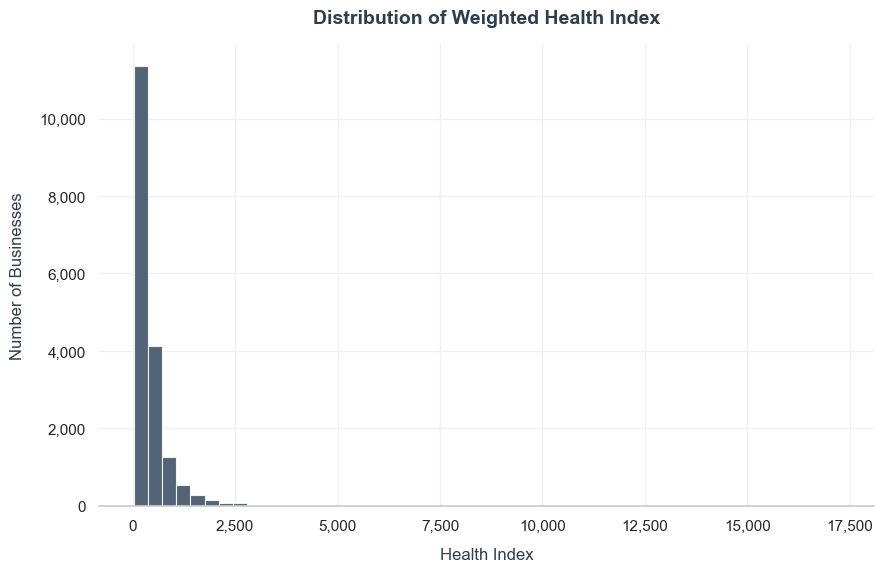

In [233]:
# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid", rc={"grid.color": "#f0f0f0"})

# Initialize the plot with an optimal figure size
plt.figure(figsize=(10, 6))

# Plot the histogram with updated styling
plt.hist(
    analytics_full_subset['WEIGHTED_HEALTH_INDEX'], 
    bins=50, 
    color='#34495e',       
    edgecolor='white',     # Adds a clean separation line between the bars
    linewidth=0.8,
    alpha=0.85             # Subtle transparency so background gridlines peek through cleanly
)

# Enhance titles and labels with distinct formatting and padding
plt.title("Distribution of Weighted Health Index", fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
plt.xlabel("Health Index", fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel("Number of Businesses", fontsize=12, labelpad=10, color='#2c3e50')

# Format both x and y axes with commas for clean readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 

# Remove unnecessary outer borders (spines) for an open, modern look
sns.despine(left=True, bottom=False)

# Show the polished plot
plt.show()

=> index is not yet well-calibrated, distribution is heavily right-skewed

(*A small number of businesses have extremely high Health Index values > 15,000*)

<h3 style="color:#475569;"> <i> Log transformation : </i></h3>  

In [234]:
# log-transform the index 
analytics_full_subset['WEIGHTED_HEALTH_INDEX_LOG'] = np.log1p(
    analytics_full_subset['WEIGHTED_HEALTH_INDEX']
)

In [235]:
analytics_full_subset['WEIGHTED_HEALTH_INDEX_LOG'].describe()

count    18000.000000
mean         5.854738
std          0.664348
min          3.511545
25%          5.406376
50%          5.725655
75%          6.194927
max          9.754560
Name: WEIGHTED_HEALTH_INDEX_LOG, dtype: float64

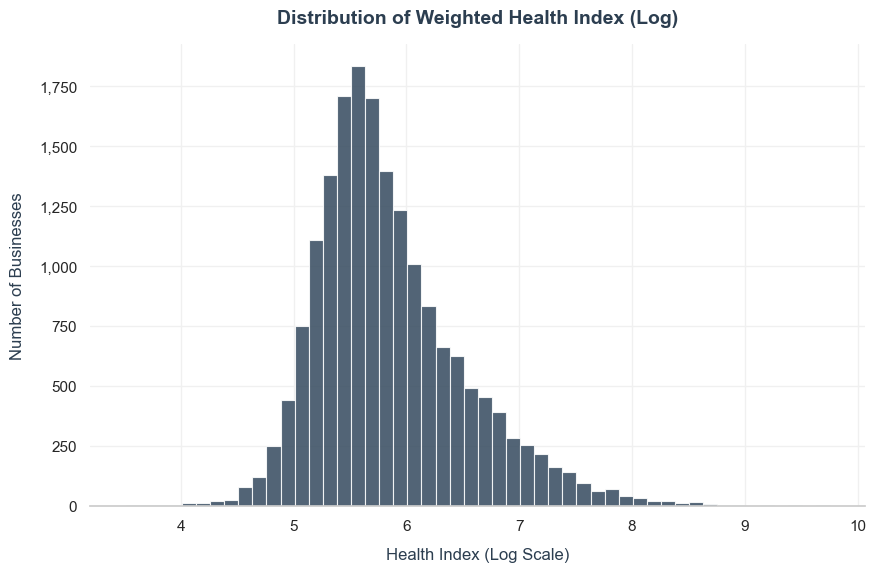

In [236]:
sns.set_theme(style="whitegrid", rc={"grid.color": "#f0f0f0"})

# Initialize the plot with a specific figure size
plt.figure(figsize=(10, 6))

# Plot the histogram with updated styling
plt.hist(
    analytics_full_subset['WEIGHTED_HEALTH_INDEX_LOG'], 
    bins=50, 
    color='#34495e',       
    edgecolor='white',     # Clean separation between bars
    linewidth=0.8,
    alpha=0.85             # Slight transparency so gridlines behind it show subtly
)

# Enhance titles and labels with font sizing and weight
plt.title("Distribution of Weighted Health Index (Log)", fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
plt.xlabel("Health Index (Log Scale)", fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel("Number of Businesses", fontsize=12, labelpad=10, color='#2c3e50')

# Format the y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Clean up the borders (spines)
sns.despine(left=True, bottom=False)

# Show the polished plot
plt.show()

<h3 style="color:#475569;"> <i> Scaling [0-100] : </i></h3>  

In [237]:
# Scale the log-transformed index to a 0-100 range
analytics_full_subset['WEIGHTED_HEALTH_INDEX_SCORE'] = (
    MinMaxScaler().fit_transform(
        analytics_full_subset[['WEIGHTED_HEALTH_INDEX_LOG']]
    ) * 100
)

In [238]:
analytics_full_subset['WEIGHTED_HEALTH_INDEX_SCORE'].describe()

count    18000.000000
mean        37.533025
std         10.641464
min          0.000000
25%         30.351208
50%         35.465398
75%         42.982146
max        100.000000
Name: WEIGHTED_HEALTH_INDEX_SCORE, dtype: float64

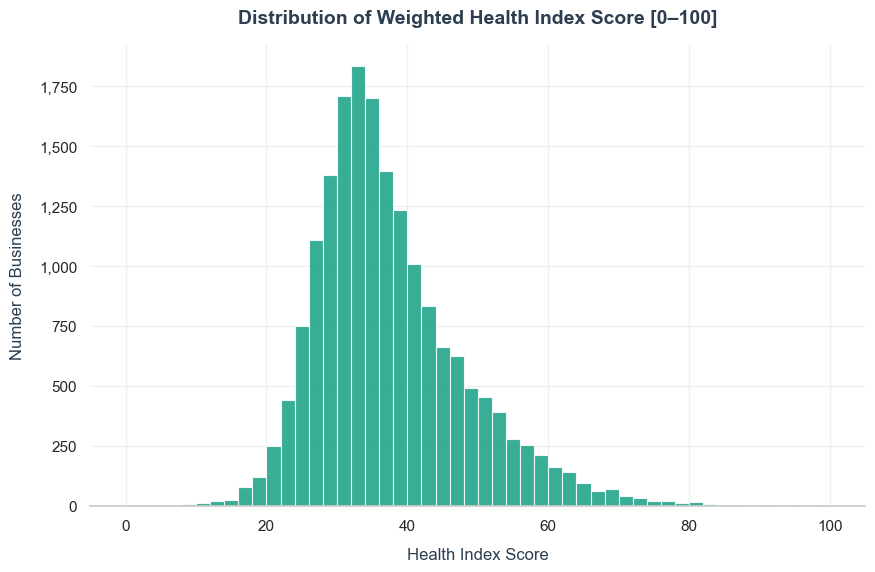

In [239]:
# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid", rc={"grid.color": "#f0f0f0"})

# Initialize the plot with an optimal figure size
plt.figure(figsize=(10, 6))

# Plot the histogram with updated styling
plt.hist(
    analytics_full_subset['WEIGHTED_HEALTH_INDEX_SCORE'], 
    bins=50, 
    color='#16a085',       
    edgecolor='white',     # Adds a clean separation line between the bars
    linewidth=0.8,
    alpha=0.85             # Subtle transparency so background gridlines peek through cleanly
)

# Enhance titles and labels with distinct formatting and padding
plt.title("Distribution of Weighted Health Index Score [0–100]", fontsize=14, pad=15, fontweight='bold', color='#2c3e50')
plt.xlabel("Health Index Score", fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel("Number of Businesses", fontsize=12, labelpad=10, color='#2c3e50')

# Format the y-axis with commas for clean readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Remove unnecessary outer borders (spines) for an open, modern look
sns.despine(left=True, bottom=False)

# Show the polished plot
plt.show()

<h3 style="color:#475569;"> <i> Percentile segmentation</i></h3>  

In [240]:
# Calculate percentile rank (reusing the log column)
analytics_full_subset['WEIGHTED_HEALTH_PERCENTILE'] = (
    analytics_full_subset['WEIGHTED_HEALTH_INDEX_LOG'].rank(pct=True)
)

In [241]:
# percentile bins (0 to 1) and their corresponding labels
bins = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0]
labels = ['0-10%', '10%-25%', '25%-50%', '50%-75%', '75%-90%', 'Top 10%']

# Create the tier column
analytics_full_subset['WEIGHTED_HEALTH_TIER'] = pd.cut(
    analytics_full_subset['WEIGHTED_HEALTH_PERCENTILE'],
    bins=bins,
    labels=labels,
    include_lowest=True  # Ensures the absolute minimum (0.0) is included in the first bin
)

<h3 style="color:#475569;"> <i> Analyze results</i></h3>  

In [242]:
analytics_full_subset.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,AVERAGE_STAR_RATING,VARIABILITY_SCORE,REVIEW_COUNT_PERIOD,TREND_SLOPE,NEGATIVE_SPIKE_SCORE,RECENCY_WEIGHTED_AVG_STARS,CLEANLINESS,...,HAS_VADER_RATING,INVERTED_HOUR_CONSISTENCY,ATTRIBUTE_SCORING,REVIEW_COUNT_PERIOD_LOG,HEALTH_INDEX_NO_WEIGHT,WEIGHTED_HEALTH_INDEX,WEIGHTED_HEALTH_INDEX_LOG,WEIGHTED_HEALTH_INDEX_SCORE,WEIGHTED_HEALTH_PERCENTILE,WEIGHTED_HEALTH_TIER
0,3_WGRjRrnZX2b4ZVpjmL6w,Arnold's Country Kitchen,Nashville,4.377246,1,334,0.1051,1,4.257914,0.00000,...,N,0.32,10,5.814131,55.090964,2710.829417,7.905379,70.379992,0.991500,Top 10%
1,JsUWxd9KwOvuq_Im8DZfEw,Johnny Rockets,Tampa,2.681818,0,22,-0.0000,1,2.175886,-0.40264,...,Y,1.06,8,3.135494,35.216804,299.829612,5.706544,35.159273,0.485000,25%-50%
2,u40qery_d1rwMwOprqCfKw,Big Ez Seafood,Gretna,4.250000,1,216,0.0381,1,4.134109,0.00000,...,N,0.81,9,5.379897,53.423928,1818.372387,7.506247,63.986737,0.977889,Top 10%
3,_1JmbxhyiTXO_CDytQTkgA,Ike's Sandwiches,Reno,4.236181,1,199,-0.0000,1,4.108851,0.00000,...,N,0.17,9,5.298317,52.699755,1685.269581,7.430274,62.769811,0.973000,Top 10%
4,vT1zrTTIji2JDhUHjFKopg,Laurel Street Bakery,New Orleans,4.279412,1,68,-0.0000,1,4.503874,0.00000,...,N,10.00,8,4.234107,57.909252,775.352226,6.654606,50.345242,0.876556,75%-90%


## <u>Checks</u>

In [243]:
# Find the index of the row with the absolute highest health score
top_business_index = analytics_full_subset['WEIGHTED_HEALTH_INDEX_SCORE'].idxmax()

# Extract that row and display it vertically as a column
top_business_profile = analytics_full_subset.loc[[top_business_index]].T

print(top_business_profile)

                                              88274
BUSINESS_ID                  1b5mnK8bMnnju_cvU65GqQ
BUSINESS_NAME                   Biscuit Love: Gulch
BUSINESS_CITY                             Nashville
AVERAGE_STAR_RATING                        4.089828
VARIABILITY_SCORE                                 1
REVIEW_COUNT_PERIOD                            2271
TREND_SLOPE                                  0.1216
NEGATIVE_SPIKE_SCORE                              1
RECENCY_WEIGHTED_AVG_STARS                 4.074912
CLEANLINESS                                     0.0
CUSTOMER_SERVICE                                0.0
FOOD_QUALITY                                    0.0
ORDER_ACCURACY                                  0.0
SPEED                                           0.0
VALUE                                           0.0
HAS_VADER_RATING                                  N
INVERTED_HOUR_CONSISTENCY                      0.16
ATTRIBUTE_SCORING                                10
REVIEW_COUNT

In [244]:
# Find the index of the row with the absolute lowest health score
bottom_business_index = analytics_full_subset['WEIGHTED_HEALTH_INDEX_SCORE'].idxmin()

# Extract that row and display it vertically as a column
bottom_business_index = analytics_full_subset.loc[[bottom_business_index]].T

print(bottom_business_index)

                                             603766
BUSINESS_ID                  IivxWo0vU5Qmz-OqoCaXrg
BUSINESS_NAME                  Sunflower Truck Stop
BUSINESS_CITY                          Phoenixville
AVERAGE_STAR_RATING                             0.0
VARIABILITY_SCORE                                 0
REVIEW_COUNT_PERIOD                               1
TREND_SLOPE                                     0.0
NEGATIVE_SPIKE_SCORE                              1
RECENCY_WEIGHTED_AVG_STARS                      1.0
CLEANLINESS                                     0.0
CUSTOMER_SERVICE                                0.0
FOOD_QUALITY                                    0.0
ORDER_ACCURACY                                  0.0
SPEED                                           0.0
VALUE                                           0.0
HAS_VADER_RATING                                  N
INVERTED_HOUR_CONSISTENCY                       0.0
ATTRIBUTE_SCORING                                 0
REVIEW_COUNT

In [245]:
test_health = analytics_full_subset[analytics_full_subset['BUSINESS_ID']=='6bT_9fRGR5RMMF_ik_wImw']

print(test_health.T)


                                               6490
BUSINESS_ID                  6bT_9fRGR5RMMF_ik_wImw
BUSINESS_NAME                         Bagels Galore
BUSINESS_CITY                                Hudson
AVERAGE_STAR_RATING                        2.714286
VARIABILITY_SCORE                                 0
REVIEW_COUNT_PERIOD                              21
TREND_SLOPE                                  0.2286
NEGATIVE_SPIKE_SCORE                              1
RECENCY_WEIGHTED_AVG_STARS                 2.600293
CLEANLINESS                                     0.0
CUSTOMER_SERVICE                                0.0
FOOD_QUALITY                                    0.0
ORDER_ACCURACY                                  0.0
SPEED                                           0.0
VALUE                                           0.0
HAS_VADER_RATING                                  N
INVERTED_HOUR_CONSISTENCY                      0.81
ATTRIBUTE_SCORING                                 5
REVIEW_COUNT

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
8.3.1 Write the dataframe back to Snowflake
</h1>

</div>


In [246]:
weighted_health_index = analytics_full_subset[['BUSINESS_ID','WEIGHTED_HEALTH_INDEX_SCORE','WEIGHTED_HEALTH_PERCENTILE','WEIGHTED_HEALTH_TIER']]

In [247]:
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_WEIGHTED_HEALTH_INDEX
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    weighted_health_index,
    table_name="QSR_WEIGHTED_HEALTH_INDEX",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18000


#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
9. SNOWFLAKE SCORING MERGING STEP
</h1>

</div>

<div style="
    background-color:#F0FDF4;
    border-left:6px solid #10B981;
    padding:18px;
    border-radius:8px;
    margin-top:15px;
    margin-bottom:20px;
">

<h3 style="color:#065F46; margin-top:0;">
<u>Data Integration Process</u>
</h3>

<p>
Prior to executing the Competitive Benchmarking, a critical consolidation phase is performed directly within Snowflake. 
<br>
The previously exported DataFrames are uploaded as database tables and integrated via a <code>LEFT JOIN</code>. This merging step consolidates:
</p>

<p>
The integration process created a final consolidated analytical view:
</p>

<p style="
    font-size:18px;
    font-weight:bold;
    color:#1F4E79;
">
STG_QSR_HEALTH_INDEX_FULL
</p>


</div>

---

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
10. COMPETITIVE BENCHMARKING
</h1>

</div>


<div style="
    background-color:#FFF8E7;
    border-left:6px solid #D97706;
    padding:15px;
    border-radius:6px;
">

<h3 style="color:#92400E; margin-top:0;">
<u>Methodological Approach</u>
</h3>

<p>
    
This section calculates competitive benchmarks that will feature alongside the final location health score:

**External benchmarking:**
- According to [CRE Daily](https://www.credaily.com/briefs/qsr-fast-casual-dining-overlap-in-net-lease-market/), QSRs compete for customers within a 2-mile radius.
- When looking at the external benchmarking, we will compare to chains that are located within a 2-mile radius, using z-scores and KDTree analysis.
  
**Internal benchmarking:**
- The internal benchmarking is based on the US nationwide performance (i.e. how one Subway outlet compares to other Subway outlets nationwide).
- Z-score will be used to calculate how much the outlet deviates away from the brand average. This analytical approach is also being used by KPMG in their [Retail Health Index](https://kpmg.com/au/en/insights/industry/retail-health-index.html).

- The ultimate goal is to help QSR managers being able to easily identify if their franchise is at Low, Medium, or High Risk. These labels, alongside the final score, serve as signals for manager to take actions against key service issues. As a result, managers will be able to quickly resolve customer pain points that threatens to damage the franchise's revenue, and reputation. 

</p>

</li>

</ol>

</div>

---

In [248]:
# =========================================
# Load dataset from Snowflake
# =========================================

# Connect to Snowflake, create dataframe with SQL queries, 
analytics_health_full = pd.read_sql("SELECT * FROM LSE_YELP_TEAMS_DB.TEAM_15.STG_QSR_HEALTH_INDEX_FULL", conn)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [249]:
# Keep only required columns
analytics_health_subset = analytics_health_full[[
    "BUSINESS_ID",
    "BUSINESS_NAME",
    "BUSINESS_CITY",
    "BUSINESS_TYPE",
    "BUSINESS_LATITUDE",
    "BUSINESS_LONGITUDE",
    "WEIGHTED_HEALTH_INDEX_SCORE"
]].copy()

In [250]:
# remove duplicates
analytics_health_subset = analytics_health_subset.drop_duplicates(
    subset=["BUSINESS_ID"]
)

In [251]:
data_valid(analytics_health_subset)


Missing Values (per column):
BUSINESS_ID                    0
BUSINESS_NAME                  0
BUSINESS_CITY                  0
BUSINESS_TYPE                  0
BUSINESS_LATITUDE              0
BUSINESS_LONGITUDE             0
WEIGHTED_HEALTH_INDEX_SCORE    0
dtype: int64

Unique Values (per column):
BUSINESS_ID                    18000
BUSINESS_NAME                   9835
BUSINESS_CITY                    665
BUSINESS_TYPE                      2
BUSINESS_LATITUDE              17670
BUSINESS_LONGITUDE             17569
WEIGHTED_HEALTH_INDEX_SCORE    17746
dtype: int64

Duplicate Rows in DataFrame:
0

Record Counts in DataFrame:
18000

Descriptive Statstics in DataFrame:
       BUSINESS_LATITUDE  BUSINESS_LONGITUDE  WEIGHTED_HEALTH_INDEX_SCORE
count       18000.000000        18000.000000                 18000.000000
mean           36.278857          -86.850990                    37.533025
std             4.882443           13.006352                    10.641464
min            27.578363 

In [252]:
analytics_health_subset.head()

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_TYPE,BUSINESS_LATITUDE,BUSINESS_LONGITUDE,WEIGHTED_HEALTH_INDEX_SCORE
0,mSQ6nIPfqviBF8xIuhsJ7A,The Tamale Place,Indianapolis,Chain,39.765557,-86.248899,61.168891
1,cp5fYxa66L0tkNGkzQheKg,Cori's Doghouse,Mount Juliet,Chain,36.167442,-86.512000,52.001367
2,JU4Ea-xwPCGOUG93TUrVmA,1 2 Tea,Vc Highlands,Independent,39.421112,-119.755588,42.570441
3,Bj7DL3SwmYHZYqPduAsa2w,Johnny's Po-Boys,New Orleans,Independent,29.955405,-90.064477,71.181074
4,_V9ktNg37MPh7X3MiYXe_Q,Hole In One Donuts,Tarpon Springs,Chain,28.126908,-82.740739,46.205832


<h1 style="color:#0F766E;"><b> 10.1 <u>Competitive benchmarking</b></u></h2>

- Compare how chains perform in the region (external benchmarking).
- Compare how the QSR performs against other locations owned by the same brand (internal benchmarking).   

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
10.1.1 Internal benchmarking
</h1>

</div>


In [253]:
# ==============================================================================
# Create internal benchmarking function.
# ==============================================================================
# Calculate the Z-score.
# Apply to the final score.
# Calculates how much the brand deviates away from the brand average. 
# Add labels to highlight actions. 
def calc_internal_benchmarking(
    dataframe, brand_col='BUSINESS_NAME', score_col='WEIGHTED_HEALTH_INDEX_SCORE', type_col='BUSINESS_TYPE'
):

    # Create a copy of the DataFrame. 
    df_output = dataframe.copy()

    # Calculate Mean and Standard Deviation. 
    brand_means = df_output.groupby(brand_col)[score_col].transform('mean')
    brand_stds = df_output.groupby(brand_col)[score_col].transform('std', ddof=0)

    # Compute Z-score. 
    # Exclude independent QSRs. 
    z_score_series = (df_output[score_col] - brand_means) / brand_stds
    df_output["INTERNAL_ZSCORE"] = np.select(
        [df_output[type_col] == 'Independent'],
        ['Independent'],
        default=round(z_score_series, 2).fillna(0)
    )

    # Turn text-strings into NaN.
    z_numeric = pd.to_numeric(df_output["INTERNAL_ZSCORE"], errors='coerce')

    # Define the label thresholds. 
    conditions = [
        df_output[type_col] == 'Independent',
        z_numeric >= 0.0, # Above or at brand average
        (z_numeric < 0.0) & (z_numeric > -1.0), # Below average, within normal variance 
        z_numeric <= -1.0 # Significantly below average
    ]

    # Corresponding labels. 
    status_choices = [
        'N/A',
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]

    # Apply the labels to a new column.
    df_output['INTERNAL_PERFORMANCE'] = np.select(
        conditions, status_choices, default = 'Unknown'
    )

    return df_output 

In [254]:
# calculate the internal benchmarking for our dataset
internal_benchmark_results = calc_internal_benchmarking(
    analytics_health_subset,
    brand_col='BUSINESS_NAME',
    score_col='WEIGHTED_HEALTH_INDEX_SCORE',
    type_col='BUSINESS_TYPE'
)

internal_benchmark_results

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_TYPE,BUSINESS_LATITUDE,BUSINESS_LONGITUDE,WEIGHTED_HEALTH_INDEX_SCORE,INTERNAL_ZSCORE,INTERNAL_PERFORMANCE
0,mSQ6nIPfqviBF8xIuhsJ7A,The Tamale Place,Indianapolis,Chain,39.765557,-86.248899,61.168891,0.0,Low Risk
1,cp5fYxa66L0tkNGkzQheKg,Cori's Doghouse,Mount Juliet,Chain,36.167442,-86.512000,52.001367,0.0,Low Risk
2,JU4Ea-xwPCGOUG93TUrVmA,1 2 Tea,Vc Highlands,Independent,39.421112,-119.755588,42.570441,Independent,N/A
3,Bj7DL3SwmYHZYqPduAsa2w,Johnny's Po-Boys,New Orleans,Independent,29.955405,-90.064477,71.181074,Independent,N/A
4,_V9ktNg37MPh7X3MiYXe_Q,Hole In One Donuts,Tarpon Springs,Chain,28.126908,-82.740739,46.205832,1.29,Low Risk
...,...,...,...,...,...,...,...,...,...
770009,df7a_aS7LwgXo3h45ABatQ,Tina's Bagel Factory,Trenton,Independent,40.208794,-74.715737,21.472747,Independent,N/A
771864,IC4r-CreIIONpsXIrvtGJg,Dunkin',Philadelphia,Chain,39.951294,-75.152623,16.129658,-3.0,High Risk
774089,uaBIJAmgeeK30m7QRTibtw,Philly Pretzel Factory,Abington,Chain,40.136295,-75.114607,20.898488,-0.93,Medium Risk
777507,_LOzXlo5UImPz3lm1UBY_Q,Hungry Howie's Pizza & Subs,Dunedin,Chain,28.019001,-82.750175,20.594062,-2.21,High Risk


<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
10.1.2 External benchmarking
</h1>

</div>


- Decided to use Scipy.spatial over Geopandas to calculate the competition within a 2-mile radius.
- Scipy.spatial is lightweight and can easily calculate millions of rows.

In [255]:
# ==============================================================================
# Create external benchmarking function.
# ==============================================================================

def calc_external_benchmarking(df, lat='BUSINESS_LATITUDE', lon='BUSINESS_LONGITUDE', score='WEIGHTED_HEALTH_INDEX_SCORE'):
    df_output = df.copy().reset_index(drop=True)

    # Convert coordinates to flat miles. 
    coords = np.column_stack((df_output[lon] * 53.0, df_output[lat] * 69.1))

    # Find competitors within 2-mile radius. 
    # Exclude self.
    tree = KDTree(coords)
    adj = tree.sparse_distance_matrix(tree, max_distance=2.0).tocoo()
    mask = adj.row !=adj.col # Exclude self. 

    # Find competitors within 2-mile radius. 
    comp_df = pd.DataFrame({
        'qsr_idx': adj.row[mask],
        'comp_score': df_output[score].values[adj.col[mask]]
    })

    # Handle stores without 2-mile competitors. 
    if not comp_df.empty:
        stats = comp_df.groupby('qsr_idx')['comp_score'].agg(
            LOCAL_MEAN='mean',
            LOCAL_STD=lambda x: x.std(ddof=0)
        )
        df_output = df_output.join(stats)
    else: 
        df_output['LOCAL_MEAN'] = np.nan
        df_output['LOCAL_STD'] = np.nan

    df_output['LOCAL_MEAN'] = df_output['LOCAL_MEAN'].fillna(df_output[score])
    df_output['LOCAL_STD'] = df_output['LOCAL_STD'].fillna(0)

    # Calculate the Z-score for each QSR location. 
    z_scores = (df_output[score] - df_output['LOCAL_MEAN']) / df_output['LOCAL_STD'].replace(0, 1)
    df_output['EXTERNAL_ZSCORE'] = np.round(z_scores, 2)

    # Assign risk. 
    conditions = [
        z_scores >= 0.0, # Above or at brand average
        (z_scores < 0.0) & (z_scores > -1.0), # Below average, within normal variance 
        z_scores <= -1.0 # Significantly below average
    ]

    # Create corresponding labels. 
    df_output['EXTERNAL_PERFORMANCE'] = np.select(conditions, 
                                                  ['Low Risk', 'Medium Risk', 'High Risk'],
                                                  default='Low Risk')

    risk_map = {
    'Low Risk': -1,
    'Medium Risk': 0,
    'High Risk': 1
    }

    df_output['EXTERNAL_RISK_SCORE'] = df_output['EXTERNAL_PERFORMANCE'].map(risk_map)
    

    # View final output. 
    return df_output.drop(columns=['LOCAL_MEAN', 'LOCAL_STD'])    

In [256]:
# calculate the external benchmarking for our dataset
external_benchmark_results = calc_external_benchmarking(
    analytics_health_subset,
    lat='BUSINESS_LATITUDE', 
    lon='BUSINESS_LONGITUDE', 
    score='WEIGHTED_HEALTH_INDEX_SCORE'
)

external_benchmark_results

,BUSINESS_ID,BUSINESS_NAME,BUSINESS_CITY,BUSINESS_TYPE,BUSINESS_LATITUDE,BUSINESS_LONGITUDE,WEIGHTED_HEALTH_INDEX_SCORE,EXTERNAL_ZSCORE,EXTERNAL_PERFORMANCE,EXTERNAL_RISK_SCORE
0,mSQ6nIPfqviBF8xIuhsJ7A,The Tamale Place,Indianapolis,Chain,39.765557,-86.248899,61.168891,3.19,Low Risk,-1
1,cp5fYxa66L0tkNGkzQheKg,Cori's Doghouse,Mount Juliet,Chain,36.167442,-86.512000,52.001367,2.44,Low Risk,-1
2,JU4Ea-xwPCGOUG93TUrVmA,1 2 Tea,Vc Highlands,Independent,39.421112,-119.755588,42.570441,-0.36,Medium Risk,0
3,Bj7DL3SwmYHZYqPduAsa2w,Johnny's Po-Boys,New Orleans,Independent,29.955405,-90.064477,71.181074,1.63,Low Risk,-1
4,_V9ktNg37MPh7X3MiYXe_Q,Hole In One Donuts,Tarpon Springs,Chain,28.126908,-82.740739,46.205832,1.09,Low Risk,-1
...,...,...,...,...,...,...,...,...,...,...
17995,df7a_aS7LwgXo3h45ABatQ,Tina's Bagel Factory,Trenton,Independent,40.208794,-74.715737,21.472747,-1.78,High Risk,1
17996,IC4r-CreIIONpsXIrvtGJg,Dunkin',Philadelphia,Chain,39.951294,-75.152623,16.129658,-2.10,High Risk,1
17997,uaBIJAmgeeK30m7QRTibtw,Philly Pretzel Factory,Abington,Chain,40.136295,-75.114607,20.898488,-1.61,High Risk,1
17998,_LOzXlo5UImPz3lm1UBY_Q,Hungry Howie's Pizza & Subs,Dunedin,Chain,28.019001,-82.750175,20.594062,-1.83,High Risk,1


In [262]:
merged_results = internal_benchmark_results.merge(
    external_benchmark_results,
    on='BUSINESS_ID',
    suffixes=('_INTERNAL', '_EXTERNAL')
)

cols_to_keep = [
    'BUSINESS_ID',
    'BUSINESS_NAME_INTERNAL',
    'BUSINESS_CITY_INTERNAL',
    'BUSINESS_TYPE_INTERNAL',
    'WEIGHTED_HEALTH_INDEX_SCORE_INTERNAL',
    'INTERNAL_ZSCORE',
    'INTERNAL_PERFORMANCE',
    'EXTERNAL_ZSCORE',
    'EXTERNAL_PERFORMANCE',
    'EXTERNAL_RISK_SCORE'
]

qsr_benchmark_results = merged_results[cols_to_keep]

qsr_benchmark_results

,BUSINESS_ID,BUSINESS_NAME_INTERNAL,BUSINESS_CITY_INTERNAL,BUSINESS_TYPE_INTERNAL,WEIGHTED_HEALTH_INDEX_SCORE_INTERNAL,INTERNAL_ZSCORE,INTERNAL_PERFORMANCE,EXTERNAL_ZSCORE,EXTERNAL_PERFORMANCE,EXTERNAL_RISK_SCORE
0,mSQ6nIPfqviBF8xIuhsJ7A,The Tamale Place,Indianapolis,Chain,61.168891,0.0,Low Risk,3.19,Low Risk,-1
1,cp5fYxa66L0tkNGkzQheKg,Cori's Doghouse,Mount Juliet,Chain,52.001367,0.0,Low Risk,2.44,Low Risk,-1
2,JU4Ea-xwPCGOUG93TUrVmA,1 2 Tea,Vc Highlands,Independent,42.570441,Independent,N/A,-0.36,Medium Risk,0
3,Bj7DL3SwmYHZYqPduAsa2w,Johnny's Po-Boys,New Orleans,Independent,71.181074,Independent,N/A,1.63,Low Risk,-1
4,_V9ktNg37MPh7X3MiYXe_Q,Hole In One Donuts,Tarpon Springs,Chain,46.205832,1.29,Low Risk,1.09,Low Risk,-1
...,...,...,...,...,...,...,...,...,...,...
17995,df7a_aS7LwgXo3h45ABatQ,Tina's Bagel Factory,Trenton,Independent,21.472747,Independent,N/A,-1.78,High Risk,1
17996,IC4r-CreIIONpsXIrvtGJg,Dunkin',Philadelphia,Chain,16.129658,-3.0,High Risk,-2.10,High Risk,1
17997,uaBIJAmgeeK30m7QRTibtw,Philly Pretzel Factory,Abington,Chain,20.898488,-0.93,Medium Risk,-1.61,High Risk,1
17998,_LOzXlo5UImPz3lm1UBY_Q,Hungry Howie's Pizza & Subs,Dunedin,Chain,20.594062,-2.21,High Risk,-1.83,High Risk,1


In [263]:
# check no duplicate
qsr_benchmark_results['BUSINESS_ID'].duplicated().sum()

np.int64(0)

In [264]:
#data_valid(qsr_benchmark_results)

<h3 style="color:#475569;"> <i><u> Limitations</u></i></h3>  

- When multiplying longitude by 53.0 and latitude by 69.1, the 2-mile radius around each QSR can be calculated. The numbers used for converting co-ordinates into miles have been pulled from the Cosine Rule formula.
- However, whilst each degree of latitude roughly equates to 69.1 miles, the latitude equation changes depending on the geographical location on the planet [(ThoughtCo, 2024)](https://www.thoughtco.com/degree-of-latitude-and-longitude-distance-4070616).
- For the US location, the longitude equation holds fairly accurate, but the 2-mile radius will have some discrepancies.
- If the code gets rolled out to markets outside the US, the formula will need to be updated with geo-based dynamic code, to accurately convert latitude co-ordinates into miles. 

<div style="
    background-color:#EAF4FB;
    padding:18px;
    border-radius:10px;
    margin-top:15px;
    margin-bottom:15px;
">

<h1 style="
    color:#1F4E79;
    font-family:Arial, sans-serif;
    font-size:20px;
    margin:0;
    letter-spacing:1px;
">
10.1.3 Write the dataframe back to Snowflake
</h1>

</div>


In [265]:
cur = conn.cursor()

# drop table if exists
cur.execute("""
DROP TABLE IF EXISTS QSR_COMPETITIVE_BENCHMARKING
""")


# create table
success, nchunks, nrows, _ = write_pandas(
    conn,
    qsr_benchmark_results,
    table_name="QSR_COMPETITIVE_BENCHMARKING",
    database="LSE_YELP_TEAMS_DB",
    schema="TEAM_15",
    auto_create_table=True
)

print("Snowflake export success: ", success, " , nb rows: ", nrows)

Snowflake export success:  True  , nb rows:  18000


---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
11. FINAL SCORECARD
</h1>

</div>

<div style="
    background-color:#F0FDF4;
    border-left:6px solid #10B981;
    padding:18px;
    border-radius:8px;
    margin-top:15px;
    margin-bottom:20px;
">

<h3 style="color:#065F46; margin-top:0;">
<u>Data Generation</u>
</h3>

<p>
Everything is in Snowflake now ! 
<br>
A final refresh of following view is required before refreshing the scorecard in Tableau...
</p>

<p style="
    font-size:18px;
    font-weight:bold;
    color:#1F4E79;
">
STG_QSR_SCORECARD
</p>


</div>

---

#

---

<div style="
    background-color:#D1FAE5;
    padding:15px;
    border-radius:8px;
    text-align:center;
    margin-top:10px;
    margin-bottom:10px;
">

<h1 style="
    color:#065F46;
    font-size:36px;
    font-weight:bold;
    margin:0;
    letter-spacing:1px;
">
12. CONCLUSION
</h1>

</div>


#### QSR Location Health
Using Yelp reviews and Snowflake location data, we have created code for a **QSR Location Health Index** that scores each outlet on a scale between 0-100, based on five main features:
* 🟦 REPUTATION_LEVEL **20% weight**
* 🟩 REVIEW_ENGAGEMENT **15% weight**
* 🟨 RECENCY_WEIGHTED_RISK **25% weight**
* 🟥 ROOT_CAUSE_THEMES (NLP) **25% weight**
* 🟪 OPERATIONAL_PROFILE **15% weight**

#### Operations-focused decision making
The idea behind the scorecard is to give QSR managers an easy overview into outlet performance, providing insights into key service issues, franchise location rankings, and location performance within a 2-mile radius. As a result, this facilitates quick and targeted actions to resolve common customer pain points; from customer service performance, to food quality, and service speed.  

#### Standardised and scalable index
The US market was selected for the Location Health Index prototype build. However, thanks to user-generated functions and the seamless integration between Snowflake, Python and Tableau, this is a scalable product that can be swiftly rolled out across additional countries. 

What's more, despite being built on Yelp data, additional data sources from Google and other review platform can easily feed into the scorecard. This is thanks to the user-defined functions, as well as the existing views in Snowflake, which stores the static list of QSR keywords for QSR extraction. 

#### Safeguard revenue and margin
Ultimately, this powerful product has the ability to provide QSR managers with data-driven decision making. Enabling swift actions in the fast-moving QSR industry to manage brand perception, thereby protecting revenue and margins from eroding. 

#